# **IMPORTS DES FICHIERS ET DES LIBRAIRIES**

## **Chargements des fichiers**

### ***Chemins relatifs des fichiers***

In [1]:
from IPython.display import display
from google.colab import drive
from collections import defaultdict
from shapely.geometry import shape
from sklearn.neighbors import NearestNeighbors
from IPython.display import display, HTML

import pandas as pd
import numpy as np
import os
import json


# Pour éviter d'avoir les messages warning
import warnings
warnings.filterwarnings('ignore')

# Monter Google Drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [2]:
base_path = '/content/drive/My Drive/Projet DS/Fichiers'
annees = [2023, 2022, 2021, 2020, 2019]
types = {
    'vehicule': 'vehicules-{}.csv',
    'usagers': 'usagers-{}.csv',
    'lieux': 'lieux-{}.csv',
    'caracteristiques': {
        2023: 'caract-{}.csv',
        2022: 'carcteristiques-{}.csv',
        2021: 'carcteristiques-{}.csv',
        2020: 'caracteristiques-{}.csv',
        2019: 'caracteristiques-{}.csv'
    }
}

fichiers = {}

for annee in annees:
    for t in ['vehicule', 'usagers', 'lieux']:
        fichiers[f'{t}_{annee}'] = os.path.join(base_path, types[t].format(annee))
    fichiers[f'caracteristiques_{annee}'] = os.path.join(
        base_path, types['caracteristiques'][annee].format(annee)
    )


In [3]:
# Fichiers par année
fichiers_par_annee = defaultdict(list)

for cle in fichiers:
    type_fichier, annee = cle.split("_")
    fichiers_par_annee[annee].append(type_fichier)

# Affichage des fichiers chargés année par année
for annee in sorted(fichiers_par_annee.keys()):
    types = ", ".join(sorted(fichiers_par_annee[annee]))
    print(f"{annee} : [{types}]")


2019 : [caracteristiques, lieux, usagers, vehicule]
2020 : [caracteristiques, lieux, usagers, vehicule]
2021 : [caracteristiques, lieux, usagers, vehicule]
2022 : [caracteristiques, lieux, usagers, vehicule]
2023 : [caracteristiques, lieux, usagers, vehicule]


### ***Chargement dynamique des jeux***

In [4]:
dfs_caracteristiques = {}
dfs_vehicule = {}
dfs_lieux = {}
dfs_usagers = {}

for annee in range(2019, 2024):
    for prefix, target_dict in zip(
        ['caracteristiques', 'vehicule', 'lieux', 'usagers'],
        [dfs_caracteristiques, dfs_vehicule, dfs_lieux, dfs_usagers]
    ):
        cle = f"{prefix}_{annee}"
        path = fichiers.get(cle)
        if path:
            try:
                target_dict[annee] = pd.read_csv(path, sep=';', encoding='utf-8')
            except (UnicodeDecodeError, pd.errors.ParserError):
                try:
                    target_dict[annee] = pd.read_csv(path, sep=';', encoding='latin-1')
                    print(f"(fallback latin-1) Fichier chargé : {cle}")
                except (UnicodeDecodeError, pd.errors.ParserError):
                    try:
                        target_dict[annee] = pd.read_csv(path, sep=',', encoding='latin-1')
                        print(f"(fallback latin-1 + virgule) Fichier chargé : {cle}")
                    except Exception as e:
                        print(f"❌ Lecture échouée pour {cle} : {e}")
            except Exception as e:
                print(f"❌ Autre erreur lecture {cle} : {e}")


### ***Correction automatique des colonnes fusionnées***

In [5]:
for nom, dico in {
    'caracteristiques': dfs_caracteristiques,
    'vehicule': dfs_vehicule,
    'lieux': dfs_lieux,
    'usagers': dfs_usagers
}.items():
    for annee, df in dico.items():
        if df.shape[1] == 1:  # si une seule colonne => problème de parsing
            cle = f"{nom}_{annee}"
            path = fichiers.get(cle)
            if path:
                try:
                    df_corrige = pd.read_csv(path, sep=',', encoding='latin-1')
                    dico[annee] = df_corrige  # remplace l'ancien DataFrame
                    print(f"✅ Corrigé : {cle} (rechargé avec virgule)")
                except Exception as e:
                    print(f"❌ Erreur correction {cle} : {e}")


In [6]:
# Affichage de toutes les colonnes et une largeur suffisante
pd.set_option('display.max_columns', None)   # Affiche toutes les colonnes
pd.set_option('display.width', 1000)         # Largeur d'affichage plus grande
pd.set_option('display.max_colwidth', None)  # Affiche les contenus longs

## **Fichiers des communes de France**

In [7]:
# Chargement du fichier avec encodage correct
df_communes = pd.read_csv(
    '/content/drive/My Drive/Projet DS/Brouillon Eric/communes-france-2025.csv',
    encoding='utf-8',
    sep=',',
    usecols=['code_insee', 'nom_standard', 'latitude_mairie', 'longitude_mairie', 'population']
)
# Renommage des colonnes
df_communes.rename(columns={
    'code_insee': 'Code Insee',
    'nom_standard': 'Nom',
    'latitude_mairie': 'lat',
    'longitude_mairie': 'long'
}, inplace=True)

In [8]:
df_communes.to_csv('/content/drive/My Drive/Projet DS/Brouillon Eric/df_communes.csv', index=False)

## **Fichiers caractéristiques**

In [9]:
# Nom de colonne erroné dans carcteristiques-2022.csv
dfs_caracteristiques[2022].rename(columns={'Accident_Id': 'Num_Acc'}, inplace=True)

# Nettoyage des colonnes superflues
for df in dfs_caracteristiques.values():
    df.drop(columns=['adr'], inplace=True, errors='ignore')

# Concaténer tous les DataFrames dans un seul
df_caracteristiques = pd.concat([dfs_caracteristiques[annee] for annee in range(2019, 2024)], ignore_index=True)

# Remplacer les virgules par des points puis convertir en float
df_caracteristiques['lat'] = df_caracteristiques['lat'].str.replace(',', '.').astype(float)
df_caracteristiques['long'] = df_caracteristiques['long'].str.replace(',', '.').astype(float)

# Nettoyage de la colonne 'hrmn' : suppression des deux-points
df_caracteristiques['hrmn'] = df_caracteristiques['hrmn'].astype(str).str.replace(":", "", regex=False)

# Remplacement des années longues par les versions à 2 chiffres
# df_caracteristiques['an'] = df_caracteristiques['an'].replace({2019: 19, 2020: 20, 2021: 21, 2022: 22, 2023: 23})

# Contrôle et remplacement éventuels des plages de catégories erronées
# fichiers caractéristiques
valeurs_valides_lum = [1, 2, 3, 4, 5]
valeurs_valides_int = [1, 2, 3, 4, 5, 6, 7, 8, 9]
valeurs_valides_atm = [-1, 1, 2, 3, 4, 5, 6, 7, 8, 9]
valeurs_valides_col = [-1, 1, 2, 3, 4, 5, 6, 7]

df_caracteristiques['lum'] = df_caracteristiques['lum'].apply(lambda x: x if x in valeurs_valides_lum else 1)
df_caracteristiques['int'] = df_caracteristiques['int'].apply(lambda x: x if x in valeurs_valides_int else 1)
df_caracteristiques['atm'] = df_caracteristiques['atm'].apply(lambda x: x if x in valeurs_valides_atm else -1)
df_caracteristiques['col'] = df_caracteristiques['col'].apply(lambda x: x if x in valeurs_valides_col else -1)

colonnes = ['lum', 'int', 'atm', 'col', 'an', 'mois', 'jour']
for col in colonnes:
    df_caracteristiques[col] = df_caracteristiques[col].astype('int64')

# Traitement de la Corse
df_caracteristiques['dep'] = df_caracteristiques['dep'].replace({'2A': 20, '2B': 20})

# Colonne départements et communes convertie en int64
df_caracteristiques['dep'] = df_caracteristiques['dep'].astype(int)

# colonnes string avec zéros initiaux
df_caracteristiques["dep_str"] = df_caracteristiques["dep"].astype(str).str.zfill(2)
df_caracteristiques["com_str"] = df_caracteristiques["com"].astype(str).str.zfill(5)

# Comparer le début de 'com_str' avec 'dep_str'
df_caracteristiques["dep_match"] = df_caracteristiques["com_str"].str[:2] == df_caracteristiques["dep_str"]

# Statistiques
nb_total = len(df_caracteristiques)
nb_match = df_caracteristiques["dep_match"].sum()
nb_erreurs = nb_total - nb_match

print(f"✅ {nb_match} correspondances valides sur {nb_total} lignes")
print(f"❌ {nb_erreurs} incohérences détectées")

# Lignes incorrectes
df_erreurs = df_caracteristiques[~df_caracteristiques["dep_match"]]

df_caracteristiques = df_caracteristiques.drop(columns=['dep_str', 'com_str', 'dep_match'])

✅ 255913 correspondances valides sur 273226 lignes
❌ 17313 incohérences détectées


In [10]:
# Contrôle des doublons dans Num_Acc
df_caracteristiques[df_caracteristiques['Num_Acc'].duplicated()]

,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,atm,col,lat,long


In [11]:
# Identification des lignes avec des coordonnées invalides (or de la métropole)
df_invalides = df_caracteristiques[(df_caracteristiques['lat'].isna()) | (df_caracteristiques['lat'] < 41.0) | (df_caracteristiques['lat'] > 51.5) |
                  (df_caracteristiques['long'].isna()) | (df_caracteristiques['long'] < -5.5) | (df_caracteristiques['long'] > 10.0)]

# Statistiques par année
erreurs_par_an = df_invalides['an'].value_counts().sort_index()
print(erreurs_par_an)

an
2019    2817
2020    2623
2021    2978
2022    2922
2023    3181
Name: count, dtype: int64


In [12]:
df_caracteristiques.to_csv('/content/drive/My Drive/Projet DS/Brouillon Eric/df_caracteristiques.csv', index=False)

In [13]:
print(df_caracteristiques.info())
print(df_caracteristiques.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 273226 entries, 0 to 273225
Data columns (total 14 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   Num_Acc  273226 non-null  int64  
 1   jour     273226 non-null  int64  
 2   mois     273226 non-null  int64  
 3   an       273226 non-null  int64  
 4   hrmn     273226 non-null  object 
 5   lum      273226 non-null  int64  
 6   dep      273226 non-null  int64  
 7   com      273226 non-null  object 
 8   agg      273226 non-null  int64  
 9   int      273226 non-null  int64  
 10  atm      273226 non-null  int64  
 11  col      273226 non-null  int64  
 12  lat      273226 non-null  float64
 13  long     273226 non-null  float64
dtypes: float64(2), int64(10), object(2)
memory usage: 29.2+ MB
None
        Num_Acc  jour  mois    an  hrmn  lum  dep    com  agg  int  atm  col        lat      long
0  201900000001    30    11  2019  0130    4   93  93053    1    1    1    2  48.896210  2.470120


## **Fichiers lieux**

In [14]:
# for annee in range(2019, 2024):
#     display(dfs_lieux[annee].head())

# Nettoyage des colonnes superflues
for df1 in dfs_lieux.values():
    df1.drop(columns=['voie', 'nbv', 'v1', 'v2', 'env1', 'pr', 'pr1', 'lartpc'], inplace=True, errors='ignore')

# Concaténer tous les DataFrames dans un seul
df_lieux = pd.concat([dfs_lieux[annee] for annee in range(2019, 2024)], ignore_index=True)

# Conversion avec support des valeurs manquantes
cols = ['circ', 'vosp', 'prof', 'plan', 'larrout', 'surf', 'infra', 'situ', 'vma']

for col in cols:
    # Convertit proprement en numérique
    df_lieux[col] = pd.to_numeric(df_lieux[col], errors='coerce')

    # Si certaines colonnes contiennent des décimales, on arrondit
    df_lieux[col] = df_lieux[col].round()

    # Convertit en Int64 avec support NaN
    df_lieux[col] = df_lieux[col].astype('Int64')

# Remplacer les valeurs < 30 ou > 130 par NaN dans la colonne 'vma'
df_lieux.loc[(df_lieux['vma'] < 30) | (df_lieux['vma'] > 130), 'vma'] = np.nan

# remplacement des NA par des 0
colonnes = ['larrout']
df_lieux[colonnes] = df_lieux[colonnes].fillna(0)

# fichiers lieux
valeurs_valides_catr = [1, 2, 3, 4, 5, 6, 7, 8, 9]
valeurs_valides_cicr = [-1, 1, 2, 3, 4]
valeurs_valides_vosp = [-1, 0, 1, 2, 3]
valeurs_valides_prof = [-1, 1, 2, 3, 4]
valeurs_valides_plan = [-1, 1, 2, 3, 4]
valeurs_valides_surf = [-1, 1, 2, 3, 4, 5, 6, 7, 8, 9]
valeurs_valides_infra = [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
valeurs_valides_situ = [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8]

df_lieux['catr'] = df_lieux['catr'].apply(lambda x: x if x in valeurs_valides_catr else 9)
df_lieux['circ'] = df_lieux['circ'].apply(lambda x: x if x in valeurs_valides_cicr else -1)
df_lieux['vosp'] = df_lieux['vosp'].apply(lambda x: x if x in valeurs_valides_vosp else -1)
df_lieux['prof'] = df_lieux['prof'].apply(lambda x: x if x in valeurs_valides_prof else -1)
df_lieux['plan'] = df_lieux['plan'].apply(lambda x: x if x in valeurs_valides_plan else -1)
df_lieux['surf'] = df_lieux['surf'].apply(lambda x: x if x in valeurs_valides_surf else -1)
df_lieux['infra'] = df_lieux['infra'].apply(lambda x: x if x in valeurs_valides_infra else -1)
df_lieux['situ'] = df_lieux['situ'].apply(lambda x: x if x in valeurs_valides_situ else -1)

colonnes = ['catr', 'circ', 'vosp', 'plan', 'surf', 'infra', 'situ', 'prof', 'larrout'],
for col in colonnes:
    df_lieux[col] = df_lieux[col].astype('int64')

# Supprimer toutes les lignes en double
df_lieux = df_lieux[~df_lieux['Num_Acc'].duplicated(keep='first')]

# Contrôle des doublons de la colonne Num_Acc
nb_doublons2 = df_lieux['Num_Acc'].duplicated().sum()
print(f"Nombre de doublons dans 'Num_Acc' : {nb_doublons2}")

df_lieux.to_csv('/content/drive/My Drive/Projet DS/Brouillon Eric/df_lieux.csv', index=False)

Nombre de doublons dans 'Num_Acc' : 0


In [15]:
print(df_lieux.info())
print(df_lieux.head())

<class 'pandas.core.frame.DataFrame'>
Index: 273226 entries, 0 to 289263
Data columns (total 11 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   Num_Acc  273226 non-null  int64
 1   catr     273226 non-null  int64
 2   circ     273226 non-null  int64
 3   vosp     273226 non-null  int64
 4   prof     273226 non-null  int64
 5   plan     273226 non-null  int64
 6   larrout  273226 non-null  int64
 7   surf     273226 non-null  int64
 8   infra    273226 non-null  int64
 9   situ     273226 non-null  int64
 10  vma      265884 non-null  Int64
dtypes: Int64(1), int64(10)
memory usage: 25.3 MB
None
        Num_Acc  catr  circ  vosp  prof  plan  larrout  surf  infra  situ  vma
0  201900000001     1     3     0     1     2        0     1      2     1   70
1  201900000002     1     1     0     4     2        0     1      0     1   70
2  201900000003     1     3     0     1     3        0     1      0     1   90
3  201900000004     1     3     0     1   

## **Fichiers usagers**

In [16]:
# Nettoyage des colonnes superflues
for df2 in dfs_usagers.values():
    df2.drop(columns=['place', 'an_nais', 'secu1', 'secu2', 'secu3', 'id_usager'], inplace=True, errors='ignore')

# Concaténer tous les DataFrames dans un seul
df_usagers = pd.concat([dfs_usagers[annee] for annee in range(2019, 2024)], ignore_index=True)

# Compter les occurrences des valeurs de gravite par Num_Acc
# df_grav_counts = df_usagers.groupby("Num_Acc")["grav"].value_counts().unstack(fill_value=0)

# Filtrer uniquement les conducteurs (catu == 1) et les piétons
# df_usagers = df_usagers[df_usagers["catu"].isin([1, 3])]

# Compter les occurrences des valeurs de gravite par Num_Acc
# df_grav_counts = df_usagers.groupby("Num_Acc")["grav"].value_counts().unstack(fill_value=0)


In [17]:
# Retraitement des piétons : exclusion du data

# Identifier les Num_Acc contenant au moins un piéton (catu == 3)
accidents_avec_pieton = df_usagers[df_usagers['catu'] == 3]['Num_Acc'].unique()

# Supprimer toutes les lignes appartenant à ces Num_Acc
df_usagers = df_usagers[~df_usagers['Num_Acc'].isin(accidents_avec_pieton)]

# Réinitialiser les index
df_usagers = df_usagers.reset_index(drop=True)


In [18]:
# Éclater la colonne 'grav'
df_usagers['ind'] = (df_usagers['grav'] == 1).astype(int)
df_usagers['tue'] = (df_usagers['grav'] == 2).astype(int)
df_usagers['bhosp'] = (df_usagers['grav'] == 3).astype(int)
df_usagers['bleger'] = (df_usagers['grav'] == 4).astype(int)

# S'assurer que toutes les colonnes existent même si certaines gravites sont absentes
for col in ["ind", "tue", "bhosp", "bleger"]:
    if col not in df_usagers.columns:
        df_usagers[col] = 0

In [19]:
# Contrôle des doublons de la colonne Num_Acc
nb_doublons3 = df_usagers['Num_Acc'].duplicated().sum()
print(f"Nombre de doublons dans 'Num_Acc' : {nb_doublons3}")

Nombre de doublons dans 'Num_Acc' : 295615


In [20]:
df_usagers.to_csv('/content/drive/My Drive/Projet DS/Brouillon Eric/df_usagers.csv', index=False)

In [21]:
print(df_usagers.info())
print(df_usagers.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524149 entries, 0 to 524148
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Num_Acc      524149 non-null  int64 
 1   id_vehicule  524149 non-null  object
 2   num_veh      524149 non-null  object
 3   catu         524149 non-null  int64 
 4   grav         524149 non-null  int64 
 5   sexe         524149 non-null  int64 
 6   trajet       524149 non-null  int64 
 7   locp         524149 non-null  int64 
 8   actp         524149 non-null  object
 9   etatp        524149 non-null  int64 
 10  ind          524149 non-null  int64 
 11  tue          524149 non-null  int64 
 12  bhosp        524149 non-null  int64 
 13  bleger       524149 non-null  int64 
dtypes: int64(11), object(3)
memory usage: 56.0+ MB
None
        Num_Acc  id_vehicule num_veh  catu  grav  sexe  trajet  locp actp  etatp  ind  tue  bhosp  bleger
0  201900000001  138 306 524     B01     2     4     2

## **Fichiers véhicules**

In [22]:
# Nettoyage des colonnes superflues
for df3 in dfs_vehicule.values():
    df3.drop(columns=['motor', 'occutc', 'senc'], inplace=True, errors='ignore')

In [23]:
# Concaténer tous les DataFrames dans un seul
df_vehicule = pd.concat([dfs_vehicule[annee] for annee in range(2019, 2024)], ignore_index=True)

In [24]:
# fichiers vehicules
valeurs_valides_catv = [0, 1, 2, 3, 7, 10, 13, 14, 15, 16, 17, 20, 21, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 50, 60, 80, 99]
valeurs_valides_obs = [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
valeurs_valides_obsm = [-1, 0, 1, 2, 4, 5, 6, 9]
valeurs_valides_choc = [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
valeurs_valides_manv = [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]

df_vehicule['catv'] = df_vehicule['catv'].apply(lambda x: x if x in valeurs_valides_catv else 99)
df_vehicule['obs'] = df_vehicule['obs'].apply(lambda x: x if x in valeurs_valides_obs else -1)
df_vehicule['obsm'] = df_vehicule['obsm'].apply(lambda x: x if x in valeurs_valides_obsm else -1)
df_vehicule['choc'] = df_vehicule['choc'].apply(lambda x: x if x in valeurs_valides_choc else -1)
df_vehicule['manv'] = df_vehicule['manv'].apply(lambda x: x if x in valeurs_valides_manv else -1)

colonnes = ['catv', 'obs', 'obsm', 'choc', 'manv']
for col in colonnes:
    df_vehicule[col] = df_vehicule[col].astype('int64')

In [25]:
df_vehicule['catv'].isna().sum()

np.int64(0)

In [26]:
valeurs_a_supprimer = [20, 21, 37, 38, 39, 40, 99]

df_vehicule = df_vehicule[~df_vehicule['catv'].isin(valeurs_a_supprimer)]

In [27]:
df_vehicule.to_csv('/content/drive/My Drive/Projet DS/Brouillon Eric/df_vehicule.csv', index=False)

In [28]:
print(df_usagers.info())
print(df_usagers.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524149 entries, 0 to 524148
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Num_Acc      524149 non-null  int64 
 1   id_vehicule  524149 non-null  object
 2   num_veh      524149 non-null  object
 3   catu         524149 non-null  int64 
 4   grav         524149 non-null  int64 
 5   sexe         524149 non-null  int64 
 6   trajet       524149 non-null  int64 
 7   locp         524149 non-null  int64 
 8   actp         524149 non-null  object
 9   etatp        524149 non-null  int64 
 10  ind          524149 non-null  int64 
 11  tue          524149 non-null  int64 
 12  bhosp        524149 non-null  int64 
 13  bleger       524149 non-null  int64 
dtypes: int64(11), object(3)
memory usage: 56.0+ MB
None
        Num_Acc  id_vehicule num_veh  catu  grav  sexe  trajet  locp actp  etatp  ind  tue  bhosp  bleger
0  201900000001  138 306 524     B01     2     4     2

# **FUSION DES FICHIERS**

## **Chargements des fichiers créés**

In [29]:
# Chargements des fichiers
fichiers = {

  'df_vehicule': '/content/drive/My Drive/Projet DS/Brouillon Eric/df_vehicule.csv',
  'df_usagers': '/content/drive/My Drive/Projet DS/Brouillon Eric/df_usagers.csv',
  'df_caracteristiques': '/content/drive/My Drive/Projet DS/Brouillon Eric/df_caracteristiques.csv',
  'df_lieux': '/content/drive/My Drive/Projet DS/Brouillon Eric/df_lieux.csv',

}

df_vehicule = pd.read_csv(fichiers['df_vehicule'])
df_usagers = pd.read_csv(fichiers['df_usagers'])
df_caracteristiques = pd.read_csv(fichiers['df_caracteristiques'])
df_lieux = pd.read_csv(fichiers['df_lieux'])

def resume_df(df):
    return pd.DataFrame({
        "colonne": df.columns,
        "type": df.dtypes.values,
        "non_nuls": df.notna().sum().values,
        "total": len(df),
        "manquants (%)": round(100 * (1 - df.notna().sum() / len(df)), 2).values
    })

res_vehicule = resume_df(df_vehicule)
res_usagers = resume_df(df_usagers)
res_lieux = resume_df(df_lieux)
res_caracteristiques = resume_df(df_caracteristiques)

print(df_vehicule.head())
print(df_usagers.head())
print(df_caracteristiques.head())
print(df_lieux.head())

        Num_Acc  id_vehicule num_veh  catv  obs  obsm  choc  manv
0  201900000001  138 306 524     B01     7    0     2     5    23
1  201900000001  138 306 525     A01    17    1     0     3    11
2  201900000002  138 306 523     A01     7    4     0     1     0
3  201900000003  138 306 520     A01     7    0     2     1     2
4  201900000003  138 306 521     B01     7    1     0     4     2
        Num_Acc  id_vehicule num_veh  catu  grav  sexe  trajet  locp actp  etatp  ind  tue  bhosp  bleger
0  201900000001  138 306 524     B01     2     4     2       0    -1   -1     -1    0    0      0       1
1  201900000001  138 306 524     B01     1     4     2       5    -1   -1     -1    0    0      0       1
2  201900000001  138 306 525     A01     1     1     1       0    -1   -1     -1    1    0      0       0
3  201900000002  138 306 523     A01     1     4     2       0    -1   -1     -1    0    0      0       1
4  201900000003  138 306 520     A01     1     1     1       0    -1    0 

## **Contrôles des fichiers chargés**

In [30]:
df_vehicule['catv'].isna().sum()

np.int64(0)

## **Fusions des fichiers**

In [31]:
# Fusion des DataFrames df_usagers et df_vehicules
df_fusion = df_usagers.merge(df_vehicule, on=['Num_Acc', 'id_vehicule', 'num_veh'], how='left')  # On garde tous les usagers même si pas de véhicule associé
df_fusion.head()

,Num_Acc,id_vehicule,num_veh,catu,grav,sexe,trajet,locp,actp,etatp,ind,tue,bhosp,bleger,catv,obs,obsm,choc,manv
0,201900000001,138 306 524,B01,2,4,2,0,-1,-1,-1,0,0,0,1,7.0,0.0,2.0,5.0,23.0
1,201900000001,138 306 524,B01,1,4,2,5,-1,-1,-1,0,0,0,1,7.0,0.0,2.0,5.0,23.0
2,201900000001,138 306 525,A01,1,1,1,0,-1,-1,-1,1,0,0,0,17.0,1.0,0.0,3.0,11.0
3,201900000002,138 306 523,A01,1,4,2,0,-1,-1,-1,0,0,0,1,7.0,4.0,0.0,1.0,0.0
4,201900000003,138 306 520,A01,1,1,1,0,-1,0,-1,1,0,0,0,7.0,0.0,2.0,1.0,2.0


In [32]:
df_fusion['catv'] = df_fusion['catv'].fillna(-1).astype(int)
df_fusion['obs'] = df_fusion['obs'].fillna(-1).astype(int)
df_fusion['obsm'] = df_fusion['obsm'].fillna(-1).astype(int)
df_fusion['choc'] = df_fusion['choc'].fillna(-1).astype(int)
df_fusion['manv'] = df_fusion['manv'].fillna(-1).astype(int)


In [33]:
df_fusion['catv'].isna().sum()

np.int64(0)

In [34]:
df_merge1  = df_fusion.merge(df_caracteristiques, on='Num_Acc', how='left')
df_final = df_merge1 .merge(df_lieux, on='Num_Acc', how='left')

# Supprimer les départements > 95
df_final = df_final[df_final['dep'] <= 95]

# Garder uniquement l’heure dans la colonne 'hrmn'
# On divise par 100 pour ne garder que l’heure
df_final['heure'] = df_final['hrmn'] // 100


# Affichage de toutes les colonnes et une largeur suffisante
pd.set_option('display.max_columns', None)   # Affiche toutes les colonnes
pd.set_option('display.width', 1000)         # Largeur d'affichage plus grande
pd.set_option('display.max_colwidth', None)  # Affiche les contenus longs

df_final.to_csv('/content/drive/My Drive/Projet DS/Brouillon Eric/df_final.csv', index=False)
df_final.head()

,Num_Acc,id_vehicule,num_veh,catu,grav,sexe,trajet,locp,actp,etatp,ind,tue,bhosp,bleger,catv,obs,obsm,choc,manv,jour,mois,an,hrmn,lum,dep,com,agg,int,atm,col,lat,long,catr,circ,vosp,prof,plan,larrout,surf,infra,situ,vma,heure
0,201900000001,138 306 524,B01,2,4,2,0,-1,-1,-1,0,0,0,1,7,0,2,5,23,30,11,2019,130,4,93,93053,1,1,1,2,48.896210,2.470120,1,3,0,1,2,0,1,2,1,70.0,1
1,201900000001,138 306 524,B01,1,4,2,5,-1,-1,-1,0,0,0,1,7,0,2,5,23,30,11,2019,130,4,93,93053,1,1,1,2,48.896210,2.470120,1,3,0,1,2,0,1,2,1,70.0,1
2,201900000001,138 306 525,A01,1,1,1,0,-1,-1,-1,1,0,0,0,17,1,0,3,11,30,11,2019,130,4,93,93053,1,1,1,2,48.896210,2.470120,1,3,0,1,2,0,1,2,1,70.0,1
3,201900000002,138 306 523,A01,1,4,2,0,-1,-1,-1,0,0,0,1,7,4,0,1,0,30,11,2019,250,3,93,93066,1,1,1,6,48.930700,2.368800,1,1,0,4,2,0,1,0,1,70.0,2
4,201900000003,138 306 520,A01,1,1,1,0,-1,0,-1,1,0,0,0,7,0,2,1,2,28,11,2019,1515,1,92,92036,1,1,1,4,48.935872,2.319174,1,3,0,1,3,0,1,0,1,90.0,15


In [35]:
df_final['catv'].isna().sum()

np.int64(0)

In [36]:
df_final = df_final.drop(columns=['id_vehicule', 'num_veh', 'hrmn'])

In [37]:
df_final.head()

,Num_Acc,catu,grav,sexe,trajet,locp,actp,etatp,ind,tue,bhosp,bleger,catv,obs,obsm,choc,manv,jour,mois,an,lum,dep,com,agg,int,atm,col,lat,long,catr,circ,vosp,prof,plan,larrout,surf,infra,situ,vma,heure
0,201900000001,2,4,2,0,-1,-1,-1,0,0,0,1,7,0,2,5,23,30,11,2019,4,93,93053,1,1,1,2,48.896210,2.470120,1,3,0,1,2,0,1,2,1,70.0,1
1,201900000001,1,4,2,5,-1,-1,-1,0,0,0,1,7,0,2,5,23,30,11,2019,4,93,93053,1,1,1,2,48.896210,2.470120,1,3,0,1,2,0,1,2,1,70.0,1
2,201900000001,1,1,1,0,-1,-1,-1,1,0,0,0,17,1,0,3,11,30,11,2019,4,93,93053,1,1,1,2,48.896210,2.470120,1,3,0,1,2,0,1,2,1,70.0,1
3,201900000002,1,4,2,0,-1,-1,-1,0,0,0,1,7,4,0,1,0,30,11,2019,3,93,93066,1,1,1,6,48.930700,2.368800,1,1,0,4,2,0,1,0,1,70.0,2
4,201900000003,1,1,1,0,-1,0,-1,1,0,0,0,7,0,2,1,2,28,11,2019,1,92,92036,1,1,1,4,48.935872,2.319174,1,3,0,1,3,0,1,0,1,90.0,15


In [38]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 494927 entries, 0 to 524148
Data columns (total 40 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   Num_Acc  494927 non-null  int64  
 1   catu     494927 non-null  int64  
 2   grav     494927 non-null  int64  
 3   sexe     494927 non-null  int64  
 4   trajet   494927 non-null  int64  
 5   locp     494927 non-null  int64  
 6   actp     494927 non-null  object 
 7   etatp    494927 non-null  int64  
 8   ind      494927 non-null  int64  
 9   tue      494927 non-null  int64  
 10  bhosp    494927 non-null  int64  
 11  bleger   494927 non-null  int64  
 12  catv     494927 non-null  int64  
 13  obs      494927 non-null  int64  
 14  obsm     494927 non-null  int64  
 15  choc     494927 non-null  int64  
 16  manv     494927 non-null  int64  
 17  jour     494927 non-null  int64  
 18  mois     494927 non-null  int64  
 19  an       494927 non-null  int64  
 20  lum      494927 non-null  int64

In [39]:
df_final['catv'].isna().sum()

np.int64(0)

# **TRAVAUX SUR df_final**

## **Chargements du fichier df_final**

In [40]:
from google.colab import drive
from tabulate import tabulate
from rich.console import Console
from rich.table import Table

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pour éviter d'avoir les messages warning
import warnings
warnings.filterwarnings('ignore')

# Affichage de toutes les colonnes et une largeur suffisante
pd.set_option('display.max_columns', None)   # Affiche toutes les colonnes
pd.set_option('display.width', 1000)         # Largeur d'affichage plus grande
pd.set_option('display.max_colwidth', None)  # Affiche les contenus longs

# Monter Google Drive
drive.mount("/content/drive", force_remount=True)

# Chargements des fichiers
fichiers = {
  'df_final': '/content/drive/My Drive/Projet DS/Brouillon Eric/df_final.csv',
  'df_postal': '/content/drive/My Drive/Projet DS/Fichiers/019HexaSmal.csv',

}

df_final = pd.read_csv(fichiers['df_final'])
df_postal = pd.read_csv(fichiers['df_postal'], encoding='latin1', sep=';')

df_final.info()


Mounted at /content/drive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494927 entries, 0 to 494926
Data columns (total 43 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Num_Acc      494927 non-null  int64  
 1   id_vehicule  494927 non-null  object 
 2   num_veh      494927 non-null  object 
 3   catu         494927 non-null  int64  
 4   grav         494927 non-null  int64  
 5   sexe         494927 non-null  int64  
 6   trajet       494927 non-null  int64  
 7   locp         494927 non-null  int64  
 8   actp         494927 non-null  object 
 9   etatp        494927 non-null  int64  
 10  ind          494927 non-null  int64  
 11  tue          494927 non-null  int64  
 12  bhosp        494927 non-null  int64  
 13  bleger       494927 non-null  int64  
 14  catv         494927 non-null  int64  
 15  obs          494927 non-null  int64  
 16  obsm         494927 non-null  int64  
 17  choc         494927 non-null  int64  
 18

In [41]:
df_final['catv'].isna().sum()

np.int64(0)

## **Glossaire**

In [42]:
noms_colonnes = {
    "agg": "Localisation",
    "an": "Année de l'accident",
    "atm": "Conditions atmosphériques",
    "Bhos": "Blessé hospitalisé",
    "Bleger": "Blessé non hospitalisé",
    "catv": "Catégorie de véhicule",
    "catr": "Catégorie de route",
    "circ": "Régime de circulation",
    "col": "Type de collision",
    "com": "Commune (code INSEE)",
    "dep": "Département (code INSEE)",
    "hrmn": "Heure et minutes de l'accident",
    "Ind": "Blessé léger",
    "infra": "Aménagement - Infrastructure",
    "int": "Type d'intersection",
    "jour": "Jour de l'accident",
    "larrout": "Largeur de la chaussée",
    "lat": "Latitude",
    "long": "Longitude",
    "lum": "Lumière : conditions d'éclairage lors de l'accident",
    "mois": "Mois de l'accident",
    "Num_Acc": "Numéro d'identifiant de l'accident",
    "obs": "Obstacle fixe heurté",
    "obsm": "Obstacle mobile heurté",
    "plan": "Tracé en plan",
    "prof": "Profilé de la route à l'endroit de l'accident",
    "situ": "Situation de l'accident",
    "surf": "État de la surface",
    "Tue": "Tué",
    "vma": "Vitesse maximale autorisée",
    "vosp": "Existence d'une voie réservée"
}

In [43]:
df_final.head()

,Num_Acc,id_vehicule,num_veh,catu,grav,sexe,trajet,locp,actp,etatp,ind,tue,bhosp,bleger,catv,obs,obsm,choc,manv,jour,mois,an,hrmn,lum,dep,com,agg,int,atm,col,lat,long,catr,circ,vosp,prof,plan,larrout,surf,infra,situ,vma,heure
0,201900000001,138 306 524,B01,2,4,2,0,-1,-1,-1,0,0,0,1,7,0,2,5,23,30,11,2019,130,4,93,93053,1,1,1,2,48.896210,2.470120,1,3,0,1,2,0,1,2,1,70.0,1
1,201900000001,138 306 524,B01,1,4,2,5,-1,-1,-1,0,0,0,1,7,0,2,5,23,30,11,2019,130,4,93,93053,1,1,1,2,48.896210,2.470120,1,3,0,1,2,0,1,2,1,70.0,1
2,201900000001,138 306 525,A01,1,1,1,0,-1,-1,-1,1,0,0,0,17,1,0,3,11,30,11,2019,130,4,93,93053,1,1,1,2,48.896210,2.470120,1,3,0,1,2,0,1,2,1,70.0,1
3,201900000002,138 306 523,A01,1,4,2,0,-1,-1,-1,0,0,0,1,7,4,0,1,0,30,11,2019,250,3,93,93066,1,1,1,6,48.930700,2.368800,1,1,0,4,2,0,1,0,1,70.0,2
4,201900000003,138 306 520,A01,1,1,1,0,-1,0,-1,1,0,0,0,7,0,2,1,2,28,11,2019,1515,1,92,92036,1,1,1,4,48.935872,2.319174,1,3,0,1,3,0,1,0,1,90.0,15


## **Détermination du niveau de gravité**

In [44]:
# Score de gravité binaire/pondéré
# df_final["gravite"] = (df_final["Tue"] * 10 + df_final["Bhosp"] * 3 + df_final["Bleger"] * 1)
# df_final['gravite'] = df_final.apply(lambda row: 1 if row['tue'] != 0 or row['bhosp'] != 0 else 0, axis=1)
# def classer_gravite(row): if row['tue'] > 0: return 10 elif row['bhosp'] > 0: return 3 elif row['bleger'] > 0: return 1 else: return 0 df_final['gravite'] = df_final.apply(classer_gravite, axis=1)

# Score de gravité binaire
df_final['gravite'] = (((df_final['tue'] != 0) | (df_final['bhosp'] != 0)).astype(int))

moyenne_gravite = df_final['gravite'].mean()
moyenne_gravite

np.float64(0.17984066337055768)

In [45]:
df_final.info(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494927 entries, 0 to 494926
Data columns (total 44 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Num_Acc      494927 non-null  int64  
 1   id_vehicule  494927 non-null  object 
 2   num_veh      494927 non-null  object 
 3   catu         494927 non-null  int64  
 4   grav         494927 non-null  int64  
 5   sexe         494927 non-null  int64  
 6   trajet       494927 non-null  int64  
 7   locp         494927 non-null  int64  
 8   actp         494927 non-null  object 
 9   etatp        494927 non-null  int64  
 10  ind          494927 non-null  int64  
 11  tue          494927 non-null  int64  
 12  bhosp        494927 non-null  int64  
 13  bleger       494927 non-null  int64  
 14  catv         494927 non-null  int64  
 15  obs          494927 non-null  int64  
 16  obsm         494927 non-null  int64  
 17  choc         494927 non-null  int64  
 18  manv         494927 non-

## **Modifications : suppression des colonnes inutiles**

In [46]:
df_final.drop(columns=['id_vehicule', 'num_veh', 'grav', 'trajet', 'choc', 'manv', 'locp', 'actp', 'etatp', 'hrmn'], inplace=True)

In [47]:
df_final.info(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494927 entries, 0 to 494926
Data columns (total 34 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   Num_Acc  494927 non-null  int64  
 1   catu     494927 non-null  int64  
 2   sexe     494927 non-null  int64  
 3   ind      494927 non-null  int64  
 4   tue      494927 non-null  int64  
 5   bhosp    494927 non-null  int64  
 6   bleger   494927 non-null  int64  
 7   catv     494927 non-null  int64  
 8   obs      494927 non-null  int64  
 9   obsm     494927 non-null  int64  
 10  jour     494927 non-null  int64  
 11  mois     494927 non-null  int64  
 12  an       494927 non-null  int64  
 13  lum      494927 non-null  int64  
 14  dep      494927 non-null  int64  
 15  com      494927 non-null  object 
 16  agg      494927 non-null  int64  
 17  int      494927 non-null  int64  
 18  atm      494927 non-null  int64  
 19  col      494927 non-null  int64  
 20  lat      494927 non-null  

## **Modifications : ré-encodage de variables**

In [48]:
df_final = df_final.copy()
df['gravite'] = df_final['gravite']

### **Catégorie de véhicule 'catv'**

#### **Ré-encodage**

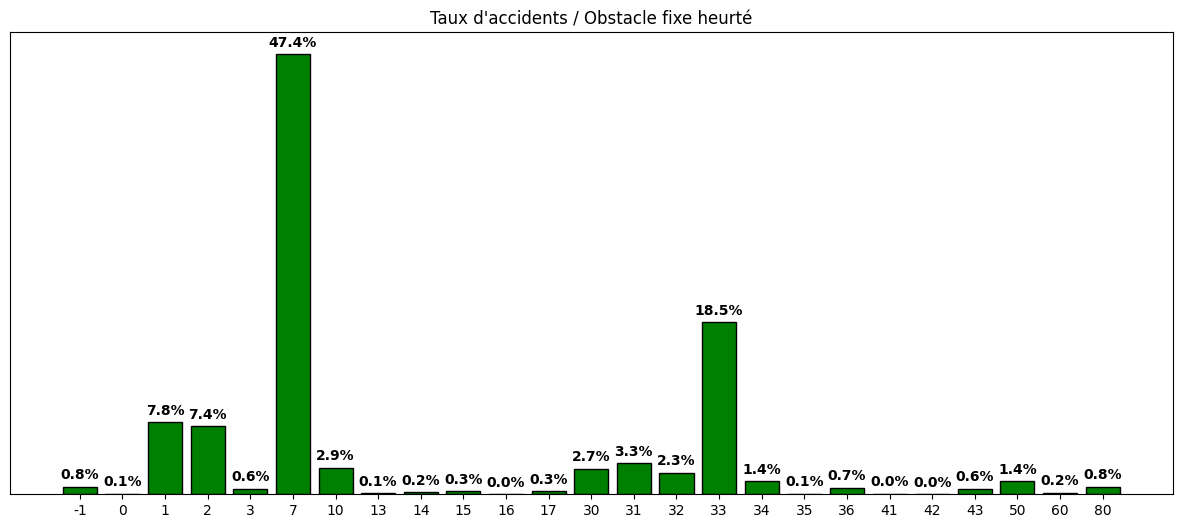

In [49]:
# Calcul basé uniquement sur la colonne 'gravite'
tue_bhos = df_final.groupby('catv')[['gravite']].sum()

# Calcul du taux de danger pour chaque catégorie
total = tue_bhos['gravite'].sum()
tue_bhos['Taux'] = tue_bhos['gravite'] / total * 100

# Création du graphique
plt.figure(figsize=(15, 6))
bars = plt.bar(tue_bhos.index.astype(str), tue_bhos['Taux'], color='green', edgecolor='black')

# Affichage du pourcentage uniquement
for bar, taux in zip(bars, tue_bhos['Taux']):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,
             height + 0.5,
             f"{taux:.1f}%",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Titres et axes
plt.title("Taux d'accidents / Obstacle fixe heurté")
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.gca().axes.get_yaxis().set_visible(False)

plt.show()


In [50]:
df_final['catv'].isna().sum()

np.int64(0)

In [51]:
# Libellés d'origine
libelles_originaux = {
     0: 'Indéterminable',
     1: 'Bicyclette',
     2: 'Cyclomoteur <50cm3',
     3: 'Voiturette',
     7: 'VL seul',
    10: 'VU seul 1.5T <= PTAC <= 3.5T',
    13: 'PL seul 3',
    14: 'PL seul > 7.5T',
    15: 'PL > 3.5T + remorque',
    16: 'Tracteur routier seul',
    17: 'Tracteur routier + semi-remorque',
    20: 'Engin spécial',
    21: 'Tracteur agricole',
    30: 'Scooter < 50 cm3',
    31: 'Motocyclette > 50 cm3 et <= 125 cm3',
    32: 'Scooter > 50 cm3 et <= 125 cm3',
    33: 'Motocyclette > 125 cm3',
    34: 'Scooter > 125 cm3',
    35: 'Quad léger <= 50 cm3',
    36: 'Quad lourd > 50 cm3',
    37: 'Autobus',
    38: 'Autocar',
    39: 'Train',
    40: 'Tramway',
    41: '3RM <= 50 cm3',
    42: '3RM > 50 cm3 <= 125 cm3',
    43: '3RM > 125 cm3',
    50: 'EDP à moteur', # trottinettes et patinettes électriques, les gyropodes, les monoroues ou les hoverboards
    60: 'EDP sans moteur',
    80: 'VAE',          # vélo à assistance électrique
    99: 'Autre véhicule',
}

# Dictionnaire des regroupements (libellés)
regroupement = {
     0: 'Autres',
     1: 'Deux roues - 50 cm3',
     2: 'Deux roues - 50 cm3',
     3: 'Deux roues - 50 cm3',
     7: 'Voiture',
    10: 'Voiture',
    13: 'Poids lourd',
    14: 'Poids lourd',
    15: 'Poids lourd',
    16: 'Poids lourd',
    17: 'Poids lourd',
    20: 'Autres',
    21: 'Autres',
    30: 'Deux roues - 50 cm3',
    31: 'Deux roues + 50 cm3',
    32: 'Deux roues + 50 cm3',
    33: 'Deux roues + 50 cm3',
    34: 'Deux roues + 50 cm3',
    35: 'Deux roues - 50 cm3',
    36: 'Deux roues + 50 cm3',
    37: 'Autres',
    38: 'Autres',
    39: 'Autres',
    40: 'Autres',
    41: 'Deux roues - 50 cm3',
    42: 'Deux roues + 50 cm3',
    43: 'Deux roues + 50 cm3',
    50: 'Deux roues - 50 cm3',
    60: 'Deux roues - 50 cm3',
    80: 'Deux roues - 50 cm3',
    99: 'Autres',
}

# Dictionnaire des codes numériques pour les nouvelles catégories
categorie = {
    "Voiture": 1,             # VL
    "Deux roues - 50 cm3": 2, # deux_moins
    "Deux roues + 50 cm3": 3, # deux_plus
    "Poids lourd": 4,         # PL
    "Autres": 5,              # aut_catr
}

# Tableau de correspondance
tableau_correspondance = pd.DataFrame([
    {
        "Code": code,
        "Ancienne catégorie": libelles_originaux[code],
        "Nouvelle catégorie": regroupement[code],
        "Code New": categorie[regroupement[code]]
    }
    for code in sorted(libelles_originaux.keys())
])

# Affichage avec rich
table = Table(title="Correspondance des LUMINOSITÉS")

table.add_column("Code", style="bold green")
table.add_column("Ancienne catégorie", style="bold green")
table.add_column("Nouvelle catégorie", style="bold magenta")
table.add_column("Code New", style="bold magenta")

for _, row in tableau_correspondance.iterrows():
    table.add_row(
        str(row["Code"]),
        str(row["Ancienne catégorie"]),
        str(row["Nouvelle catégorie"]),
        str(row["Code New"])
    )

console = Console()
console.print(table)

                        Correspondance des LUMINOSITÉS                         
┏━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Code ┃ Ancienne catégorie                  ┃ Nouvelle catégorie  ┃ Code New ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ 0    │ Indéterminable                      │ Autres              │ 5        │
│ 1    │ Bicyclette                          │ Deux roues - 50 cm3 │ 2        │
│ 2    │ Cyclomoteur <50cm3                  │ Deux roues - 50 cm3 │ 2        │
│ 3    │ Voiturette                          │ Deux roues - 50 cm3 │ 2        │
│ 7    │ VL seul                             │ Voiture             │ 1        │
│ 10   │ VU seul 1.5T <= PTAC <= 3.5T        │ Voiture             │ 1        │
│ 13   │ PL seul 3                           │ Poids lourd         │ 4        │
│ 14   │ PL seul > 7.5T                      │ Poids lourd         │ 4        │
│ 15   │ PL > 3.5T + remorque                │ Poids lourd         │ 4        │
│ 16   │ Tracteur routier seul               │ Poids lourd         │ 4        │
│ 17   │ Tracteur routier + semi-remorque    │ Poids lourd         │ 4        │
│ 20   │ Engin spécial                       │ Autres              │ 5        │
│ 21   │ Tracteur agricole                   │ Autres              │ 5        │
│ 30   │ Scooter < 50 cm3                    │ Deux roues - 50 cm3 │ 2        │
│ 31   │ Motocyclette > 50 cm3 et <= 125 cm3 │ Deux roues + 50 cm3 │ 3        │
│ 32   │ Scooter > 50 cm3 et <= 125 cm3      │ Deux roues + 50 cm3 │ 3        │
│ 33   │ Motocyclette > 125 cm3              │ Deux roues + 50 cm3 │ 3        │
│ 34   │ Scooter > 125 cm3                   │ Deux roues + 50 cm3 │ 3        │
│ 35   │ Quad léger <= 50 cm3                │ Deux roues - 50 cm3 │ 2        │
│ 36   │ Quad lourd > 50 cm3                 │ Deux roues + 50 cm3 │ 3        │
│ 37   │ Autobus                             │ Autres              │ 5        │
│ 38   │ Autocar                             │ Autres              │ 5        │
│ 39   │ Train                               │ Autres              │ 5        │
│ 40   │ Tramway                             │ Autres              │ 5        │
│ 41   │ 3RM <= 50 cm3                       │ Deux roues - 50 cm3 │ 2        │
│ 42   │ 3RM > 50 cm3 <= 125 cm3             │ Deux roues + 50 cm3 │ 3        │
│ 43   │ 3RM > 125 cm3                       │ Deux roues + 50 cm3 │ 3        │
│ 50   │ EDP à moteur                        │ Deux roues - 50 cm3 │ 2        │
│ 60   │ EDP sans moteur                     │ Deux roues - 50 cm3 │ 2        │
│ 80   │ VAE                                 │ Deux roues - 50 cm3 │ 2        │
│ 99   │ Autre véhicule                      │ Autres              │ 5        │
└──────┴─────────────────────────────────────┴─────────────────────┴──────────┘

In [52]:
df_final.head()

,Num_Acc,catu,sexe,ind,tue,bhosp,bleger,catv,obs,obsm,jour,mois,an,lum,dep,com,agg,int,atm,col,lat,long,catr,circ,vosp,prof,plan,larrout,surf,infra,situ,vma,heure,gravite
0,201900000001,2,2,0,0,0,1,7,0,2,30,11,2019,4,93,93053,1,1,1,2,48.896210,2.470120,1,3,0,1,2,0,1,2,1,70.0,1,0
1,201900000001,1,2,0,0,0,1,7,0,2,30,11,2019,4,93,93053,1,1,1,2,48.896210,2.470120,1,3,0,1,2,0,1,2,1,70.0,1,0
2,201900000001,1,1,1,0,0,0,17,1,0,30,11,2019,4,93,93053,1,1,1,2,48.896210,2.470120,1,3,0,1,2,0,1,2,1,70.0,1,0
3,201900000002,1,2,0,0,0,1,7,4,0,30,11,2019,3,93,93066,1,1,1,6,48.930700,2.368800,1,1,0,4,2,0,1,0,1,70.0,2,0
4,201900000003,1,1,1,0,0,0,7,0,2,28,11,2019,1,92,92036,1,1,1,4,48.935872,2.319174,1,3,0,1,3,0,1,0,1,90.0,15,0


In [53]:
df_final['catv'].unique()

array([ 7, 17, 33, 42, 30, 32, 50, -1, 10,  1, 15, 14,  2, 80, 34, 60, 31,
        0,  3, 13, 36, 43, 16, 35, 41])

In [54]:
df_final['catv'].value_counts().sort_index()

,count
catv,
-1,10327
0,519
1,23887
2,16727
3,2870
7,308438
10,31724
13,1771
14,3326


In [55]:
df_final['catv'] = df_final['catv'].apply(
                                           lambda x: 1 if x in [7, 10]
                                                else 2 if x in [1, 2, 3, 30, 36, 41, 42, 43]
                                                else 3 if x in [31, 32, 33, 34, 35, 41, 42, 43, 50, 60, 80]
                                                else 4 if x in [13, 14, 15, 16, 17]
                                                else 5 if x == 0
                                                else x)
df_final['catv'] = df_final['catv'].astype(int)

In [56]:
df_final['catv'].unique()

array([ 1,  4,  3,  2, -1,  5])

#### **Distribution nouvelle**

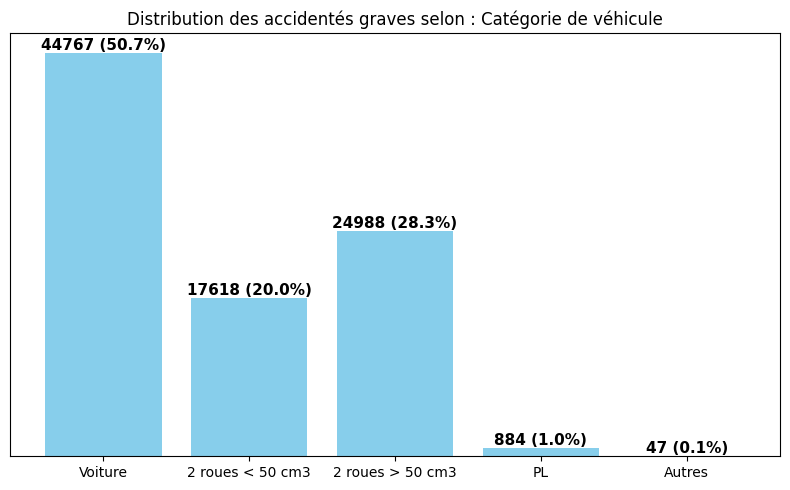

In [57]:
col = "catv"

# Filtrer uniquement les accidents graves
df_graves = df_final[df_final['gravite'] > 0]

# Comptage
lum_groups = {
    "Voiture": df_graves[df_graves[col] == 1].shape[0],
    "2 roues < 50 cm3": df_graves[df_graves[col] == 2].shape[0],
    "2 roues > 50 cm3": df_graves[df_graves[col] == 3].shape[0],
    "PL": df_graves[df_graves[col] == 4].shape[0],
    "Autres": df_graves[df_graves[col] == 5].shape[0]
}

# Total pour les pourcentages
total = sum(lum_groups.values())

# Création du graphique
plt.figure(figsize=(8, 5))
bars = plt.bar(lum_groups.keys(), lum_groups.values(), color='skyblue')

# Ajouter les valeurs et pourcentages au-dessus des barres
for bar in bars:
    height = bar.get_height()
    pourcent = (height / total) * 100 if total > 0 else 0
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        f"{int(height)} ({pourcent:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Supprimer l'axe Y
plt.gca().axes.get_yaxis().set_visible(False)

# Titres
plt.xlabel("")
plt.title(f"Distribution des accidentés graves selon : {noms_colonnes[col]}")
plt.tight_layout()
plt.show()


### **Luminosité 'lum'**

#### **Ré-encodage**

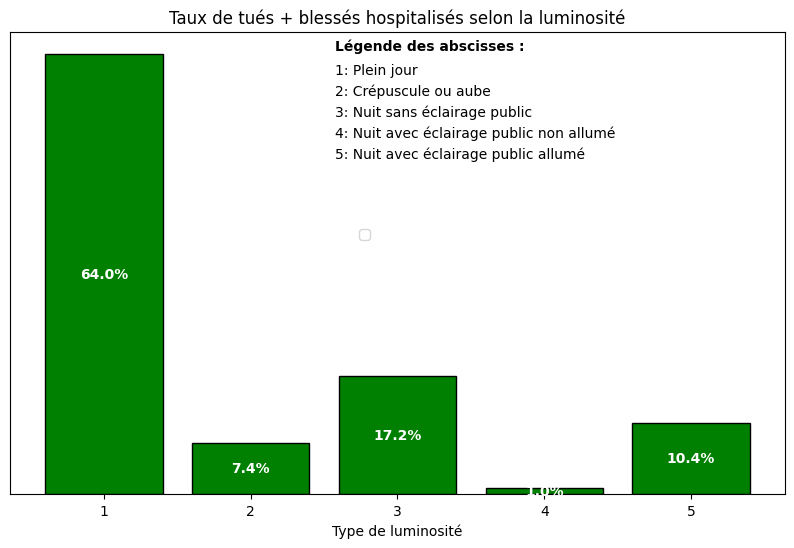

In [58]:
# Calcul basé uniquement sur la colonne 'gravite'
tue_bhos = df_final.groupby('lum')[['gravite']].sum()

# Calcul du taux de danger pour chaque catégorie
total = tue_bhos['gravite'].sum()
tue_bhos['Taux'] = tue_bhos['gravite'] / total * 100

# Création du graphique
plt.figure(figsize=(10, 6))
bars = plt.bar(tue_bhos.index.astype(str), tue_bhos['Taux'], color='green', edgecolor='black')

# Afficher les taux sur les barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,
             height / 2,
             f"{height:.1f}%",
             ha='center',
             va='center',
             fontsize=10,
             fontweight='bold',
             color='white')

# Titres et axes
plt.title("Taux de tués + blessés hospitalisés selon la luminosité")
plt.xlabel("Type de luminosité")
plt.ylabel("Pourcentage")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.gca().axes.get_yaxis().set_visible(False)

# Légende5
plt.legend(loc=(0.45, 0.55))  # x = 35%, y = 90% de la figure

# Légende explicative hors graphique
legende_lum = {
    1: 'Plein jour',
    2: "Crépuscule ou aube",
    3: "Nuit sans éclairage public",
    4: "Nuit avec éclairage public non allumé",
    5: "Nuit avec éclairage public allumé"
}
plt.figtext(0.45, 0.85, "Légende des abscisses :", fontsize=10, fontweight='bold')
for i, (k, v) in enumerate(legende_lum.items()):
    plt.figtext(0.45, 0.81 - i * 0.035, f"{k}: {v}", fontsize=10)

plt.show()


In [59]:
# Libellés d'origine
libelles_originaux = {
    1: 'Plein jour',
    2: "Crépuscule ou aube",
    3: "Nuit sans éclairage public",
    4: "Nuit avec éclairage public non allumé",
    5: "Nuit avec éclairage public allumé"
}

# Dictionnaire des regroupements (libellés)
regroupement = {
    1: "Plein jour",
    2: "Nocturne",
    3: "Nocturne",
    4: "Nocturne",
    5: "Nocturne"
}

# Dictionnaire des codes numériques pour les nouvelles catégories
categorie = {
    "Plein jour": 1,
    "Nocturne": 2
}

# Tableau de correspondance indépendant de df_final
tableau_correspondance = pd.DataFrame([
    {
        "Code": code,
        "Ancienne catégorie": libelles_originaux[code],
        "Nouvelle catégorie": regroupement[code],
        "Code New": categorie[regroupement[code]]
    }
    for code in sorted(libelles_originaux.keys())
])

# Affichage avec rich
table = Table(title="Correspondance des LUMINOSITÉS")

table.add_column("Code", style="bold green")
table.add_column("Ancienne catégorie", style="bold green")
table.add_column("Nouvelle catégorie", style="bold magenta")
table.add_column("Code New", style="bold magenta")

for _, row in tableau_correspondance.iterrows():
    table.add_row(
        str(row["Code"]),
        str(row["Ancienne catégorie"]),
        str(row["Nouvelle catégorie"]),
        str(row["Code New"])
    )

console = Console()
console.print(table)


                         Correspondance des LUMINOSITÉS                         
┏━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Code ┃ Ancienne catégorie                    ┃ Nouvelle catégorie ┃ Code New ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ 1    │ Plein jour                            │ Plein jour         │ 1        │
│ 2    │ Crépuscule ou aube                    │ Nocturne           │ 2        │
│ 3    │ Nuit sans éclairage public            │ Nocturne           │ 2        │
│ 4    │ Nuit avec éclairage public non allumé │ Nocturne           │ 2        │
│ 5    │ Nuit avec éclairage public allumé     │ Nocturne           │ 2        │
└──────┴───────────────────────────────────────┴────────────────────┴──────────┘

In [60]:
df_final['lum'] = df_final['lum'].apply(lambda x: 1 if x == 1 else 2)

#### **Distribution nouvelle**

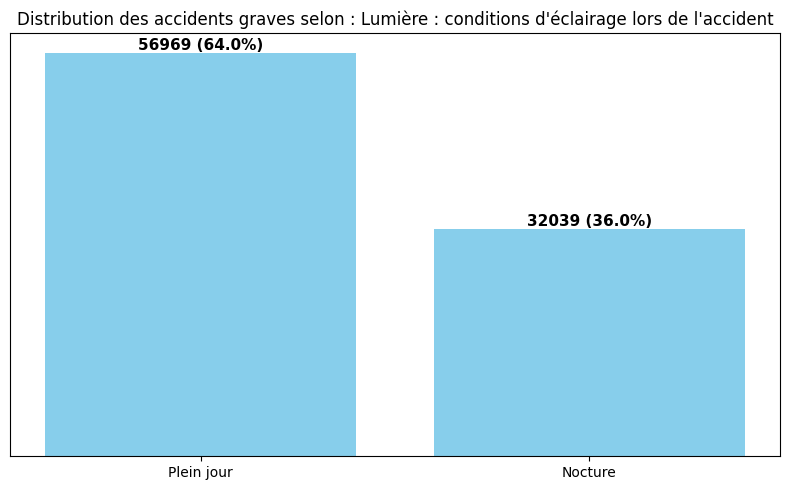

In [61]:
col = "lum"

# Filtrer uniquement les accidents graves
df_graves = df_final[df_final['gravite'] > 0]

# Comptage
lum_groups = {
    "Plein jour": df_graves[df_graves[col] == 1].shape[0],
    "Nocture": df_graves[df_graves[col] == 2].shape[0]
}

# Total pour les pourcentages
total = sum(lum_groups.values())

# Création du graphique
plt.figure(figsize=(8, 5))
bars = plt.bar(lum_groups.keys(), lum_groups.values(), color='skyblue')

# Ajouter les valeurs et pourcentages au-dessus des barres
for bar in bars:
    height = bar.get_height()
    pourcent = (height / total) * 100 if total > 0 else 0
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        f"{int(height)} ({pourcent:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Supprimer l'axe Y
plt.gca().axes.get_yaxis().set_visible(False)

# Titres
plt.xlabel("")
plt.title(f"Distribution des accidents graves selon : {noms_colonnes[col]}")
plt.tight_layout()
plt.show()


### **Conditions atmosphériques 'atm'**

#### **Ré-encodage**

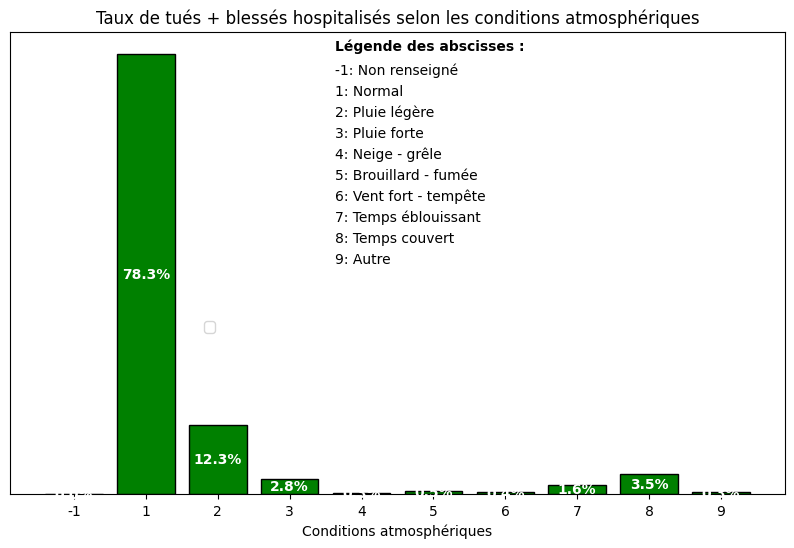

In [62]:
# Calcul basé uniquement sur la colonne 'gravite'
tue_bhos = df.groupby('atm')[['gravite']].sum()

# Calcul du taux de danger pour chaque catégorie
total = tue_bhos['gravite'].sum()
tue_bhos['Taux'] = tue_bhos['gravite'] / total * 100

# Création du graphique
plt.figure(figsize=(10, 6))
bars = plt.bar(tue_bhos.index.astype(str), tue_bhos['Taux'], color='green', edgecolor='black')

# Afficher les taux sur les barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,
             height / 2,
             f"{height:.1f}%",
             ha='center',
             va='center',
             fontsize=10,
             fontweight='bold',
             color='white')

# Titres et axes
plt.title("Taux de tués + blessés hospitalisés selon les conditions atmosphériques")
plt.xlabel("Conditions atmosphériques")
plt.ylabel("Pourcentage")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.gca().axes.get_yaxis().set_visible(False)

# Légende5
plt.legend(loc=(0.25, 0.35))  # x = 35%, y = 90% de la figure

# Légende explicative hors graphique
legende_atm = {
    -1: 'Non renseigné',
    1: 'Normal',
    2: 'Pluie légère',
    3: 'Pluie forte',
    4: 'Neige - grêle',
    5: 'Brouillard - fumée',
    6: 'Vent fort - tempête',
    7: 'Temps éblouissant',
    8: 'Temps couvert',
    9: 'Autre',
}
plt.figtext(0.45, 0.85, "Légende des abscisses :", fontsize=10, fontweight='bold')
for i, (k, v) in enumerate(legende_atm.items()):
    plt.figtext(0.45, 0.81 - i * 0.035, f"{k}: {v}", fontsize=10)

plt.show()


In [63]:
# Libellés d'origine
libelles_originaux = {
    -1: 'Non renseigné',
    1: 'Normal',
    2: 'Pluie légère',
    3: 'Pluie forte',
    4: 'Neige - grêle',
    5: 'Brouillard - fumée',
    6: 'Vent fort - tempête',
    7: 'Temps éblouissant',
    8: 'Temps couvert',
    9: 'Autre',

}

# Dictionnaire des regroupements (libellés)
regroupement = {
    -1: 'Autre',
    1: 'Normal',
    2: 'Pluie',
    3: 'Pluie',
    4: 'Pluie',
    5: 'Autre',
    6: 'Autre',
    7: 'Autre',
    8: 'Autre',
    9: 'Autre',
}

# Dictionnaire des codes numériques pour les nouvelles catégories
categorie = {
    "Normal": 1,
    "Pluie": 2,
    "Autre": 3
}

# Tableau de correspondance indépendant de df_final
tableau_correspondance = pd.DataFrame([
    {
        "Code": code,
        "Ancienne catégorie": libelles_originaux[code],
        "Nouvelle catégorie": regroupement[code],
        "Code New": categorie[regroupement[code]]
    }
    for code in sorted(libelles_originaux.keys())
])

# Affichage avec rich
table = Table(title="Correspondance des CONDITIONS ATMOSPHÉRIQUES")

table.add_column("Code", style="bold green")
table.add_column("Ancienne catégorie", style="bold green")
table.add_column("Nouvelle catégorie", style="bold magenta")
table.add_column("Code New", style="bold magenta")

for _, row in tableau_correspondance.iterrows():
    table.add_row(
        str(row["Code"]),
        str(row["Ancienne catégorie"]),
        str(row["Nouvelle catégorie"]),
        str(row["Code New"])
    )

console = Console()
console.print(table)


         Correspondance des CONDITIONS ATMOSPHÉRIQUES         
┏━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Code ┃ Ancienne catégorie  ┃ Nouvelle catégorie ┃ Code New ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ -1   │ Non renseigné       │ Autre              │ 3        │
│ 1    │ Normal              │ Normal             │ 1        │
│ 2    │ Pluie légère        │ Pluie              │ 2        │
│ 3    │ Pluie forte         │ Pluie              │ 2        │
│ 4    │ Neige - grêle       │ Pluie              │ 2        │
│ 5    │ Brouillard - fumée  │ Autre              │ 3        │
│ 6    │ Vent fort - tempête │ Autre              │ 3        │
│ 7    │ Temps éblouissant   │ Autre              │ 3        │
│ 8    │ Temps couvert       │ Autre              │ 3        │
│ 9    │ Autre               │ Autre              │ 3        │
└──────┴─────────────────────┴────────────────────┴──────────┘

In [64]:
df_final['atm'] = df_final['atm'].apply(lambda x: 2 if x in [3, 4] else 3 if x in [-1, 5, 6, 7, 8, 9] else x)


#### **Distribution nouvelle**

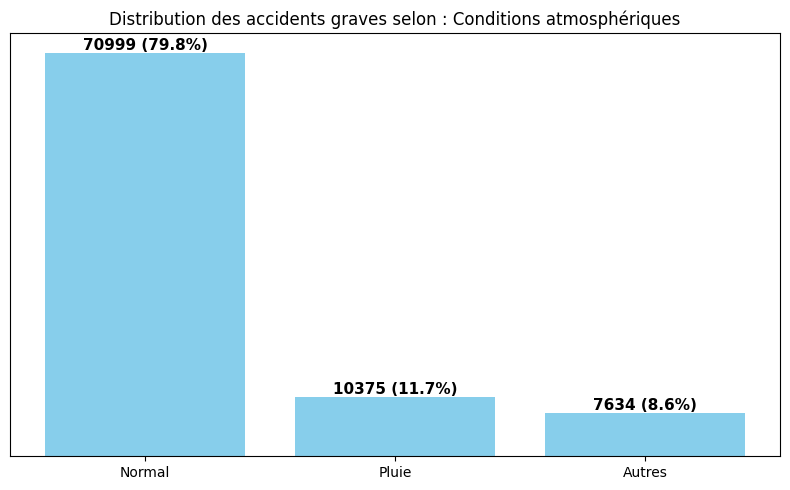

In [65]:
col = "atm"

# Filtrer uniquement les accidents graves
df_graves = df_final[df_final['gravite'] > 0]

# Comptage
lum_groups = {
    "Normal": df_graves[df_graves[col] == 1].shape[0],
    "Pluie": df_graves[df_graves[col] == 2].shape[0],
    "Autres": df_graves[df_graves[col] == 3].shape[0]
}

# Total pour les pourcentages
total = sum(lum_groups.values())

# Création du graphique
plt.figure(figsize=(8, 5))
bars = plt.bar(lum_groups.keys(), lum_groups.values(), color='skyblue')

# Ajouter les valeurs et pourcentages au-dessus des barres
for bar in bars:
    height = bar.get_height()
    pourcent = (height / total) * 100 if total > 0 else 0
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        f"{int(height)} ({pourcent:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Supprimer l'axe Y
plt.gca().axes.get_yaxis().set_visible(False)

# Titres
plt.xlabel("")
plt.title(f"Distribution des accidents graves selon : {noms_colonnes[col]}")
plt.tight_layout()
plt.show()


### **Type d'intersections 'int'**

#### **Ré-encodage**

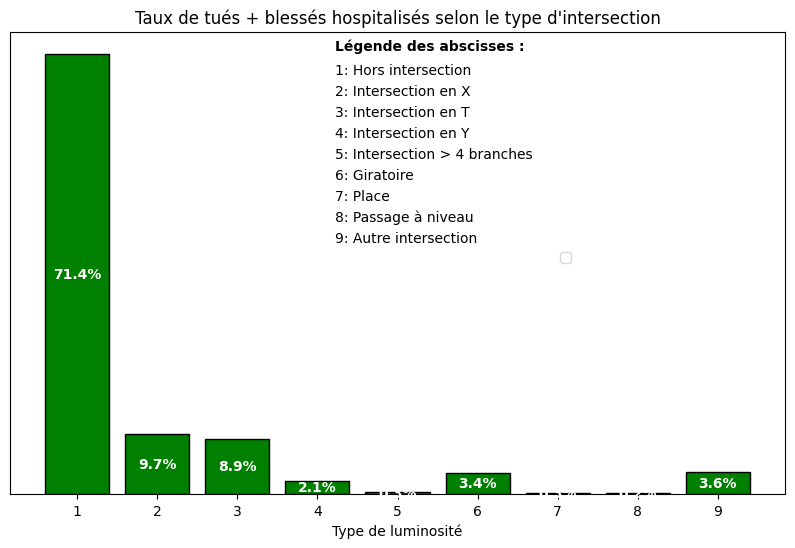

In [66]:
# Calcul basé uniquement sur la colonne 'gravite'
tue_bhos = df_final.groupby('int')[['gravite']].sum()

# Calcul du taux de danger pour chaque catégorie
total = tue_bhos['gravite'].sum()
tue_bhos['Taux'] = tue_bhos['gravite'] / total * 100

# Création du graphique
plt.figure(figsize=(10, 6))
bars = plt.bar(tue_bhos.index.astype(str), tue_bhos['Taux'], color='green', edgecolor='black')

# Afficher les taux sur les barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,
             height / 2,
             f"{height:.1f}%",
             ha='center',
             va='center',
             fontsize=10,
             fontweight='bold',
             color='white')

# Titres et axes
plt.title("Taux de tués + blessés hospitalisés selon le type d'intersection")
plt.xlabel("Type de luminosité")
plt.ylabel("Pourcentage")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.gca().axes.get_yaxis().set_visible(False)

# Légende
plt.legend(loc=(0.71, 0.5))  # x = 35%, y = 90% de la figure

# Légende explicative hors graphique
legende_int = {
    1: 'Hors intersection',
    2: 'Intersection en X',
    3: 'Intersection en T',
    4: 'Intersection en Y',
    5: 'Intersection > 4 branches',
    6: 'Giratoire',
    7: 'Place',
    8: 'Passage à niveau',
    9: 'Autre intersection',
}
plt.figtext(0.45, 0.85, "Légende des abscisses :", fontsize=10, fontweight='bold')
for i, (k, v) in enumerate(legende_int.items()):
    plt.figtext(0.45, 0.81 - i * 0.035, f"{k}: {v}", fontsize=10)

plt.show()


In [67]:
# Libellés d'origine
libelles_originaux = {
    1: 'Hors intersection',
    2: 'Intersection en X',
    3: 'Intersection en T',
    4: 'Intersection en Y',
    5: 'Intersection > 4 branches',
    6: 'Giratoire',
    7: 'Place',
    8: 'Passage à niveau',
    9: 'Autre intersection',
}

# Regroupement
regroupement = {
    1: 'Hors intersection',
    2: 'Avec intersection',
    3: 'Avec intersection',
    4: 'Avec intersection',
    5: 'Avec intersection',
    6: 'Autre',
    7: 'Autre',
    8: 'Autre',
    9: 'Autre',
}

# Code
categorie = {
    "Hors intersection": 1,
    "Avec intersection": 2,
    "Autre": 3
}

# Tableau de correspondance indépendant de df_final
tableau_correspondance = pd.DataFrame([
    {
        "Code": code,
        "Ancienne catégorie": libelles_originaux[code],
        "Nouvelle catégorie": regroupement[code],
        "Code New": categorie[regroupement[code]]
    }
    for code in sorted(libelles_originaux.keys())
])

# Affichage avec rich
table = Table(title="Correspondance des INTERSECTIONS")

table.add_column("Code", style="bold green")
table.add_column("Ancienne catégorie", style="bold green")
table.add_column("Nouvelle catégorie", style="bold magenta")
table.add_column("Code New", style="bold magenta")

for _, row in tableau_correspondance.iterrows():
    table.add_row(
        str(row["Code"]),
        str(row["Ancienne catégorie"]),
        str(row["Nouvelle catégorie"]),
        str(row["Code New"])
    )

console = Console()
console.print(table)


                  Correspondance des INTERSECTIONS                  
┏━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Code ┃ Ancienne catégorie        ┃ Nouvelle catégorie ┃ Code New ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ 1    │ Hors intersection         │ Hors intersection  │ 1        │
│ 2    │ Intersection en X         │ Avec intersection  │ 2        │
│ 3    │ Intersection en T         │ Avec intersection  │ 2        │
│ 4    │ Intersection en Y         │ Avec intersection  │ 2        │
│ 5    │ Intersection > 4 branches │ Avec intersection  │ 2        │
│ 6    │ Giratoire                 │ Autre              │ 3        │
│ 7    │ Place                     │ Autre              │ 3        │
│ 8    │ Passage à niveau          │ Autre              │ 3        │
│ 9    │ Autre intersection        │ Autre              │ 3        │
└──────┴───────────────────────────┴────────────────────┴──────────┘

In [68]:
df_final['int'] = df_final['int'].apply(lambda x: 2 if x in [3, 4, 5] else 3 if x in [6, 7, 8, 9] else x)

#### **Distribution nouvelle**

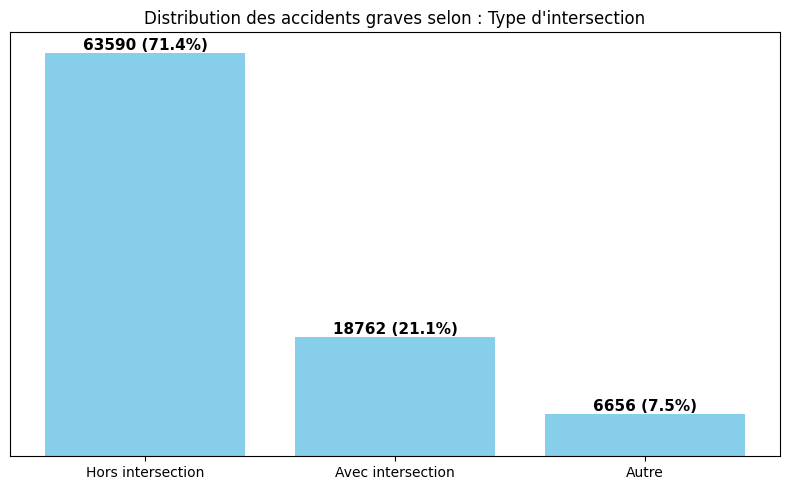

In [69]:
col = "int"

# Filtrer uniquement les accidents graves
df_graves = df_final[df_final['gravite'] > 0]

# Comptage
lum_groups = {
    "Hors intersection": df_graves[df_graves[col] == 1].shape[0],
    "Avec intersection": df_graves[df_graves[col] == 2].shape[0],
    "Autre": df_graves[df_graves[col] == 3].shape[0]
}

# Total pour les pourcentages
total = sum(lum_groups.values())

# Création du graphique
plt.figure(figsize=(8, 5))
bars = plt.bar(lum_groups.keys(), lum_groups.values(), color='skyblue')

# Ajouter les valeurs et pourcentages au-dessus des barres
for bar in bars:
    height = bar.get_height()
    pourcent = (height / total) * 100 if total > 0 else 0
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        f"{int(height)} ({pourcent:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Supprimer l'axe Y
plt.gca().axes.get_yaxis().set_visible(False)

# Titres
plt.xlabel("")
plt.title(f"Distribution des accidents graves selon : {noms_colonnes[col]}")
plt.tight_layout()
plt.show()


### **État de la surface 'surf'**

#### **Ré-encodage**

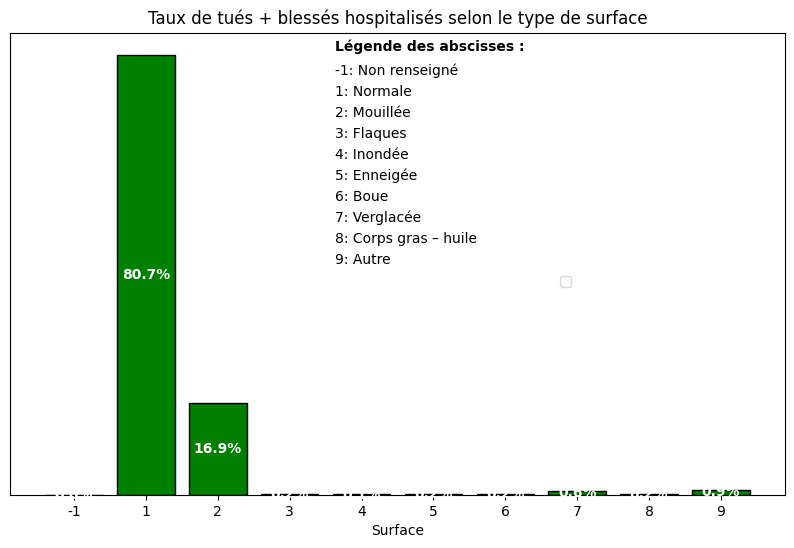

In [70]:
# Calcul basé uniquement sur la colonne 'gravite'
tue_bhos = df_final.groupby('surf')[['gravite']].sum()

# Calcul du taux de danger pour chaque catégorie
total = tue_bhos['gravite'].sum()
tue_bhos['Taux'] = tue_bhos['gravite'] / total * 100

# Création du graphique
plt.figure(figsize=(10, 6))
bars = plt.bar(tue_bhos.index.astype(str), tue_bhos['Taux'], color='green', edgecolor='black')

# Afficher les taux sur les barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,
             height / 2,
             f"{height:.1f}%",
             ha='center',
             va='center',
             fontsize=10,
             fontweight='bold',
             color='white')

# Titres et axes
plt.title("Taux de tués + blessés hospitalisés selon le type de surface")
plt.xlabel("Surface")
plt.ylabel("Pourcentage")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.gca().axes.get_yaxis().set_visible(False)

# Légende
plt.legend(loc=(0.71, 0.45))  # x = 35%, y = 90% de la figure

# Légende explicative hors graphique
legende_surf = {
    -1: 'Non renseigné',
    1: 'Normale',
    2: 'Mouillée',
    3: 'Flaques',
    4: 'Inondée',
    5: 'Enneigée',
    6: 'Boue',
    7: 'Verglacée',
    8: 'Corps gras – huile',
    9: 'Autre',
}
plt.figtext(0.45, 0.85, "Légende des abscisses :", fontsize=10, fontweight='bold')
for i, (k, v) in enumerate(legende_surf.items()):
    plt.figtext(0.45, 0.81 - i * 0.035, f"{k}: {v}", fontsize=10)

plt.show()


In [71]:
# Libellés d'origine
libelles_originaux = {
    -1: 'Non renseigné',
    1: 'Normale',
    2: 'Mouillée',
    3: 'Flaques',
    4: 'Inondée',
    5: 'Enneigée',
    6: 'Boue',
    7: 'Verglacée',
    8: 'Corps gras – huile',
    9: 'Autre',
}


# Dictionnaire des regroupements (libellés)
regroupement = {
    -1: 'Autres',
    1: 'Normale',
    2: 'Mouillée',
    3: 'Glissante',
    4: 'Glissante',
    5: 'Glissante',
    6: 'Glissante',
    7: 'Glissante',
    8: 'Glissante',
    9: 'Autres',
}

# Dictionnaire des codes numériques pour les nouvelles catégories
categorie = {
    "Normale": 1,
    "Mouillée": 2,
    "Glissante": 3,
    "Autres": 4
}

# Tableau de correspondance indépendant de df_final
tableau_correspondance = pd.DataFrame([
    {
        "Code": code,
        "Ancienne catégorie": libelles_originaux[code],
        "Nouvelle catégorie": regroupement[code],
        "Code New": categorie[regroupement[code]]
    }
    for code in sorted(libelles_originaux.keys())
])

# Affichage avec rich
table = Table(title="Correspondance des INTERSECTIONS")

table.add_column("Code", style="bold green")
table.add_column("Ancienne catégorie", style="bold green")
table.add_column("Nouvelle catégorie", style="bold magenta")
table.add_column("Code New", style="bold magenta")

for _, row in tableau_correspondance.iterrows():
    table.add_row(
        str(row["Code"]),
        str(row["Ancienne catégorie"]),
        str(row["Nouvelle catégorie"]),
        str(row["Code New"])
    )

console = Console()
console.print(table)

              Correspondance des INTERSECTIONS               
┏━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Code ┃ Ancienne catégorie ┃ Nouvelle catégorie ┃ Code New ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ -1   │ Non renseigné      │ Autres             │ 4        │
│ 1    │ Normale            │ Normale            │ 1        │
│ 2    │ Mouillée           │ Mouillée           │ 2        │
│ 3    │ Flaques            │ Glissante          │ 3        │
│ 4    │ Inondée            │ Glissante          │ 3        │
│ 5    │ Enneigée           │ Glissante          │ 3        │
│ 6    │ Boue               │ Glissante          │ 3        │
│ 7    │ Verglacée          │ Glissante          │ 3        │
│ 8    │ Corps gras – huile │ Glissante          │ 3        │
│ 9    │ Autre              │ Autres             │ 4        │
└──────┴────────────────────┴────────────────────┴──────────┘

In [72]:
df_final['surf'] = df_final['surf'].apply(lambda x: 3 if x in [3, 4, 5, 6, 7, 8] else 4 if x in [-1, 9] else x)

#### **Distribution nouvelle**

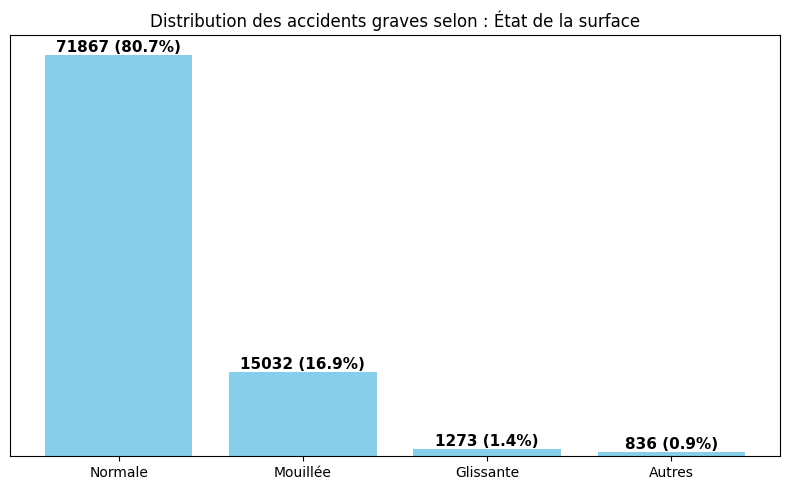

In [73]:
col = "surf"

# Filtrer uniquement les accidents graves
df_graves = df_final[df_final['gravite'] > 0]

# Comptage
lum_groups = {
    "Normale": df_graves[df_graves[col] == 1].shape[0],
    "Mouillée": df_graves[df_graves[col] == 2].shape[0],
    "Glissante": df_graves[df_graves[col] == 3].shape[0],
    "Autres": df_graves[df_graves[col] == 4].shape[0]
}

# Total pour les pourcentages
total = sum(lum_groups.values())

# Création du graphique
plt.figure(figsize=(8, 5))
bars = plt.bar(lum_groups.keys(), lum_groups.values(), color='skyblue')

# Ajouter les valeurs et pourcentages au-dessus des barres
for bar in bars:
    height = bar.get_height()
    pourcent = (height / total) * 100 if total > 0 else 0
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        f"{int(height)} ({pourcent:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Supprimer l'axe Y
plt.gca().axes.get_yaxis().set_visible(False)

# Titres
plt.xlabel("")
plt.title(f"Distribution des accidents graves selon : {noms_colonnes[col]}")
plt.tight_layout()
plt.show()


### **Catégorie de route 'catr'**

#### **Ré-encodage**

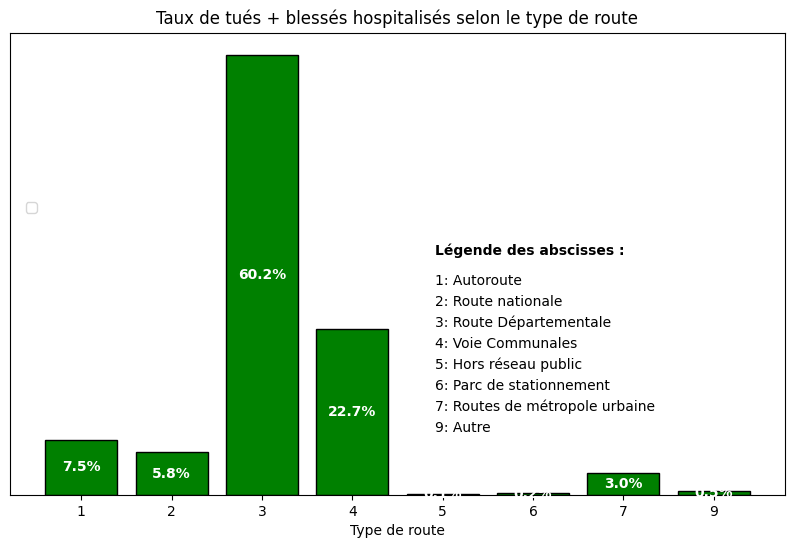

In [74]:
# Calcul basé uniquement sur la colonne 'gravite'
tue_bhos = df_final.groupby('catr')[['gravite']].sum()

# Calcul du taux de danger pour chaque catégorie
total = tue_bhos['gravite'].sum()
tue_bhos['Taux'] = tue_bhos['gravite'] / total * 100

# Création du graphique
plt.figure(figsize=(10, 6))
bars = plt.bar(tue_bhos.index.astype(str), tue_bhos['Taux'], color='green', edgecolor='black')

# Afficher les taux sur les barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,
             height / 2,
             f"{height:.1f}%",
             ha='center',
             va='center',
             fontsize=10,
             fontweight='bold',
             color='white')

# Titres et axes
plt.title("Taux de tués + blessés hospitalisés selon le type de route")
plt.xlabel("Type de route")
plt.ylabel("Pourcentage")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.gca().axes.get_yaxis().set_visible(False)

# Légende
plt.legend(loc=(0.02, 0.61))  # x = 35%, y = 90% de la figure

# Légende explicative hors graphique
legende_surf = {
    1: 'Autoroute',
    2: 'Route nationale',
    3: 'Route Départementale',
    4: 'Voie Communales',
    5: 'Hors réseau public',
    6: 'Parc de stationnement',
    7: 'Routes de métropole urbaine',
    9: 'Autre',

}
plt.figtext(0.55, 0.51, "Légende des abscisses :", fontsize=10, fontweight='bold')
for i, (k, v) in enumerate(legende_surf.items()):
    plt.figtext(0.55, 0.46 - i * 0.035, f"{k}: {v}", fontsize=10)

plt.show()


In [75]:
# Libellés d'origine
libelles_originaux = {
    1: 'Autoroute',
    2: 'Route nationale',
    3: 'Route Départementale',
    4: 'Voie Communales',
    5: 'Hors réseau public',
    6: 'Parc de stationnement',
    7: 'Routes de métropole urbaine',
    9: 'Autre',

}


# Dictionnaire des regroupements (libellés)
regroupement = {
    1: 'Autoroute',
    2: 'Nationale',
    3: 'Départementale',
    4: 'Communales',
    5: 'Autres',
    6: 'Autres',
    7: 'Autres',
    9: 'Autres',

}

# Dictionnaire des codes numériques pour les nouvelles catégories
categorie = {
  'Autoroute': 1,
  'Nationale': 2,
  'Départementale': 3,
  'Communales': 4,
  'Autres': 5,
}

# Tableau de correspondance indépendant de df_final
tableau_correspondance = pd.DataFrame([
    {
        "Code": code,
        "Ancienne catégorie": libelles_originaux[code],
        "Nouvelle catégorie": regroupement[code],
        "Code New": categorie[regroupement[code]]
    }
    for code in sorted(libelles_originaux.keys())
])

# Affichage avec rich
table = Table(title="Correspondance des CATÉGORIES DE ROUTES")

table.add_column("Code", style="bold green")
table.add_column("Ancienne catégorie", style="bold green")
table.add_column("Nouvelle catégorie", style="bold magenta")
table.add_column("Code New", style="bold magenta")

for _, row in tableau_correspondance.iterrows():
    table.add_row(
        str(row["Code"]),
        str(row["Ancienne catégorie"]),
        str(row["Nouvelle catégorie"]),
        str(row["Code New"])
    )

console = Console()
console.print(table)

               Correspondance des CATÉGORIES DE ROUTES                
┏━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Code ┃ Ancienne catégorie          ┃ Nouvelle catégorie ┃ Code New ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ 1    │ Autoroute                   │ Autoroute          │ 1        │
│ 2    │ Route nationale             │ Nationale          │ 2        │
│ 3    │ Route Départementale        │ Départementale     │ 3        │
│ 4    │ Voie Communales             │ Communales         │ 4        │
│ 5    │ Hors réseau public          │ Autres             │ 5        │
│ 6    │ Parc de stationnement       │ Autres             │ 5        │
│ 7    │ Routes de métropole urbaine │ Autres             │ 5        │
│ 9    │ Autre                       │ Autres             │ 5        │
└──────┴─────────────────────────────┴────────────────────┴──────────┘

In [76]:
df_final['catr'] = df_final['catr'].apply(lambda x: 5 if x in [6, 7, 9]  else x)

#### **Distribution nouvelle**

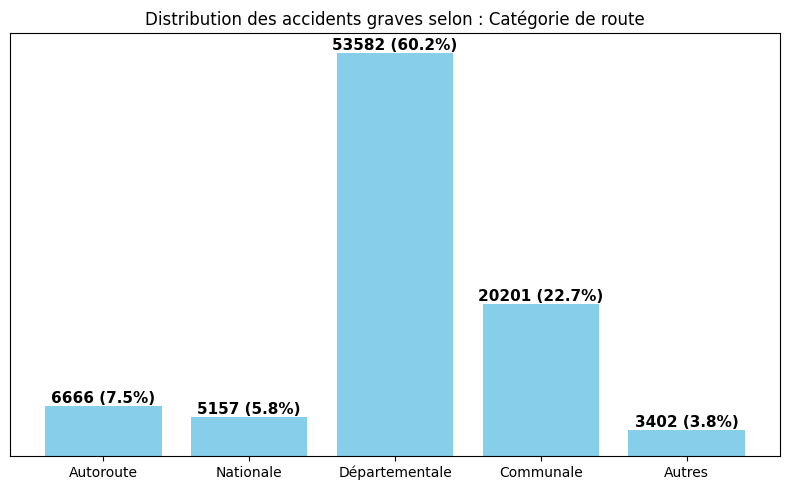

In [77]:
col = "catr"

# Filtrer uniquement les accidents graves
df_graves = df_final[df_final['gravite'] > 0]

# Comptage
lum_groups = {
    "Autoroute": df_graves[df_graves[col] == 1].shape[0],
    "Nationale": df_graves[df_graves[col] == 2].shape[0],
    "Départementale": df_graves[df_graves[col] == 3].shape[0],
    "Communale": df_graves[df_graves[col] == 4].shape[0],
    "Autres": df_graves[df_graves[col] == 5].shape[0]
}

# Total pour les pourcentages
total = sum(lum_groups.values())

# Création du graphique
plt.figure(figsize=(8, 5))
bars = plt.bar(lum_groups.keys(), lum_groups.values(), color='skyblue')

# Ajouter les valeurs et pourcentages au-dessus des barres
for bar in bars:
    height = bar.get_height()
    pourcent = (height / total) * 100 if total > 0 else 0
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        f"{int(height)} ({pourcent:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Supprimer l'axe Y
plt.gca().axes.get_yaxis().set_visible(False)

# Titres
plt.xlabel("")
plt.title(f"Distribution des accidents graves selon : {noms_colonnes[col]}")
plt.tight_layout()
plt.show()


### **Régime de circulation 'circ'**

#### **Ré-encodage**

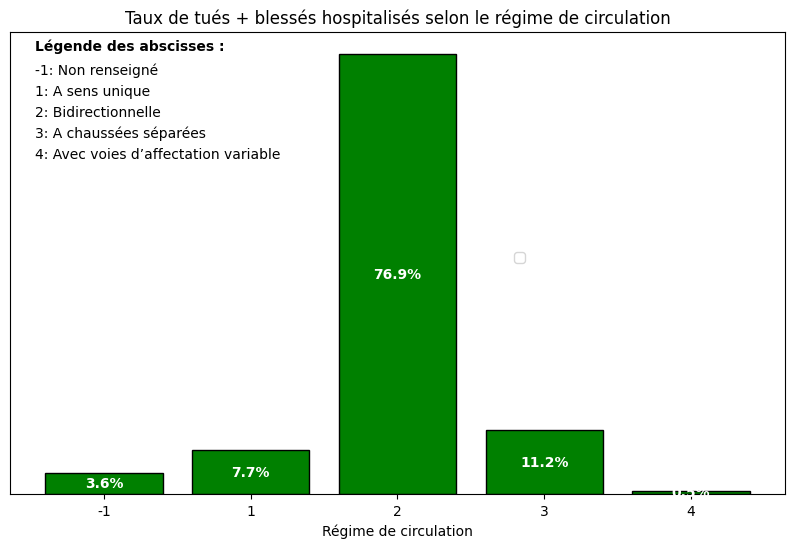

In [78]:
# Calcul basé uniquement sur la colonne 'gravite'
tue_bhos = df_final.groupby('circ')[['gravite']].sum()

# Calcul du taux de danger pour chaque catégorie
total = tue_bhos['gravite'].sum()
tue_bhos['Taux'] = tue_bhos['gravite'] / total * 100

# Création du graphique
plt.figure(figsize=(10, 6))
bars = plt.bar(tue_bhos.index.astype(str), tue_bhos['Taux'], color='green', edgecolor='black')

# Afficher les taux sur les barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,
             height / 2,
             f"{height:.1f}%",
             ha='center',
             va='center',
             fontsize=10,
             fontweight='bold',
             color='white')

# Titres et axes
plt.title("Taux de tués + blessés hospitalisés selon le régime de circulation")
plt.xlabel("Régime de circulation")
plt.ylabel("Pourcentage")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.gca().axes.get_yaxis().set_visible(False)

# Légende
plt.legend(loc=(0.65, 0.5))  # x = 35%, y = 90% de la figure

# Légende explicative hors graphique
legende_circ = {
    -1: 'Non renseigné',
    1: 'A sens unique',
    2: 'Bidirectionnelle',
    3: 'A chaussées séparées',
    4: 'Avec voies d’affectation variable',


}
plt.figtext(0.15, 0.85, "Légende des abscisses :", fontsize=10, fontweight='bold')
for i, (k, v) in enumerate(legende_circ.items()):
    plt.figtext(0.15, 0.81 - i * 0.035, f"{k}: {v}", fontsize=10)

plt.show()


In [79]:
# Libellés d'origine
libelles_originaux = {
    -1: 'Non renseigné',
    1: 'A sens unique',
    2: 'Bidirectionnelle',
    3: 'A chaussées séparées',
    4: 'Avec voies d’affectation variable',

}


# Dictionnaire des regroupements (libellés)
regroupement = {
    -1: 'Autres',
    1: 'Sens unique',
    2: 'Bidirectionnelle',
    3: 'Sens unique',
    4: 'Autres',

}

# Dictionnaire des codes numériques pour les nouvelles catégories
categorie = {
  'Sens unique': 1,
  'Bidirectionnelle': 2,
  'Autres': 3,
}

# Tableau de correspondance indépendant de df_final
tableau_correspondance = pd.DataFrame([
    {
        "Code": code,
        "Ancienne catégorie": libelles_originaux[code],
        "Nouvelle catégorie": regroupement[code],
        "Code New": categorie[regroupement[code]]
    }
    for code in sorted(libelles_originaux.keys())
])

# Affichage avec rich
table = Table(title="Correspondance des RÉGIMES DE CIRCULATION")

table.add_column("Code", style="bold green")
table.add_column("Ancienne catégorie", style="bold green")
table.add_column("Nouvelle catégorie", style="bold magenta")
table.add_column("Code New", style="bold magenta")

for _, row in tableau_correspondance.iterrows():
    table.add_row(
        str(row["Code"]),
        str(row["Ancienne catégorie"]),
        str(row["Nouvelle catégorie"]),
        str(row["Code New"])
    )

console = Console()
console.print(table)

                 Correspondance des RÉGIMES DE CIRCULATION                  
┏━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Code ┃ Ancienne catégorie                ┃ Nouvelle catégorie ┃ Code New ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ -1   │ Non renseigné                     │ Autres             │ 3        │
│ 1    │ A sens unique                     │ Sens unique        │ 1        │
│ 2    │ Bidirectionnelle                  │ Bidirectionnelle   │ 2        │
│ 3    │ A chaussées séparées              │ Sens unique        │ 1        │
│ 4    │ Avec voies d’affectation variable │ Autres             │ 3        │
└──────┴───────────────────────────────────┴────────────────────┴──────────┘

In [80]:
df_final['circ'] = df_final['circ'].apply(lambda x: 1 if x == 3 else 3 if x in [-1, 4] else x)

#### **Distribution nouvelle**

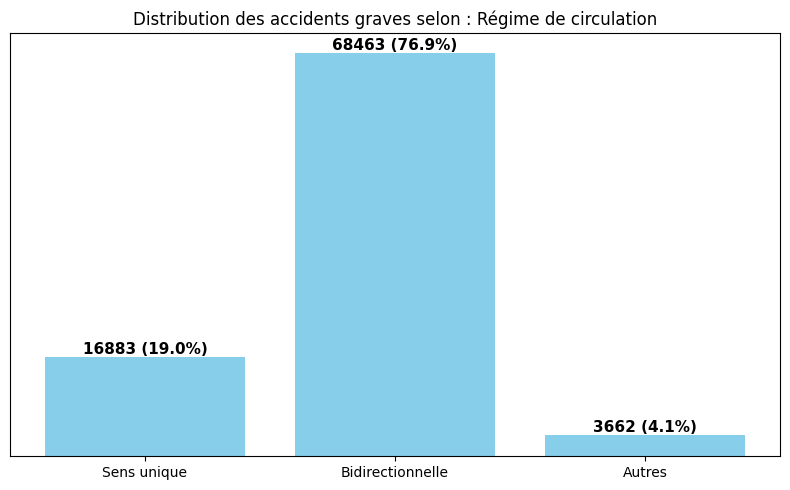

In [81]:
col = "circ"

# Filtrer uniquement les accidents graves
df_graves = df_final[df_final['gravite'] > 0]

# Comptage
lum_groups = {
    "Sens unique": df_graves[df_graves[col] == 1].shape[0],
    "Bidirectionnelle": df_graves[df_graves[col] == 2].shape[0],
    "Autres": df_graves[df_graves[col] == 3].shape[0]
}

# Total pour les pourcentages
total = sum(lum_groups.values())

# Création du graphique
plt.figure(figsize=(8, 5))
bars = plt.bar(lum_groups.keys(), lum_groups.values(), color='skyblue')

# Ajouter les valeurs et pourcentages au-dessus des barres
for bar in bars:
    height = bar.get_height()
    pourcent = (height / total) * 100 if total > 0 else 0
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        f"{int(height)} ({pourcent:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Supprimer l'axe Y
plt.gca().axes.get_yaxis().set_visible(False)

# Titres
plt.xlabel("")
plt.title(f"Distribution des accidents graves selon : {noms_colonnes[col]}")
plt.tight_layout()
plt.show()


### **Tracé en plan 'plan'**

#### **Ré-encodage**

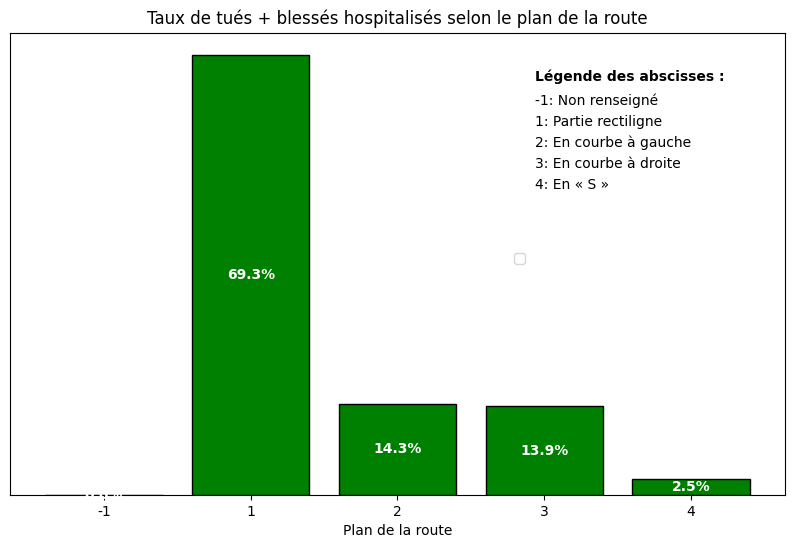

In [82]:
# Calcul basé uniquement sur la colonne 'gravite'
tue_bhos = df_final.groupby('plan')[['gravite']].sum()

# Calcul du taux de danger pour chaque catégorie
total = tue_bhos['gravite'].sum()
tue_bhos['Taux'] = tue_bhos['gravite'] / total * 100

# Création du graphique
plt.figure(figsize=(10, 6))
bars = plt.bar(tue_bhos.index.astype(str), tue_bhos['Taux'], color='green', edgecolor='black')

# Afficher les taux sur les barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,
             height / 2,
             f"{height:.1f}%",
             ha='center',
             va='center',
             fontsize=10,
             fontweight='bold',
             color='white')

# Titres et axes
plt.title("Taux de tués + blessés hospitalisés selon le plan de la route")
plt.xlabel("Plan de la route")
plt.ylabel("Pourcentage")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.gca().axes.get_yaxis().set_visible(False)

# Légende
plt.legend(loc=(0.65, 0.5))  # x = 35%, y = 90% de la figure

# Légende explicative hors graphique
legende_plan = {
    -1: 'Non renseigné',
    1: 'Partie rectiligne',
    2: 'En courbe à gauche',
    3: 'En courbe à droite',
    4: 'En « S »',
}
plt.figtext(0.65, 0.80, "Légende des abscisses :", fontsize=10, fontweight='bold')
for i, (k, v) in enumerate(legende_plan.items()):
    plt.figtext(0.65, 0.76 - i * 0.035, f"{k}: {v}", fontsize=10)

plt.show()


In [83]:
# Libellés d'origine
libelles_originaux = {
    -1: 'Non renseigné',
    1: 'Partie rectiligne',
    2: 'En courbe à gauche',
    3: 'En courbe à droite',
    4: 'En « S »',
}


# Dictionnaire des regroupements (libellés)
regroupement = {
    -1: 'Autres',
    1: 'Partie rectiligne',
    2: 'En courbe',
    3: 'En courbe',
    4: 'En courbe',

}

# Dictionnaire des codes numériques pour les nouvelles catégories
categorie = {
  'Partie rectiligne': 1,
  'En courbe': 2,
  'Autres': 3,
}

# Tableau de correspondance indépendant de df_final
tableau_correspondance = pd.DataFrame([
    {
        "Code": code,
        "Ancienne catégorie": libelles_originaux[code],
        "Nouvelle catégorie": regroupement[code],
        "Code New": categorie[regroupement[code]]
    }
    for code in sorted(libelles_originaux.keys())
])

# Affichage avec rich
table = Table(title="Correspondance des RÉGIMES DE CIRCULATION")

table.add_column("Code", style="bold green")
table.add_column("Ancienne catégorie", style="bold green")
table.add_column("Nouvelle catégorie", style="bold magenta")
table.add_column("Code New", style="bold magenta")

for _, row in tableau_correspondance.iterrows():
    table.add_row(
        str(row["Code"]),
        str(row["Ancienne catégorie"]),
        str(row["Nouvelle catégorie"]),
        str(row["Code New"])
    )

console = Console()
console.print(table)

          Correspondance des RÉGIMES DE CIRCULATION          
┏━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Code ┃ Ancienne catégorie ┃ Nouvelle catégorie ┃ Code New ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ -1   │ Non renseigné      │ Autres             │ 3        │
│ 1    │ Partie rectiligne  │ Partie rectiligne  │ 1        │
│ 2    │ En courbe à gauche │ En courbe          │ 2        │
│ 3    │ En courbe à droite │ En courbe          │ 2        │
│ 4    │ En « S »           │ En courbe          │ 2        │
└──────┴────────────────────┴────────────────────┴──────────┘

In [84]:
df_final['plan'] = df_final['plan'].apply(lambda x: 3 if x == -1 else x)

#### **Distribution nouvelle**

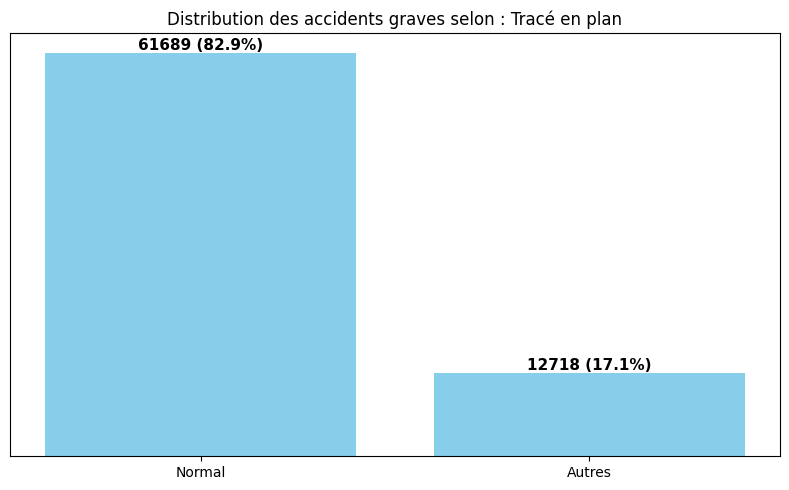

In [85]:
col = "plan"

# Filtrer uniquement les accidents graves
df_graves = df_final[df_final['gravite'] > 0]

# Comptage
lum_groups = {
    "Normal": df_graves[df_graves[col] == 1].shape[0],
    "Autres": df_graves[df_graves[col] == 2].shape[0]
}

# Total pour les pourcentages
total = sum(lum_groups.values())

# Création du graphique
plt.figure(figsize=(8, 5))
bars = plt.bar(lum_groups.keys(), lum_groups.values(), color='skyblue')

# Ajouter les valeurs et pourcentages au-dessus des barres
for bar in bars:
    height = bar.get_height()
    pourcent = (height / total) * 100 if total > 0 else 0
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        f"{int(height)} ({pourcent:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Supprimer l'axe Y
plt.gca().axes.get_yaxis().set_visible(False)

# Titres
plt.xlabel("")
plt.title(f"Distribution des accidents graves selon : {noms_colonnes[col]}")
plt.tight_layout()
plt.show()


### **Infrastructures 'infra'**

#### **Ré-encodage**

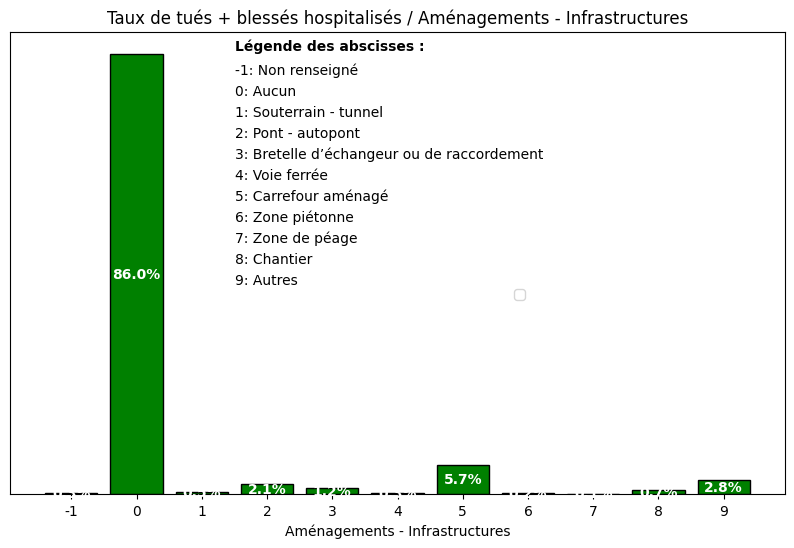

In [86]:
# Calcul basé uniquement sur la colonne 'gravite'
tue_bhos = df_final.groupby('infra')[['gravite']].sum()

# Calcul du taux de danger pour chaque catégorie
total = tue_bhos['gravite'].sum()
tue_bhos['Taux'] = tue_bhos['gravite'] / total * 100

# Création du graphique
plt.figure(figsize=(10, 6))
bars = plt.bar(tue_bhos.index.astype(str), tue_bhos['Taux'], color='green', edgecolor='black')

# Afficher les taux sur les barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,
             height / 2,
             f"{height:.1f}%",
             ha='center',
             va='center',
             fontsize=10,
             fontweight='bold',
             color='white')

# Titres et axes
plt.title("Taux de tués + blessés hospitalisés / Aménagements - Infrastructures")
plt.xlabel("Aménagements - Infrastructures")
plt.ylabel("Pourcentage")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.gca().axes.get_yaxis().set_visible(False)

# Légende
plt.legend(loc=(0.65, 0.42))  # x = 35%, y = 90% de la figure

# Légende explicative hors graphique
legende_plan = {
    -1: 'Non renseigné',
    0: 'Aucun',
    1: 'Souterrain - tunnel',
    2: 'Pont - autopont',
    3: 'Bretelle d’échangeur ou de raccordement',
    4: 'Voie ferrée',
    5: 'Carrefour aménagé',
    6: 'Zone piétonne',
    7: 'Zone de péage',
    8: 'Chantier',
    9: 'Autres',

}
plt.figtext(0.35, 0.85, "Légende des abscisses :", fontsize=10, fontweight='bold')
for i, (k, v) in enumerate(legende_plan.items()):
    plt.figtext(0.35, 0.81 - i * 0.035, f"{k}: {v}", fontsize=10)

plt.show()


In [87]:
df_final.drop(columns=['infra'], inplace=True)

### **Situation de l'accident 'situ'**

#### **Ré-encodage**

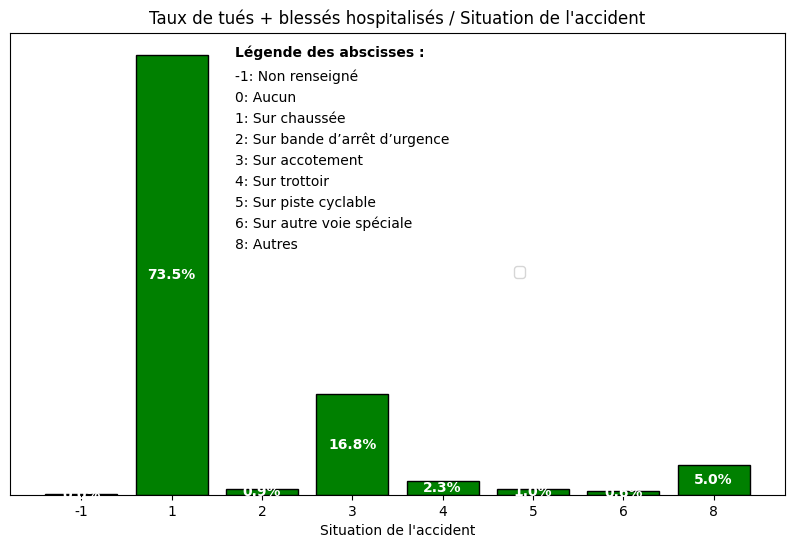

In [88]:
# Calcul basé uniquement sur la colonne 'gravite'
tue_bhos = df_final.groupby('situ')[['gravite']].sum()

# Calcul du taux de danger pour chaque catégorie
total = tue_bhos['gravite'].sum()
tue_bhos['Taux'] = tue_bhos['gravite'] / total * 100

# Création du graphique
plt.figure(figsize=(10, 6))
bars = plt.bar(tue_bhos.index.astype(str), tue_bhos['Taux'], color='green', edgecolor='black')

# Afficher les taux sur les barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,
             height / 2,
             f"{height:.1f}%",
             ha='center',
             va='center',
             fontsize=10,
             fontweight='bold',
             color='white')

# Titres et axes
plt.title("Taux de tués + blessés hospitalisés / Situation de l'accident")
plt.xlabel("Situation de l'accident")
plt.ylabel("Pourcentage")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.gca().axes.get_yaxis().set_visible(False)

# Légende
plt.legend(loc=(0.65, 0.47))  # x = 35%, y = 90% de la figure

# Légende explicative hors graphique
legende_plan = {
    -1: 'Non renseigné',
    0: 'Aucun',
    1: 'Sur chaussée',
    2: 'Sur bande d’arrêt d’urgence',
    3: 'Sur accotement',
    4: 'Sur trottoir',
    5: 'Sur piste cyclable',
    6: 'Sur autre voie spéciale',
    8: 'Autres',
}
plt.figtext(0.35, 0.84, "Légende des abscisses :", fontsize=10, fontweight='bold')
for i, (k, v) in enumerate(legende_plan.items()):
    plt.figtext(0.35, 0.80 - i * 0.035, f"{k}: {v}", fontsize=10)

plt.show()


In [89]:
# Libellés d'origine
libelles_originaux = {
    -1: 'Non renseigné',
    0: 'Aucun',
    1: 'Sur chaussée',
    2: 'Sur bande d’arrêt d’urgence',
    3: 'Sur accotement',
    4: 'Sur trottoir',
    5: 'Sur piste cyclable',
    6: 'Sur autre voie spéciale',
    8: 'Autres',
}


# Dictionnaire des regroupements (libellés)
regroupement = {
    -1: 'Autres',
    0: 'Autres',
    1: 'Sur chaussée',
    2: 'Autres',
    3: 'Sur accotement',
    4: 'Autres',
    5: 'Autres',
    6: 'Autres',
    8: 'Autres',
}

# Dictionnaire des codes numériques pour les nouvelles catégories
categorie = {
  'Sur chaussée': 1,
  'Sur accotement': 2,
  'Autres': 3,
}

# Tableau de correspondance indépendant de df_final
tableau_correspondance = pd.DataFrame([
    {
        "Code": code,
        "Ancienne catégorie": libelles_originaux[code],
        "Nouvelle catégorie": regroupement[code],
        "Code New": categorie[regroupement[code]]
    }
    for code in sorted(libelles_originaux.keys())
])

# Affichage avec rich
table = Table(title="Correspondance des SITUATIONS DE L'ACCIDENT")

table.add_column("Code", style="bold green")
table.add_column("Ancienne catégorie", style="bold green")
table.add_column("Nouvelle catégorie", style="bold magenta")
table.add_column("Code New", style="bold magenta")

for _, row in tableau_correspondance.iterrows():
    table.add_row(
        str(row["Code"]),
        str(row["Ancienne catégorie"]),
        str(row["Nouvelle catégorie"]),
        str(row["Code New"])
    )

console = Console()
console.print(table)

             Correspondance des SITUATIONS DE L'ACCIDENT              
┏━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Code ┃ Ancienne catégorie          ┃ Nouvelle catégorie ┃ Code New ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ -1   │ Non renseigné               │ Autres             │ 3        │
│ 0    │ Aucun                       │ Autres             │ 3        │
│ 1    │ Sur chaussée                │ Sur chaussée       │ 1        │
│ 2    │ Sur bande d’arrêt d’urgence │ Autres             │ 3        │
│ 3    │ Sur accotement              │ Sur accotement     │ 2        │
│ 4    │ Sur trottoir                │ Autres             │ 3        │
│ 5    │ Sur piste cyclable          │ Autres             │ 3        │
│ 6    │ Sur autre voie spéciale     │ Autres             │ 3        │
│ 8    │ Autres                      │ Autres             │ 3        │
└──────┴─────────────────────────────┴────────────────────┴──────────┘

In [90]:
df_final['situ'] = df_final['situ'].apply(lambda x: 2 if x == 3 else 3 if x in [-1, 0, 4, 5, 6, 8] else x)

#### **Distribution nouvelle**

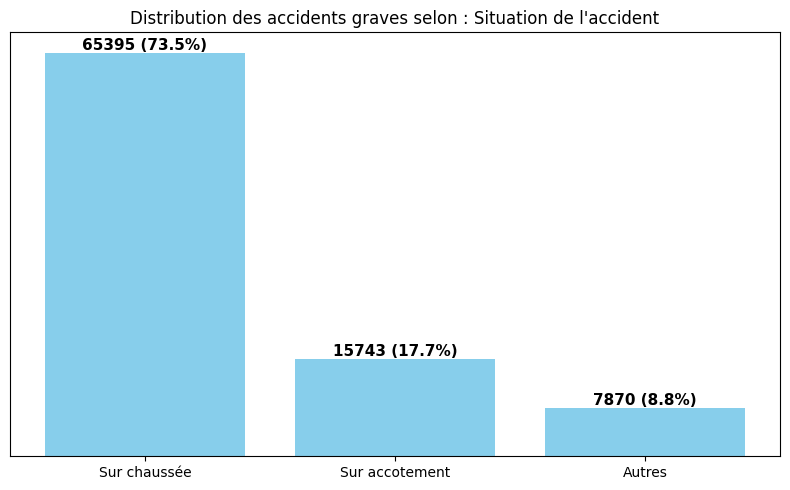

In [91]:
col = "situ"

# Filtrer uniquement les accidents graves
df_graves = df_final[df_final['gravite'] > 0]

# Comptage
lum_groups = {
    "Sur chaussée": df_graves[df_graves[col] == 1].shape[0],
    "Sur accotement": df_graves[df_graves[col] == 2].shape[0],
    "Autres": df_graves[df_graves[col] == 3].shape[0]
}

# Total pour les pourcentages
total = sum(lum_groups.values())

# Création du graphique
plt.figure(figsize=(8, 5))
bars = plt.bar(lum_groups.keys(), lum_groups.values(), color='skyblue')

# Ajouter les valeurs et pourcentages au-dessus des barres
for bar in bars:
    height = bar.get_height()
    pourcent = (height / total) * 100 if total > 0 else 0
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        f"{int(height)} ({pourcent:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Supprimer l'axe Y
plt.gca().axes.get_yaxis().set_visible(False)

# Titres
plt.xlabel("")
plt.title(f"Distribution des accidents graves selon : {noms_colonnes[col]}")
plt.tight_layout()
plt.show()


### **Voie réservée 'vosp'**

#### **Ré-encodage**

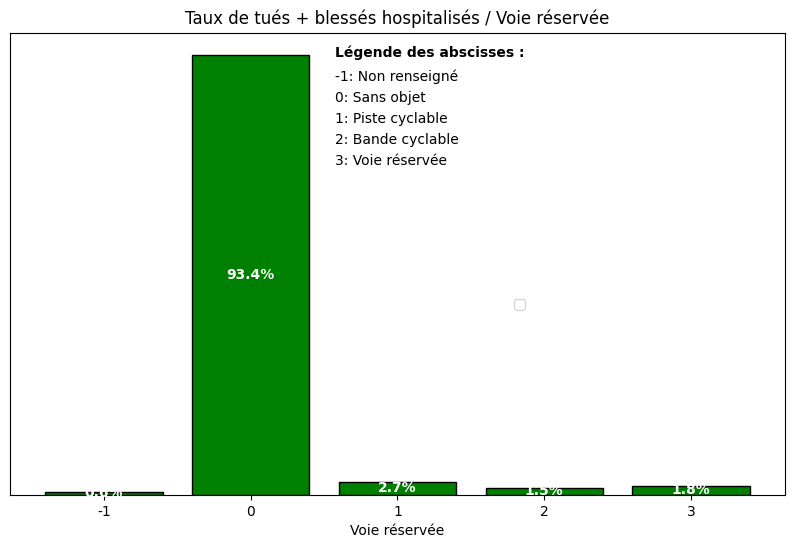

In [92]:
# Calcul basé uniquement sur la colonne 'gravite'
tue_bhos = df_final.groupby('vosp')[['gravite']].sum()

# Calcul du taux de danger pour chaque catégorie
total = tue_bhos['gravite'].sum()
tue_bhos['Taux'] = tue_bhos['gravite'] / total * 100

# Création du graphique
plt.figure(figsize=(10, 6))
bars = plt.bar(tue_bhos.index.astype(str), tue_bhos['Taux'], color='green', edgecolor='black')

# Afficher les taux sur les barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,
             height / 2,
             f"{height:.1f}%",
             ha='center',
             va='center',
             fontsize=10,
             fontweight='bold',
             color='white')

# Titres et axes
plt.title("Taux de tués + blessés hospitalisés / Voie réservée")
plt.xlabel("Voie réservée")
plt.ylabel("Pourcentage")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.gca().axes.get_yaxis().set_visible(False)

# Légende
plt.legend(loc=(0.65, 0.40))  # x = 35%, y = 90% de la figure

# Légende explicative hors graphique
legende_plan = {
    -1: 'Non renseigné',
    0: 'Sans objet',
    1: 'Piste cyclable',
    2: 'Bande cyclable',
    3: 'Voie réservée',
}

plt.figtext(0.45, 0.84, "Légende des abscisses :", fontsize=10, fontweight='bold')
for i, (k, v) in enumerate(legende_plan.items()):
    plt.figtext(0.45, 0.80 - i * 0.035, f"{k}: {v}", fontsize=10)

plt.show()


In [93]:
df_final.drop(columns=['vosp'], inplace=True)

### **Type de Collision 'col'**

#### **Ré-encodage**

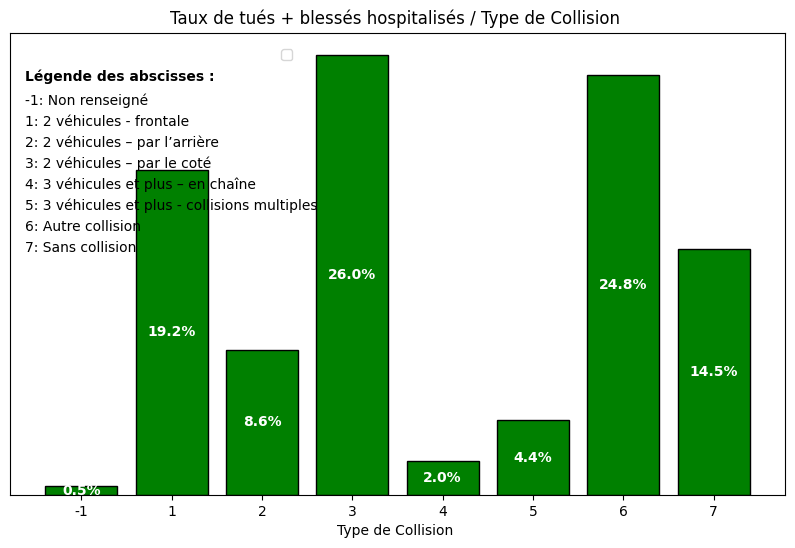

In [94]:
# Calcul basé uniquement sur la colonne 'gravite'
tue_bhos = df_final.groupby('col')[['gravite']].sum()

# Calcul du taux de danger pour chaque catégorie
total = tue_bhos['gravite'].sum()
tue_bhos['Taux'] = tue_bhos['gravite'] / total * 100

# Création du graphique
plt.figure(figsize=(10, 6))
bars = plt.bar(tue_bhos.index.astype(str), tue_bhos['Taux'], color='green', edgecolor='black')

# Afficher les taux sur les barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,
             height / 2,
             f"{height:.1f}%",
             ha='center',
             va='center',
             fontsize=10,
             fontweight='bold',
             color='white')

# Titres et axes
plt.title("Taux de tués + blessés hospitalisés / Type de Collision ")
plt.xlabel("Type de Collision ")
plt.ylabel("Pourcentage")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.gca().axes.get_yaxis().set_visible(False)

# Légende
plt.legend(loc=(0.35, 0.94))  # x = 35%, y = 90% de la figure

# Légende explicative hors graphique
legende_plan = {
    -1: 'Non renseigné',
    1: '2 véhicules - frontale',
    2: '2 véhicules – par l’arrière',
    3: '2 véhicules – par le coté',
    4: '3 véhicules et plus – en chaîne',
    5: '3 véhicules et plus - collisions multiples',
    6: 'Autre collision',
    7: 'Sans collision',

}

plt.figtext(0.14, 0.80, "Légende des abscisses :", fontsize=10, fontweight='bold')
for i, (k, v) in enumerate(legende_plan.items()):
    plt.figtext(0.14, 0.76 - i * 0.035, f"{k}: {v}", fontsize=10)

plt.show()


In [95]:
# Libellés d'origine
libelles_originaux = {
    -1: 'Non renseigné',
    1: '2 véhicules - frontale',
    2: '2 véhicules – par l’arrière',
    3: '2 véhicules – par le coté',
    4: '3 véhicules et plus – en chaîne',
    5: '3 véhicules et plus - collisions multiples',
    6: 'Autre collision',
    7: 'Sans collision',

}


# Dictionnaire des regroupements (libellés)
regroupement = {
    -1: 'Autres',
    1: 'Frontale',
    2: 'Arrière',
    3: 'Coté',
    4: 'Autres',
    5: 'Autres',
    6: 'Autres',
    7: 'Autres',

}

# Dictionnaire des codes numériques pour les nouvelles catégories
categorie = {
  'Frontale': 1,
  'Arrière': 2,
  'Coté': 3,
  'Autres': 4,
}

# Tableau de correspondance indépendant de df_final
tableau_correspondance = pd.DataFrame([
    {
        "Code": code,
        "Ancienne catégorie": libelles_originaux[code],
        "Nouvelle catégorie": regroupement[code],
        "Code New": categorie[regroupement[code]]
    }
    for code in sorted(libelles_originaux.keys())
])

# Affichage avec rich
table = Table(title="Correspondance des SITUATIONS DE L'ACCIDENT")

table.add_column("Code", style="bold green")
table.add_column("Ancienne catégorie", style="bold green")
table.add_column("Nouvelle catégorie", style="bold magenta")
table.add_column("Code New", style="bold magenta")

for _, row in tableau_correspondance.iterrows():
    table.add_row(
        str(row["Code"]),
        str(row["Ancienne catégorie"]),
        str(row["Nouvelle catégorie"]),
        str(row["Code New"])
    )

console = Console()
console.print(table)

                     Correspondance des SITUATIONS DE L'ACCIDENT                     
┏━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Code ┃ Ancienne catégorie                         ┃ Nouvelle catégorie ┃ Code New ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ -1   │ Non renseigné                              │ Autres             │ 4        │
│ 1    │ 2 véhicules - frontale                     │ Frontale           │ 1        │
│ 2    │ 2 véhicules – par l’arrière                │ Arrière            │ 2        │
│ 3    │ 2 véhicules – par le coté                  │ Coté               │ 3        │
│ 4    │ 3 véhicules et plus – en chaîne            │ Autres             │ 4        │
│ 5    │ 3 véhicules et plus - collisions multiples │ Autres             │ 4        │
│ 6    │ Autre collision                            │ Autres             │ 4        │
│ 7    │ Sans collision                             │ Autres             │ 4        │
└──────┴────────────────────────────────────────────┴────────────────────┴──────────┘

In [96]:
df_final['col'] = df_final['col'].apply(lambda x: 4 if x in [-1, 5, 6, 7] else x)

#### **Distribution nouvelle**

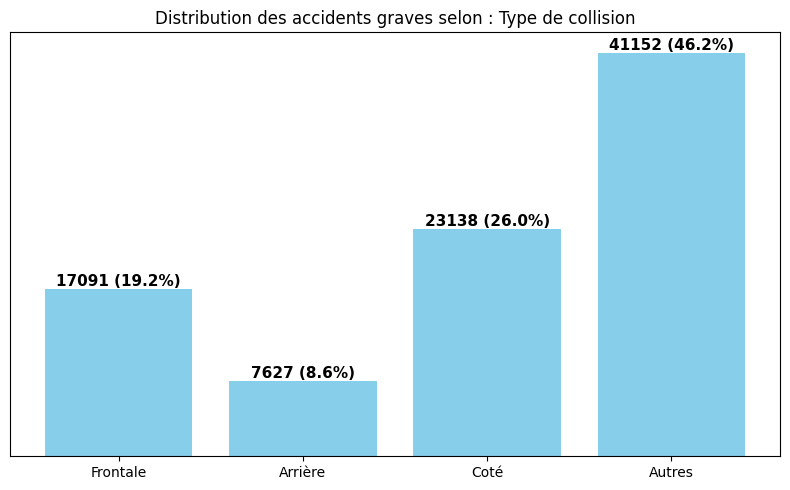

In [97]:
col = "col"

# Filtrer uniquement les accidents graves
df_graves = df_final[df_final['gravite'] > 0]

# Comptage
lum_groups = {
    "Frontale": df_graves[df_graves[col] == 1].shape[0],
    "Arrière": df_graves[df_graves[col] == 2].shape[0],
    "Coté": df_graves[df_graves[col] == 3].shape[0],
    "Autres": df_graves[df_graves[col] == 4].shape[0]
}

# Total pour les pourcentages
total = sum(lum_groups.values())

# Création du graphique
plt.figure(figsize=(8, 5))
bars = plt.bar(lum_groups.keys(), lum_groups.values(), color='skyblue')

# Ajouter les valeurs et pourcentages au-dessus des barres
for bar in bars:
    height = bar.get_height()
    pourcent = (height / total) * 100 if total > 0 else 0
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        f"{int(height)} ({pourcent:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Supprimer l'axe Y
plt.gca().axes.get_yaxis().set_visible(False)

# Titres
plt.xlabel("")
plt.title(f"Distribution des accidents graves selon : {noms_colonnes[col]}")
plt.tight_layout()
plt.show()


### **Localisation 'agg'**

#### **Ré-encodage**

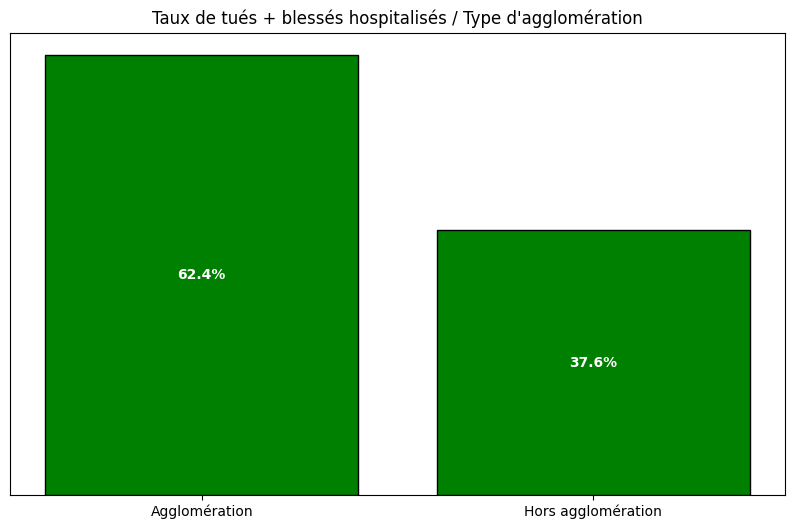

In [98]:
# Calcul basé uniquement sur la colonne 'gravite'
tue_bhos = df_final.groupby('agg')[['gravite']].sum()

# Calcul du taux de danger pour chaque catégorie
total = tue_bhos['gravite'].sum()
tue_bhos['Taux'] = tue_bhos['gravite'] / total * 100

# Dictionnaire de libellés personnalisés pour 'agg'
libelles_agg = {
    1: 'Agglomération',
    2: 'Hors agglomération'
}

# Création du graphique
plt.figure(figsize=(10, 6))
bars = plt.bar(tue_bhos.index.astype(str), tue_bhos['Taux'], color='green', edgecolor='black')

# Appliquer les libellés personnalisés sur l’axe X
plt.xticks(
    ticks=range(len(tue_bhos.index)),
    labels=[libelles_agg.get(val, str(val)) for val in tue_bhos.index],
    rotation=0
)

# Afficher les taux sur les barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,
             height / 2,
             f"{height:.1f}%",
             ha='center',
             va='center',
             fontsize=10,
             fontweight='bold',
             color='white')

# Titres et axes
plt.title("Taux de tués + blessés hospitalisés / Type d'agglomération")
plt.xlabel("")
plt.ylabel("Pourcentage")
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.gca().axes.get_yaxis().set_visible(False)

plt.show()


In [99]:
# df_final.drop(columns=['agg'], inplace=True)

#### **Distribution nouvelle**

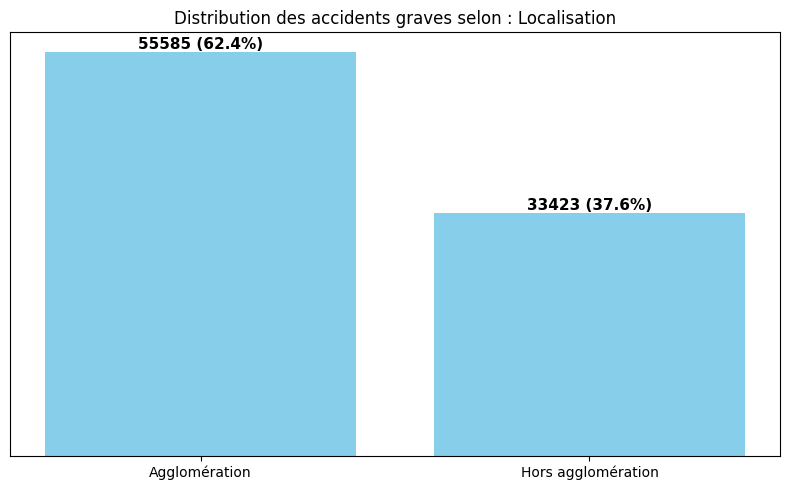

In [100]:
col = "agg"

# Filtrer uniquement les accidents graves
df_graves = df_final[df_final['gravite'] > 0]

# Comptage
lum_groups = {
    "Agglomération": df_graves[df_graves[col] == 1].shape[0],
    "Hors agglomération": df_graves[df_graves[col] == 2].shape[0]
}

# Total pour les pourcentages
total = sum(lum_groups.values())

# Création du graphique
plt.figure(figsize=(8, 5))
bars = plt.bar(lum_groups.keys(), lum_groups.values(), color='skyblue')

# Ajouter les valeurs et pourcentages au-dessus des barres
for bar in bars:
    height = bar.get_height()
    pourcent = (height / total) * 100 if total > 0 else 0
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        f"{int(height)} ({pourcent:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Supprimer l'axe Y
plt.gca().axes.get_yaxis().set_visible(False)

# Titres
plt.xlabel("")
plt.title(f"Distribution des accidents graves selon : {noms_colonnes[col]}")
plt.tight_layout()
plt.show()


### **Profilé de la route 'prof'**

#### **Ré-encodage**

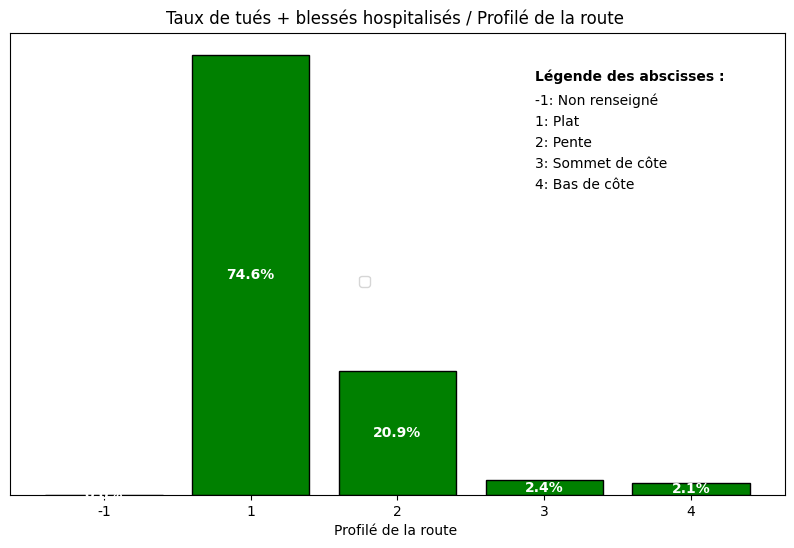

In [101]:
# Calcul basé uniquement sur la colonne 'gravite'
tue_bhos = df_final.groupby('prof')[['gravite']].sum()

# Calcul du taux de danger pour chaque catégorie
total = tue_bhos['gravite'].sum()
tue_bhos['Taux'] = tue_bhos['gravite'] / total * 100

# Création du graphique
plt.figure(figsize=(10, 6))
bars = plt.bar(tue_bhos.index.astype(str), tue_bhos['Taux'], color='green', edgecolor='black')

# Afficher les taux sur les barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,
             height / 2,
             f"{height:.1f}%",
             ha='center',
             va='center',
             fontsize=10,
             fontweight='bold',
             color='white')

# Titres et axes
plt.title("Taux de tués + blessés hospitalisés / Profilé de la route ")
plt.xlabel("Profilé de la route ")
plt.ylabel("Pourcentage")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.gca().axes.get_yaxis().set_visible(False)

# Légende
plt.legend(loc=(0.45, 0.45))  # x = 35%, y = 90% de la figure

# Légende explicative hors graphique
legende_plan = {
    -1: 'Non renseigné',
    1: 'Plat',
    2: 'Pente',
    3: 'Sommet de côte',
    4: 'Bas de côte',

}

plt.figtext(0.65, 0.80, "Légende des abscisses :", fontsize=10, fontweight='bold')
for i, (k, v) in enumerate(legende_plan.items()):
    plt.figtext(0.65, 0.76 - i * 0.035, f"{k}: {v}", fontsize=10)

plt.show()


In [102]:
# Libellés d'origine
libelles_originaux = {
    -1: 'Non renseigné',
    1: 'Plat',
    2: 'Pente',
    3: 'Sommet de côte',
    4: 'Bas de côte',
}


# Dictionnaire des regroupements (libellés)
regroupement = {
    -1: 'Autres',
    1: 'Plat',
    2: 'Pente',
    3: 'Autres',
    4: 'Autres',
}

# Dictionnaire des codes numériques pour les nouvelles catégories
categorie = {
  'Plat': 1,
  'Pente': 2,
  'Autres': 3,
}

# Tableau de correspondance indépendant de df_final
tableau_correspondance = pd.DataFrame([
    {
        "Code": code,
        "Ancienne catégorie": libelles_originaux[code],
        "Nouvelle catégorie": regroupement[code],
        "Code New": categorie[regroupement[code]]
    }
    for code in sorted(libelles_originaux.keys())
])

# Affichage avec rich
table = Table(title="Correspondance des SITUATIONS DE L'ACCIDENT")

table.add_column("Code", style="bold green")
table.add_column("Ancienne catégorie", style="bold green")
table.add_column("Nouvelle catégorie", style="bold magenta")
table.add_column("Code New", style="bold magenta")

for _, row in tableau_correspondance.iterrows():
    table.add_row(
        str(row["Code"]),
        str(row["Ancienne catégorie"]),
        str(row["Nouvelle catégorie"]),
        str(row["Code New"])
    )

console = Console()
console.print(table)

         Correspondance des SITUATIONS DE L'ACCIDENT         
┏━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Code ┃ Ancienne catégorie ┃ Nouvelle catégorie ┃ Code New ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ -1   │ Non renseigné      │ Autres             │ 3        │
│ 1    │ Plat               │ Plat               │ 1        │
│ 2    │ Pente              │ Pente              │ 2        │
│ 3    │ Sommet de côte     │ Autres             │ 3        │
│ 4    │ Bas de côte        │ Autres             │ 3        │
└──────┴────────────────────┴────────────────────┴──────────┘

In [103]:
df_final['prof'] = df_final['prof'].apply(lambda x: 3 if x in [-1, 4] else x)

#### **Distribution nouvelle**

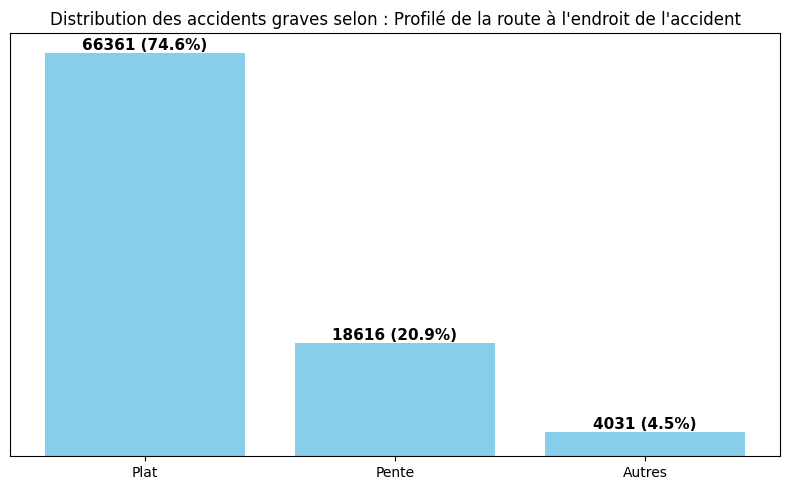

In [104]:
col = "prof"

# Filtrer uniquement les accidents graves
df_graves = df_final[df_final['gravite'] > 0]

# Comptage
lum_groups = {
    "Plat": df_graves[df_graves[col] == 1].shape[0],
    "Pente": df_graves[df_graves[col] == 2].shape[0],
    "Autres": df_graves[df_graves[col] == 3].shape[0]
}

# Total pour les pourcentages
total = sum(lum_groups.values())

# Création du graphique
plt.figure(figsize=(8, 5))
bars = plt.bar(lum_groups.keys(), lum_groups.values(), color='skyblue')

# Ajouter les valeurs et pourcentages au-dessus des barres
for bar in bars:
    height = bar.get_height()
    pourcent = (height / total) * 100 if total > 0 else 0
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        f"{int(height)} ({pourcent:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Supprimer l'axe Y
plt.gca().axes.get_yaxis().set_visible(False)

# Titres
plt.xlabel("")
plt.title(f"Distribution des accidents graves selon : {noms_colonnes[col]}")
plt.tight_layout()
plt.show()


### **Obstacle fixe heurté 'obs'**

#### **Ré-encodage**

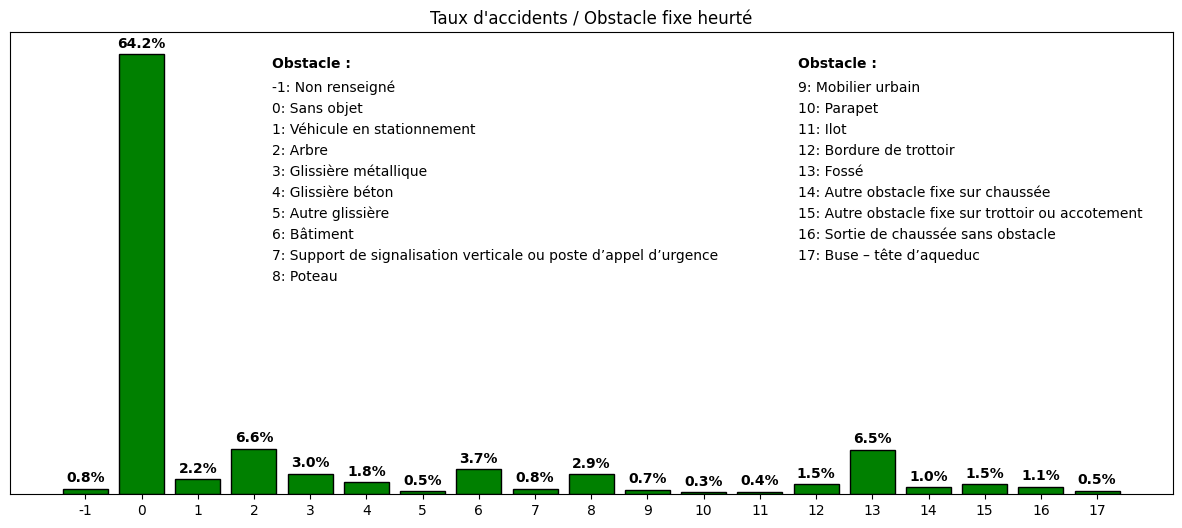

In [105]:
# Calcul basé uniquement sur la colonne 'gravite'
tue_bhos = df_final.groupby('obs')[['gravite']].sum()

# Calcul du taux de danger pour chaque catégorie
total = tue_bhos['gravite'].sum()
tue_bhos['Taux'] = tue_bhos['gravite'] / total * 100

# Création du graphique
plt.figure(figsize=(15, 6))
bars = plt.bar(tue_bhos.index.astype(str), tue_bhos['Taux'], color='green', edgecolor='black')

# Affichage du pourcentage uniquement
for bar, taux in zip(bars, tue_bhos['Taux']):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,
             height + 0.5,
             f"{taux:.1f}%",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Légendes personnalisées (ajout en dehors du graphique)
legende_obs1 = {
    -1: 'Non renseigné',
    0: 'Sans objet',
    1 : 'Véhicule en stationnement',
    2 : 'Arbre',
    3 : 'Glissière métallique',
    4 : 'Glissière béton',
    5 : 'Autre glissière',
    6 : 'Bâtiment',
    7 : 'Support de signalisation verticale ou poste d’appel d’urgence',
    8 : 'Poteau',
}
plt.figtext(0.3, 0.82, "Obstacle :", fontsize=10, fontweight='bold')
for i, (k, v) in enumerate(legende_obs1.items()):
    plt.figtext(0.3, 0.78 - i * 0.035, f"{k}: {v}", fontsize=10)

# Légendes personnalisées (ajout en dehors du graphique)
legende_obs2 = {
    9 : 'Mobilier urbain',
    10: 'Parapet',
    11: 'Ilot',
    12: 'Bordure de trottoir',
    13: 'Fossé',
    14: 'Autre obstacle fixe sur chaussée',
    15: 'Autre obstacle fixe sur trottoir ou accotement',
    16: 'Sortie de chaussée sans obstacle',
    17: 'Buse – tête d’aqueduc',
}
plt.figtext(0.65, 0.82, "Obstacle :", fontsize=10, fontweight='bold')
for i, (k, v) in enumerate(legende_obs2.items()):
    plt.figtext(0.65, 0.78 - i * 0.035, f"{k}: {v}", fontsize=10)


# Titres et axes
plt.title("Taux d'accidents / Obstacle fixe heurté")
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.gca().axes.get_yaxis().set_visible(False)

plt.show()


In [106]:
# Libellés d'origine
libelles_originaux = {
    -1: 'Non renseigné',
    0: 'Sans objet',
    1 : 'Véhicule en stationnement',
    2 : 'Arbre',
    3 : 'Glissière métallique',
    4 : 'Glissière béton',
    5 : 'Autre glissière',
    6 : 'Bâtiment',
    7 : 'Support de signalisation verticale ou poste d’appel d’urgence',
    8 : 'Poteau',
    9 : 'Mobilier urbain',
    10: 'Parapet',
    11: 'Ilot',
    12: 'Bordure de trottoir',
    13: 'Fossé',
    14: 'Autre obstacle fixe sur chaussée',
    15: 'Autre obstacle fixe sur trottoir ou accotement',
    16: 'Sortie de chaussée sans obstacle',
    17: 'Buse – tête d’aqueduc',
}


# Dictionnaire des regroupements (libellés)
regroupement = {
   -1:  'Aucun',
    0:  'Aucun',
    1 : 'Autres',
    2 : 'Arbre et fossé',
    3 : 'Autres',
    4 : 'Autres',
    5 : 'Autres',
    6 : 'Autres',
    7 : 'Autres',
    8 : 'Autres',
    9 : 'Autres',
    10: 'Autres',
    11: 'Autres',
    12: 'Autres',
    13: 'Arbre et fossé',
    14: 'Autres',
    15: 'Autres',
    16: 'Autres',
    17: 'Autres',
}

# Dictionnaire des codes numériques pour les nouvelles catégories
categorie = {
  'Aucun': 1,
  'Arbre et fossé': 2,
  'Autres': 3,
}

# Tableau de correspondance indépendant de df_final
tableau_correspondance = pd.DataFrame([
    {
        "Code": code,
        "Ancienne catégorie": libelles_originaux[code],
        "Nouvelle catégorie": regroupement[code],
        "Code New": categorie[regroupement[code]]
    }
    for code in sorted(libelles_originaux.keys())
])

# Affichage avec rich
table = Table(title="Correspondance des SITUATIONS DE L'ACCIDENT")

table.add_column("Code", style="bold green")
table.add_column("Ancienne catégorie", style="bold green")
table.add_column("Nouvelle catégorie", style="bold magenta")
table.add_column("Code New", style="bold magenta")

for _, row in tableau_correspondance.iterrows():
    table.add_row(
        str(row["Code"]),
        str(row["Ancienne catégorie"]),
        str(row["Nouvelle catégorie"]),
        str(row["Code New"])
    )

console = Console()
console.print(table)

                              Correspondance des SITUATIONS DE L'ACCIDENT                               
┏━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Code ┃ Ancienne catégorie                                            ┃ Nouvelle catégorie ┃ Code New ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ -1   │ Non renseigné                                                 │ Aucun              │ 1        │
│ 0    │ Sans objet                                                    │ Aucun              │ 1        │
│ 1    │ Véhicule en stationnement                                     │ Autres             │ 3        │
│ 2    │ Arbre                                                         │ Arbre et fossé     │ 2        │
│ 3    │ Glissière métallique                                          │ Autres             │ 3        │
│ 4    │ Glissière béton                                               │ Autres             │ 3        │
│ 5    │ Autre glissière                                               │ Autres             │ 3        │
│ 6    │ Bâtiment                                                      │ Autres             │ 3        │
│ 7    │ Support de signalisation verticale ou poste d’appel d’urgence │ Autres             │ 3        │
│ 8    │ Poteau                                                        │ Autres             │ 3        │
│ 9    │ Mobilier urbain                                               │ Autres             │ 3        │
│ 10   │ Parapet                                                       │ Autres             │ 3        │
│ 11   │ Ilot                                                          │ Autres             │ 3        │
│ 12   │ Bordure de trottoir                                           │ Autres             │ 3        │
│ 13   │ Fossé                                                         │ Arbre et fossé     │ 2        │
│ 14   │ Autre obstacle fixe sur chaussée                              │ Autres             │ 3        │
│ 15   │ Autre obstacle fixe sur trottoir ou accotement                │ Autres             │ 3        │
│ 16   │ Sortie de chaussée sans obstacle                              │ Autres             │ 3        │
│ 17   │ Buse – tête d’aqueduc                                         │ Autres             │ 3        │
└──────┴───────────────────────────────────────────────────────────────┴────────────────────┴──────────┘

In [107]:
df_final['obs'] = df_final['obs'].apply(lambda x: 1 if x in [-1, 0] else 2 if x in [2, 13] else 3)

#### **Distribution nouvelle**

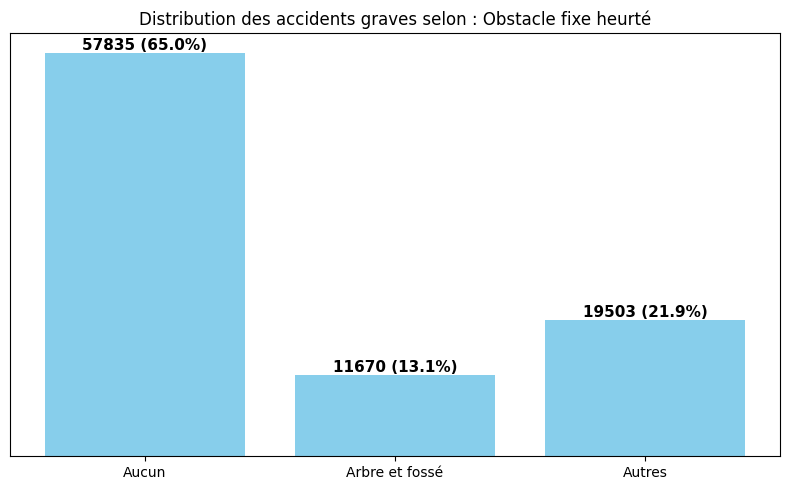

In [108]:
col = "obs"

# Filtrer uniquement les accidents graves
df_graves = df_final[df_final['gravite'] > 0]

# Comptage
lum_groups = {
    "Aucun": df_graves[df_graves[col] == 1].shape[0],
    "Arbre et fossé": df_graves[df_graves[col] == 2].shape[0],
    "Autres": df_graves[df_graves[col] == 3].shape[0]
}

# Total pour les pourcentages
total = sum(lum_groups.values())

# Création du graphique
plt.figure(figsize=(8, 5))
bars = plt.bar(lum_groups.keys(), lum_groups.values(), color='skyblue')

# Ajouter les valeurs et pourcentages au-dessus des barres
for bar in bars:
    height = bar.get_height()
    pourcent = (height / total) * 100 if total > 0 else 0
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        f"{int(height)} ({pourcent:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Supprimer l'axe Y
plt.gca().axes.get_yaxis().set_visible(False)

# Titres
plt.xlabel("")
plt.title(f"Distribution des accidents graves selon : {noms_colonnes[col]}")
plt.tight_layout()
plt.show()


### **Obstacle mobile heurté 'obsm'**

#### **Ré-encodage**

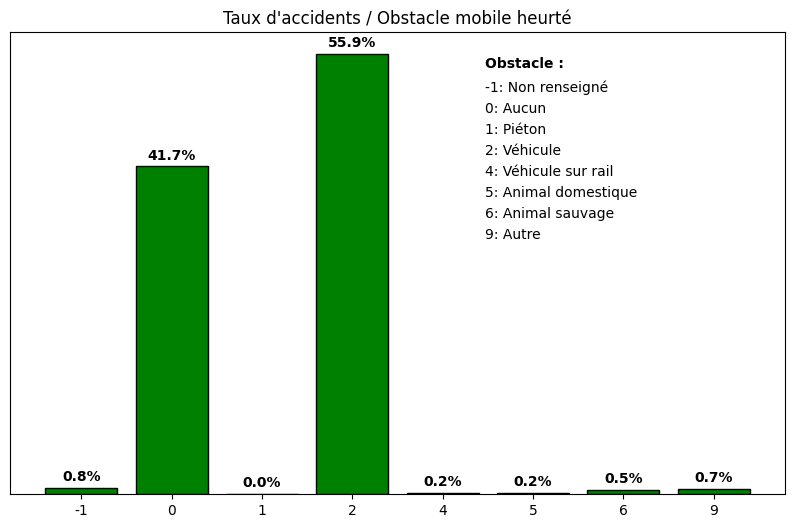

In [109]:
# Calcul basé uniquement sur la colonne 'gravite'
tue_bhos = df_final.groupby('obsm')[['gravite']].sum()

# Calcul du taux de danger pour chaque catégorie
total = tue_bhos['gravite'].sum()
tue_bhos['Taux'] = tue_bhos['gravite'] / total * 100

# Création du graphique
plt.figure(figsize=(10, 6))
bars = plt.bar(tue_bhos.index.astype(str), tue_bhos['Taux'], color='green', edgecolor='black')

# Affichage du pourcentage uniquement
for bar, taux in zip(bars, tue_bhos['Taux']):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,
             height + 0.5,
             f"{taux:.1f}%",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Légendes personnalisées (ajout en dehors du graphique)
legende_obs3 = {
    -1: 'Non renseigné',
    0: 'Aucun',
    1: 'Piéton',
    2: 'Véhicule',
    4: 'Véhicule sur rail',
    5: 'Animal domestique',
    6: 'Animal sauvage',
    9: 'Autre',

}
plt.figtext(0.6, 0.82, "Obstacle :", fontsize=10, fontweight='bold')
for i, (k, v) in enumerate(legende_obs3.items()):
    plt.figtext(0.6, 0.78 - i * 0.035, f"{k}: {v}", fontsize=10)

# Titres et axes
plt.title("Taux d'accidents / Obstacle mobile heurté")
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.gca().axes.get_yaxis().set_visible(False)

plt.show()


In [110]:
# Libellés d'origine
libelles_originaux = {
    -1: 'Non renseigné',
    0: 'Aucun',
    1: 'Piéton',
    2: 'Véhicule',
    4: 'Véhicule sur rail',
    5: 'Animal domestique',
    6: 'Animal sauvage',
    9: 'Autre',
}


# Dictionnaire des regroupements (libellés)
regroupement = {
    -1: 'Autres',
    0: 'Aucun',
    1: 'Piéton',
    2: 'Véhicule',
    4: 'Autres',
    5: 'Autres',
    6: 'Autres',
    9: 'Autres',
}

# Dictionnaire des codes numériques pour les nouvelles catégories
categorie = {
  'Piéton': 1,
  'Véhicule': 2,
  'Aucun': 3,
  'Autres': 4,
}

# Tableau de correspondance indépendant de df_final
tableau_correspondance = pd.DataFrame([
    {
        "Code": code,
        "Ancienne catégorie": libelles_originaux[code],
        "Nouvelle catégorie": regroupement[code],
        "Code New": categorie[regroupement[code]]
    }
    for code in sorted(libelles_originaux.keys())
])

# Affichage avec rich
table = Table(title="Correspondance des SITUATIONS DE L'ACCIDENT")

table.add_column("Code", style="bold green")
table.add_column("Ancienne catégorie", style="bold green")
table.add_column("Nouvelle catégorie", style="bold magenta")
table.add_column("Code New", style="bold magenta")

for _, row in tableau_correspondance.iterrows():
    table.add_row(
        str(row["Code"]),
        str(row["Ancienne catégorie"]),
        str(row["Nouvelle catégorie"]),
        str(row["Code New"])
    )

console = Console()
console.print(table)

         Correspondance des SITUATIONS DE L'ACCIDENT         
┏━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Code ┃ Ancienne catégorie ┃ Nouvelle catégorie ┃ Code New ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ -1   │ Non renseigné      │ Autres             │ 4        │
│ 0    │ Aucun              │ Aucun              │ 3        │
│ 1    │ Piéton             │ Piéton             │ 1        │
│ 2    │ Véhicule           │ Véhicule           │ 2        │
│ 4    │ Véhicule sur rail  │ Autres             │ 4        │
│ 5    │ Animal domestique  │ Autres             │ 4        │
│ 6    │ Animal sauvage     │ Autres             │ 4        │
│ 9    │ Autre              │ Autres             │ 4        │
└──────┴────────────────────┴────────────────────┴──────────┘

In [111]:
df_final['obsm'] = df_final['obsm'].apply(lambda x: 3 if x == 0 else 2 if x in [-1, 4, 5, 6, 9] else x)
df_final['obsm'] = df_final['obsm'].astype(int)

#### **Distribution nouvelle**

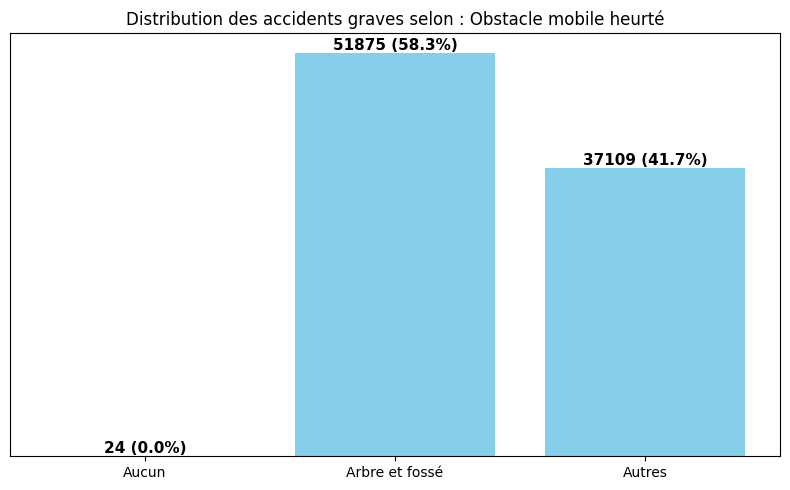

In [112]:
col = "obsm"

# Filtrer uniquement les accidents graves
df_graves = df_final[df_final['gravite'] > 0]

# Comptage
lum_groups = {
    "Aucun": df_graves[df_graves[col] == 1].shape[0],
    "Arbre et fossé": df_graves[df_graves[col] == 2].shape[0],
    "Autres": df_graves[df_graves[col] == 3].shape[0]
}

# Total pour les pourcentages
total = sum(lum_groups.values())

# Création du graphique
plt.figure(figsize=(8, 5))
bars = plt.bar(lum_groups.keys(), lum_groups.values(), color='skyblue')

# Ajouter les valeurs et pourcentages au-dessus des barres
for bar in bars:
    height = bar.get_height()
    pourcent = (height / total) * 100 if total > 0 else 0
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        f"{int(height)} ({pourcent:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Supprimer l'axe Y
plt.gca().axes.get_yaxis().set_visible(False)

# Titres
plt.xlabel("")
plt.title(f"Distribution des accidents graves selon : {noms_colonnes[col]}")
plt.tight_layout()
plt.show()


### **Largeur de la chaussée 'larrout'**

In [113]:
col = 'larrout'  # Nom de la colonne à analyser

print(f"--- Analyse de la colonne : '{col}' ---")
print(f"Type de données : {df_final[col].dtype}")
print(f"Nombre total de valeurs : {df_final[col].shape[0]}")
print(f"Nombre de valeurs non nulles : {df_final[col].notna().sum()}")
print(f"Nombre de valeurs nulles : {df_final[col].isna().sum()}")
print(f"Nombre de valeurs uniques : {df_final[col].nunique()}")
print(f"Valeurs uniques : {df_final[col].unique()}")
print("\n--- Répartition des valeurs (value_counts) ---")
print(df_final[col].value_counts().sort_index())
print("\n--- Statistiques descriptives ---")
print(df_final[col].describe())


--- Analyse de la colonne : 'larrout' ---
Type de données : int64
Nombre total de valeurs : 494927
Nombre de valeurs non nulles : 494927
Nombre de valeurs nulles : 0
Nombre de valeurs uniques : 78
Valeurs uniques : [  0  65   7   6   5   4 140  68  49  55  70  58  64  14  80  90  57 180
  54 105  78 110  47   9  10  56  48 145  42 100  60 155  63  75  50 175
  40  16  73  62  82  53  29  36  86  67  74   3  59  76   8  46  96  72
  37  34  97  20   2 113  45  95 275 700  11 170 730  -1  12  21  17  24
  18  15  13  19  30   1]

--- Répartition des valeurs (value_counts) ---
larrout
-1      335684
 0      121339
 1           4
 2          11
 3        2380
         ...  
 175         2
 180         2
 275         2
 700         3
 730         3
Name: count, Length: 78, dtype: int64

--- Statistiques descriptives ---
count    494927.000000
mean         -0.099330
std           4.096602
min          -1.000000
25%          -1.000000
50%          -1.000000
75%           0.000000
max         

In [114]:
df_final.drop(columns=['larrout'], inplace=True)

### **Sexe 'sexe''**

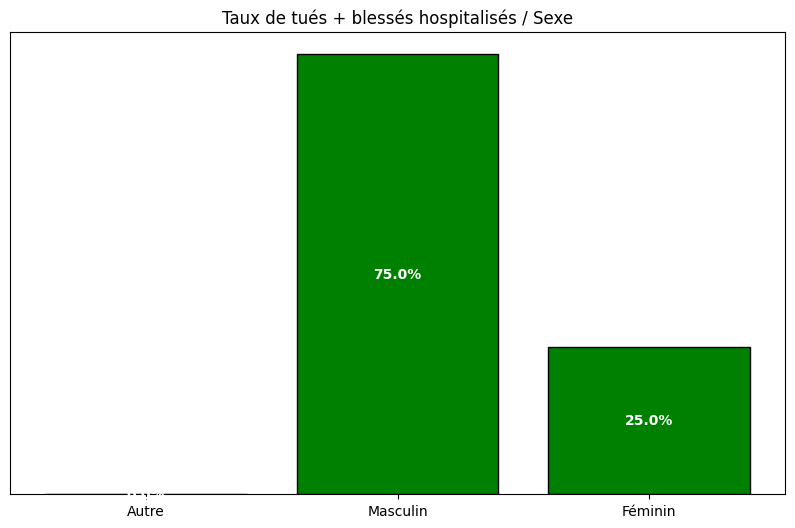

In [115]:
# Calcul basé uniquement sur la colonne 'gravite'
tue_bhos = df_final.groupby('sexe')[['gravite']].sum()

# Calcul du taux de danger pour chaque catégorie
total = tue_bhos['gravite'].sum()
tue_bhos['Taux'] = tue_bhos['gravite'] / total * 100

# Dictionnaire de libellés personnalisés pour 'agg'
libelles_agg = {
   -1: 'Autre',
    1: 'Masculin',
    2: 'Féminin'
}

# Création du graphique
plt.figure(figsize=(10, 6))
bars = plt.bar(tue_bhos.index.astype(str), tue_bhos['Taux'], color='green', edgecolor='black')

# Appliquer les libellés personnalisés sur l’axe X
plt.xticks(
    ticks=range(len(tue_bhos.index)),
    labels=[libelles_agg.get(val, str(val)) for val in tue_bhos.index],
    rotation=0
)

# Afficher les taux sur les barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,
             height / 2,
             f"{height:.1f}%",
             ha='center',
             va='center',
             fontsize=10,
             fontweight='bold',
             color='white')

# Titres et axes
plt.title("Taux de tués + blessés hospitalisés / Sexe")
plt.xlabel("")
plt.ylabel("Pourcentage")
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.gca().axes.get_yaxis().set_visible(False)

plt.show()


### **Catégorie d'usager 'catu'**

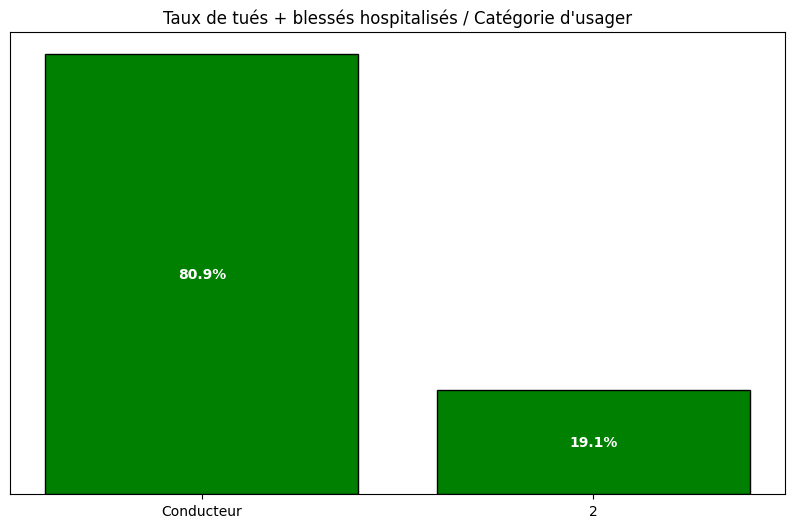

In [116]:
# Calcul basé uniquement sur la colonne 'gravite'
tue_bhos = df_final.groupby('catu')[['gravite']].sum()

# Calcul du taux de danger pour chaque catégorie
total = tue_bhos['gravite'].sum()
tue_bhos['Taux'] = tue_bhos['gravite'] / total * 100

# Dictionnaire de libellés personnalisés pour 'agg'
libelles_agg = {
    1: 'Conducteur',
    3: 'Piéton'
}

# Création du graphique
plt.figure(figsize=(10, 6))
bars = plt.bar(tue_bhos.index.astype(str), tue_bhos['Taux'], color='green', edgecolor='black')

# Appliquer les libellés personnalisés sur l’axe X
plt.xticks(
    ticks=range(len(tue_bhos.index)),
    labels=[libelles_agg.get(val, str(val)) for val in tue_bhos.index],
    rotation=0
)

# Afficher les taux sur les barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,
             height / 2,
             f"{height:.1f}%",
             ha='center',
             va='center',
             fontsize=10,
             fontweight='bold',
             color='white')

# Titres et axes
plt.title("Taux de tués + blessés hospitalisés / Catégorie d'usager")
plt.xlabel("")
plt.ylabel("Pourcentage")
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.gca().axes.get_yaxis().set_visible(False)

plt.show()


### **Synthèse des Modifications de df_final**

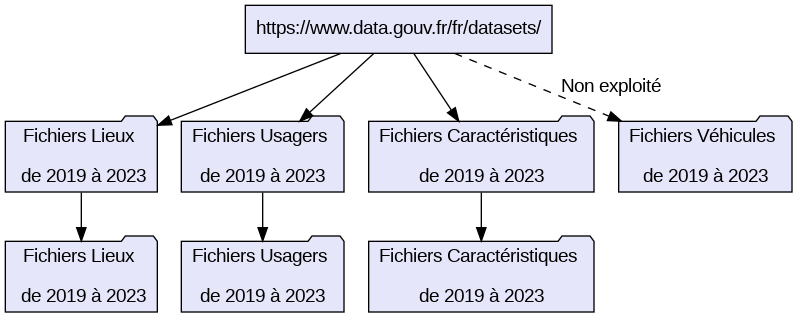

In [117]:
from graphviz import Digraph
from IPython.display import Image

dot = Digraph()

# Style des nœuds
dot.attr('node', style='filled', fillcolor='lavender')

# Nœud de départ
dot.node('start', 'https://www.data.gouv.fr/fr/datasets/', shape='box', fillcolor='lavender', fontname='Helvetica')

# Bloc principal
dot.node('A', 'Fichiers Lieux \n \n de 2019 à 2023', shape='folder', fontname='Helvetica')
dot.node('B', 'Fichiers Usagers \n \nde 2019 à 2023', shape='folder', fontname='Helvetica')
dot.node('C', 'Fichiers Caractéristiques \n \nde 2019 à 2023', shape='folder', fontname='Helvetica')
dot.node('D', 'Fichiers Véhicules \n \nde 2019 à 2023', shape='folder', fontname='Helvetica')

# Connexions = > 1
dot.edge('start', 'A', label='')
dot.edge('start', 'B', label='')
dot.edge('start', 'C', label='')
dot.edge('start', 'D', style='dashed', fontname='Helvetica', label='Non exploité')

# Bloc 1
dot.node('A1', 'Fichiers Lieux \n \n de 2019 à 2023', shape='folder', fontname='Helvetica')
dot.node('B1', 'Fichiers Usagers \n \nde 2019 à 2023', shape='folder', fontname='Helvetica')
dot.node('C1', 'Fichiers Caractéristiques \n \nde 2019 à 2023', shape='folder', fontname='Helvetica')

# Connexions => 22
dot.edge('A', 'A1', label='')
dot.edge('B', 'B1', label='')
dot.edge('C', 'C1', label='')


# Affichage (dans Jupyter)
dot.render('organigramme_nunique', format='png', view=True)

# Affichage dans le notebook
dot.render('flux_processus', format='png')
Image(filename='flux_processus.png')

In [118]:
colonnes = ['catr', 'circ', 'prof', 'plan', 'surf', 'situ', 'lum', 'agg', 'int', 'atm', 'col']

infos = []

for col in colonnes:
    infos.append({
        'Colonne': col,
        'Type': df_final[col].dtype,
        'Valeurs uniques (n)': df_final[col].nunique(),
        'Valeurs manquantes (n)': df_final[col].isna().sum(),
        'Valeurs uniques': sorted(df_final[col].dropna().unique().tolist())
    })

# Création du DataFrame résumé
df_infos = pd.DataFrame(infos)

# Affichage dans le notebook
from IPython.display import display
display(df_infos)


,Colonne,Type,Valeurs uniques (n),Valeurs manquantes (n),Valeurs uniques
0,catr,int64,5,0,"[1, 2, 3, 4, 5]"
1,circ,int64,3,0,"[1, 2, 3]"
2,prof,int64,3,0,"[1, 2, 3]"
3,plan,int64,4,0,"[1, 2, 3, 4]"
4,surf,int64,4,0,"[1, 2, 3, 4]"
5,situ,int64,3,0,"[1, 2, 3]"
6,lum,int64,2,0,"[1, 2]"
7,agg,int64,2,0,"[1, 2]"
8,int,int64,3,0,"[1, 2, 3]"
9,atm,int64,3,0,"[1, 2, 3]"


In [119]:
df_final.head()

,Num_Acc,catu,sexe,ind,tue,bhosp,bleger,catv,obs,obsm,jour,mois,an,lum,dep,com,agg,int,atm,col,lat,long,catr,circ,prof,plan,surf,situ,vma,heure,gravite
0,201900000001,2,2,0,0,0,1,1,1,2,30,11,2019,2,93,93053,1,1,1,2,48.896210,2.470120,1,1,1,2,1,1,70.0,1,0
1,201900000001,1,2,0,0,0,1,1,1,2,30,11,2019,2,93,93053,1,1,1,2,48.896210,2.470120,1,1,1,2,1,1,70.0,1,0
2,201900000001,1,1,1,0,0,0,4,3,3,30,11,2019,2,93,93053,1,1,1,2,48.896210,2.470120,1,1,1,2,1,1,70.0,1,0
3,201900000002,1,2,0,0,0,1,1,3,3,30,11,2019,2,93,93066,1,1,1,4,48.930700,2.368800,1,1,3,2,1,1,70.0,2,0
4,201900000003,1,1,1,0,0,0,1,1,2,28,11,2019,1,92,92036,1,1,1,4,48.935872,2.319174,1,1,1,3,1,1,90.0,15,0


In [120]:
df_final.to_csv('/content/drive/My Drive/Projet DS/Brouillon Eric/df_final.csv', index=False)

# **DATA VISUALISATION**

In [121]:
df_final = df_final

In [122]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494927 entries, 0 to 494926
Data columns (total 31 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   Num_Acc  494927 non-null  int64  
 1   catu     494927 non-null  int64  
 2   sexe     494927 non-null  int64  
 3   ind      494927 non-null  int64  
 4   tue      494927 non-null  int64  
 5   bhosp    494927 non-null  int64  
 6   bleger   494927 non-null  int64  
 7   catv     494927 non-null  int64  
 8   obs      494927 non-null  int64  
 9   obsm     494927 non-null  int64  
 10  jour     494927 non-null  int64  
 11  mois     494927 non-null  int64  
 12  an       494927 non-null  int64  
 13  lum      494927 non-null  int64  
 14  dep      494927 non-null  int64  
 15  com      494927 non-null  object 
 16  agg      494927 non-null  int64  
 17  int      494927 non-null  int64  
 18  atm      494927 non-null  int64  
 19  col      494927 non-null  int64  
 20  lat      494927 non-null  

In [123]:
df_final.head()

,Num_Acc,catu,sexe,ind,tue,bhosp,bleger,catv,obs,obsm,jour,mois,an,lum,dep,com,agg,int,atm,col,lat,long,catr,circ,prof,plan,surf,situ,vma,heure,gravite
0,201900000001,2,2,0,0,0,1,1,1,2,30,11,2019,2,93,93053,1,1,1,2,48.896210,2.470120,1,1,1,2,1,1,70.0,1,0
1,201900000001,1,2,0,0,0,1,1,1,2,30,11,2019,2,93,93053,1,1,1,2,48.896210,2.470120,1,1,1,2,1,1,70.0,1,0
2,201900000001,1,1,1,0,0,0,4,3,3,30,11,2019,2,93,93053,1,1,1,2,48.896210,2.470120,1,1,1,2,1,1,70.0,1,0
3,201900000002,1,2,0,0,0,1,1,3,3,30,11,2019,2,93,93066,1,1,1,4,48.930700,2.368800,1,1,3,2,1,1,70.0,2,0
4,201900000003,1,1,1,0,0,0,1,1,2,28,11,2019,1,92,92036,1,1,1,4,48.935872,2.319174,1,1,1,3,1,1,90.0,15,0


## **VISUALISATION TEMPORELLE**

### **Distribution des accidents par année**

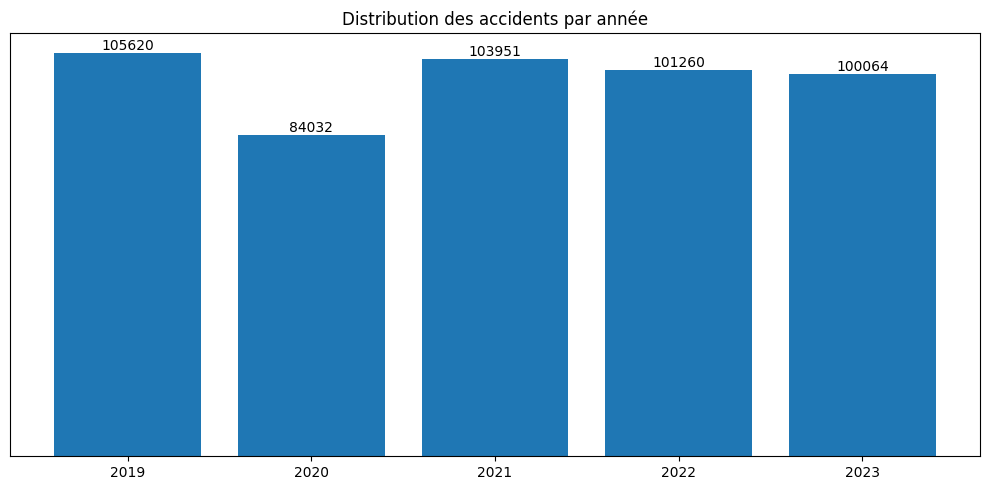

In [124]:
# Regroupement par année complète
distribution_par_annee_complete = df_final['an'].value_counts().sort_index()

# Création du graphique
plt.figure(figsize=(10, 5))
bars = plt.bar(distribution_par_annee_complete.index.astype(str), distribution_par_annee_complete.values)

# Ajout du nombre au-dessus de chaque barre
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,
             height + 5,  # hauteur du texte légèrement au-dessus
             f"{int(height)}",
             ha='center', va='bottom')
plt.gca().axes.get_yaxis().set_visible(False)
plt.ylabel("")
plt.title("Distribution des accidents par année")
plt.tight_layout()
plt.show()


### **Distribution des accidents par mois**

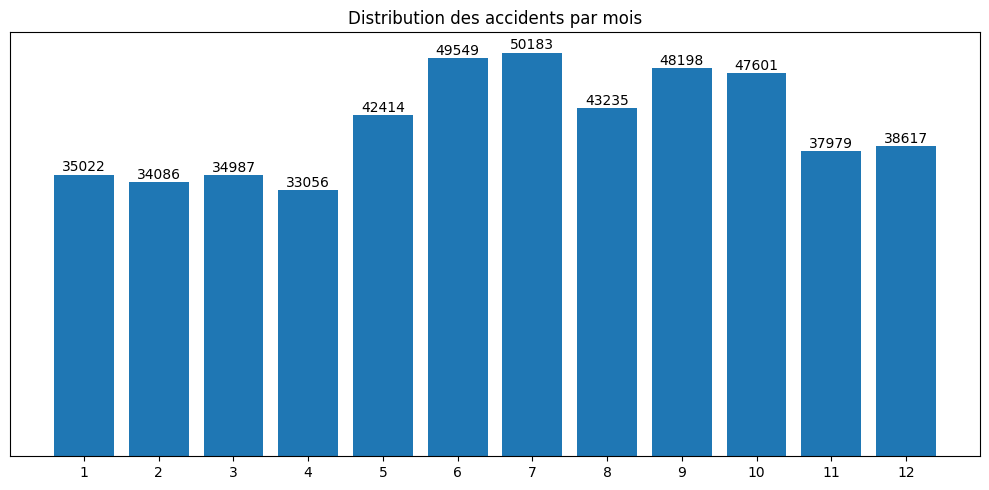

In [125]:
# Regroupement par année complète
distribution_par_annee_complete = df_final['mois'].value_counts().sort_index()

# Création du graphique
plt.figure(figsize=(10, 5))
bars = plt.bar(distribution_par_annee_complete.index.astype(str), distribution_par_annee_complete.values)

# Ajout du nombre au-dessus de chaque barre
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,
             height + 5,  # hauteur du texte légèrement au-dessus
             f"{int(height)}",
             ha='center', va='bottom')
plt.gca().axes.get_yaxis().set_visible(False)
plt.ylabel("")
plt.title("Distribution des accidents par mois")
plt.tight_layout()
plt.show()


### **Distribution de la gravité des accidents par jour semaine**

In [126]:
# Vérifier que les colonnes nécessaires existent
colonnes_requises = ['an', 'mois', 'jour']
for col in colonnes_requises:
    if col not in df_final.columns:
        raise ValueError(f"Colonne manquante dans le DataFrame : {col}")

# Renommer les colonnes pour correspondre aux formats attendus par pd.to_datetime
df_final = df_final.rename(columns={'an': 'year', 'mois': 'month', 'jour': 'day'})

# S'assurer que les colonnes sont bien de type int (évite les erreurs de parsing)
df_final[['year', 'month', 'day']] = df_final[['year', 'month', 'day']].astype(int)

# Créer la colonne de type date
df_final['date'] = pd.to_datetime(df_final[['year', 'month', 'day']], errors='coerce')

# Supprimer les lignes avec une date invalide (si erreurs='coerce' a généré des NaT)
df_final = df_final.dropna(subset=['date'])

# Extraire le jour de la semaine (en français)
try:
    df_final['jour_semaine'] = df_final['date'].dt.day_name(locale='fr_FR')
except:
    # Alternative manuelle si la locale française n'est pas installée
    jours = ['lundi', 'mardi', 'mercredi', 'jeudi', 'vendredi', 'samedi', 'dimanche']
    df_final['jour_semaine'] = df_final['date'].dt.dayofweek.apply(lambda x: jours[x])


In [127]:
df_final.head()

,Num_Acc,catu,sexe,ind,tue,bhosp,bleger,catv,obs,obsm,day,month,year,lum,dep,com,agg,int,atm,col,lat,long,catr,circ,prof,plan,surf,situ,vma,heure,gravite,date,jour_semaine
0,201900000001,2,2,0,0,0,1,1,1,2,30,11,2019,2,93,93053,1,1,1,2,48.896210,2.470120,1,1,1,2,1,1,70.0,1,0,2019-11-30,samedi
1,201900000001,1,2,0,0,0,1,1,1,2,30,11,2019,2,93,93053,1,1,1,2,48.896210,2.470120,1,1,1,2,1,1,70.0,1,0,2019-11-30,samedi
2,201900000001,1,1,1,0,0,0,4,3,3,30,11,2019,2,93,93053,1,1,1,2,48.896210,2.470120,1,1,1,2,1,1,70.0,1,0,2019-11-30,samedi
3,201900000002,1,2,0,0,0,1,1,3,3,30,11,2019,2,93,93066,1,1,1,4,48.930700,2.368800,1,1,3,2,1,1,70.0,2,0,2019-11-30,samedi
4,201900000003,1,1,1,0,0,0,1,1,2,28,11,2019,1,92,92036,1,1,1,4,48.935872,2.319174,1,1,1,3,1,1,90.0,15,0,2019-11-28,jeudi


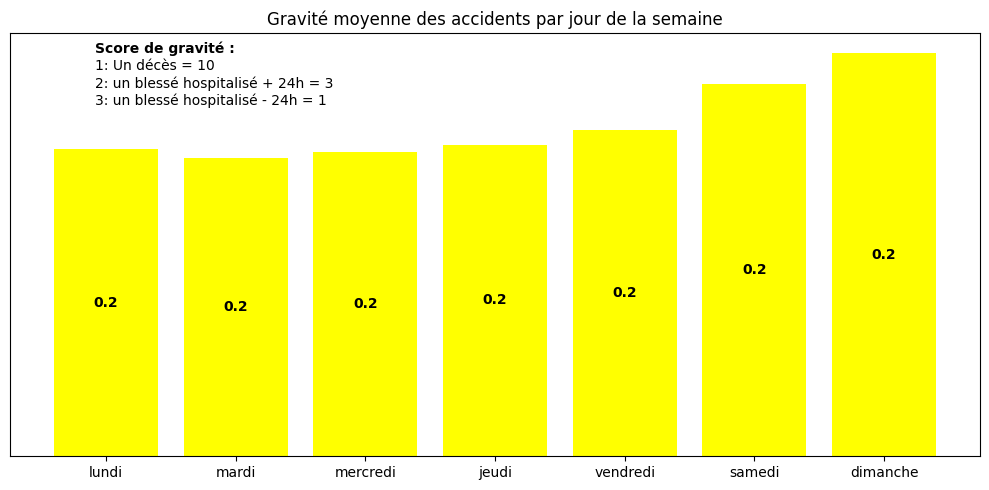

In [128]:
# Nettoyer les noms de colonnes
df.columns = df.columns.str.strip()

# Ordre logique des jours
jours_ordre = ['lundi', 'mardi', 'mercredi', 'jeudi', 'vendredi', 'samedi', 'dimanche']

# Calcul de la gravite moyenne par jour
gravite_par_jour = df_final.groupby("jour_semaine")["gravite"].mean().reindex(jours_ordre)

# Création du graphique
plt.figure(figsize=(10, 5))
bars = plt.bar(gravite_par_jour.index, gravite_par_jour.values, color='yellow')

# Ajouter les valeurs AU MILIEU des barres en gras
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height / 2,  # au milieu verticalement
        f"{height:.1f}",
        ha='center',
        va='center',
        fontweight='bold',
        color='black'  # blanc pour bon contraste si les barres sont foncées
    )

# Supprimer l'axe des ordonnées
plt.gca().axes.get_yaxis().set_visible(False)

# Titre
plt.title("Gravité moyenne des accidents par jour de la semaine")

# Légendes personnalisées (ajout en dehors du graphique)
legende_heure = {
    1: "Un décès = 10",
    2: "un blessé hospitalisé + 24h = 3",
    3: "un blessé hospitalisé - 24h = 1",
}
plt.figtext(0.1, 0.885, "Score de gravité :", fontsize=10, fontweight='bold')
for i, (k, v) in enumerate(legende_heure.items()):
    plt.figtext(0.1, 0.85 - i * 0.035, f"{k}: {v}", fontsize=10)

plt.tight_layout()
plt.show()


### **Distribution de la gravité des accidents par heure**

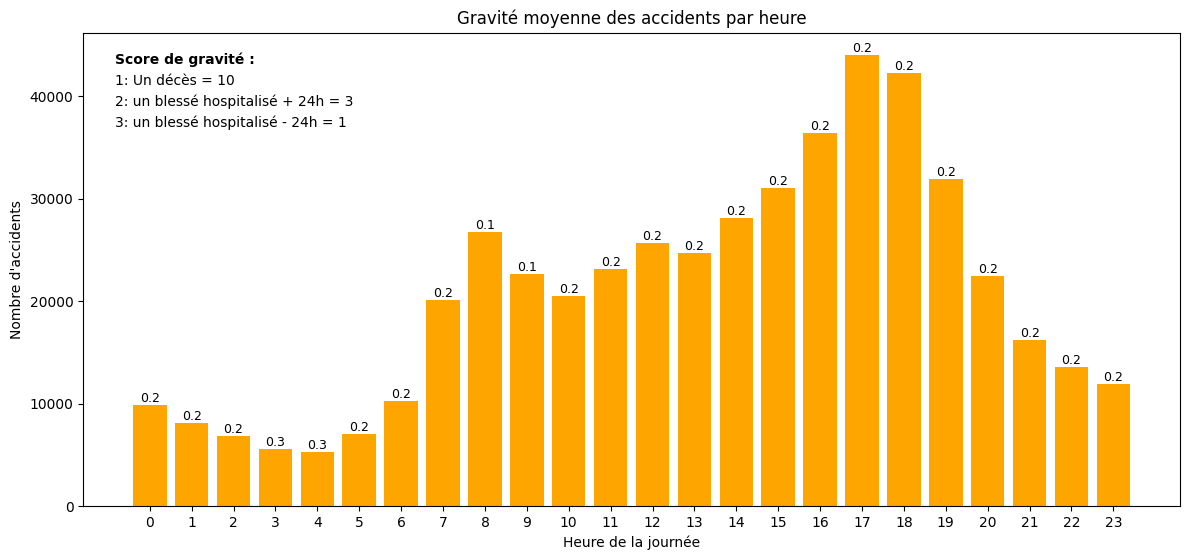

In [129]:
# Nettoyage des données
df_clean = df_final.dropna(subset=['heure', 'gravite'])
df_clean['heure'] = df_clean['heure'].astype(int)

# Index complet de 0 à 23 heures
heures_index = pd.Index(np.arange(24), name='heure')

# Calcul du nombre d'accidents par heure
nb_accidents_par_heure = df_clean.groupby('heure').size().reindex(heures_index, fill_value=0)

# Calcul de la gravité moyenne par heure
gravite_par_heure = df_clean.groupby('heure')['gravite'].mean().reindex(heures_index)

# Création de la figure
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(nb_accidents_par_heure.index, nb_accidents_par_heure.values, color='orange')

# Ajouter les valeurs de gravité moyenne au-dessus des barres
for heure, bar in zip(nb_accidents_par_heure.index, bars):
    gravite = gravite_par_heure.loc[heure]
    if not np.isnan(gravite):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{gravite:.1f}", ha='center', va='bottom', fontsize=9)

# Titre et axes
ax.set_title("Gravité moyenne des accidents par heure")
ax.set_xlabel("Heure de la journée")
ax.set_ylabel("Nombre d'accidents")
ax.set_xticks(np.arange(24))
ax.set_xticklabels([str(h) for h in range(24)])

# La légende personnalisée est définie plus haut
plt.figtext(0.1, 0.885, "Score de gravité :", fontsize=10, fontweight='bold')
for i, (k, v) in enumerate(legende_heure.items()):
    plt.figtext(0.1, 0.85 - i * 0.035, f"{k}: {v}", fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


## **VISUALISATION SPATIALE**

In [130]:
# Filtrer les lignes avec des coordonnées valides pour la France et la Corse
df_final = df_final[(df_final['lat'].between(41.0, 51.5)) & (df_final['long'].between(-5.0, 10.0))]

### **France entière**

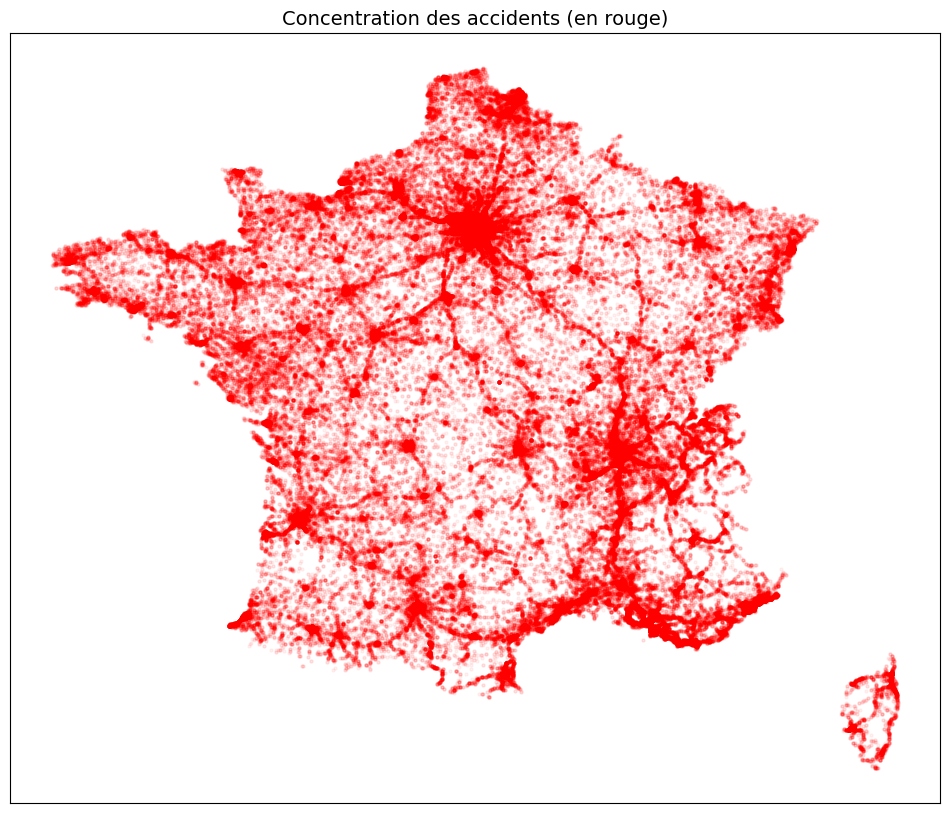

In [131]:
# Création de la figure
plt.figure(figsize=(12, 10))

# Nuage de points en rouge
plt.scatter(df_final['long'], df_final['lat'], color='red', s=5, alpha=0.05)

# Titres et axes
plt.title("Concentration des accidents (en rouge)", fontsize=14)
plt.xlabel("")
plt.ylabel("")
plt.grid(False)

plt.xticks([])  # Supprime les ticks en abscisse
plt.yticks([])  # Supprime les ticks en ordonnée

# Affichage du graphique
plt.show()


### **France par tranche de 2 heures**

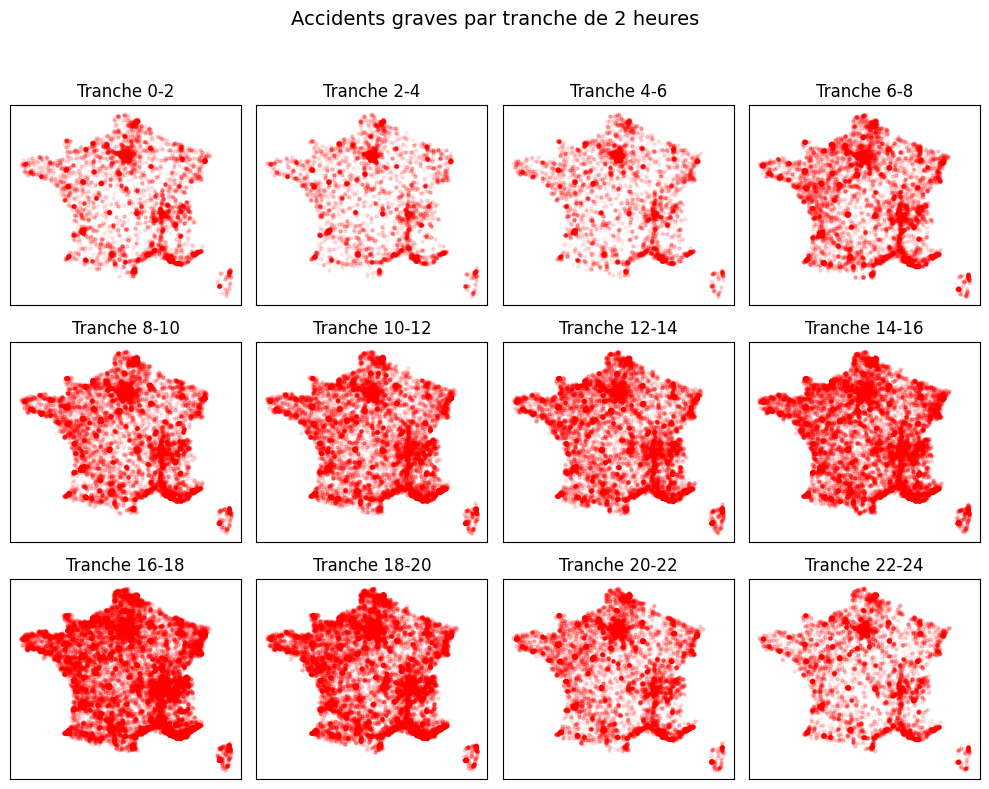

In [132]:
# Filtrer uniquement les accidents graves
df = df_final[df_final['gravite'] > 0]

# Créer des plages de 2 heures
bins = list(range(0, 25, 2))
labels = [f"{i}-{i+2}" for i in range(0, 24, 2)]
df_final['plage_horaire'] = pd.cut(df_final['heure'], bins=bins, labels=labels, right=False)

# Création d'une figure 3x4
fig, axes = plt.subplots(3, 4, figsize=(10, 8))
axes = axes.flatten()

# Tracer chaque plage horaire avec uniquement les accidents graves
for i, label in enumerate(labels):
    ax = axes[i]
    subset = df_final[df_final['plage_horaire'] == label]
    ax.scatter(subset['long'], subset['lat'], color='red', s=5, alpha=0.05)
    ax.set_title(f"Tranche {label}")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

# Titre général
plt.suptitle("Accidents graves par tranche de 2 heures", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [133]:
df_final.drop(columns=['plage_horaire'], inplace=True)

## **VISUALISATION PAR SPÉCIFICITÉS**

## **VISUALISATION PAR COMPARAISON**

### **COMPARAISON MENSUELLE DU NOMBE D'ACCIDENTS**

In [134]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 494920 entries, 0 to 494926
Data columns (total 33 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Num_Acc       494920 non-null  int64         
 1   catu          494920 non-null  int64         
 2   sexe          494920 non-null  int64         
 3   ind           494920 non-null  int64         
 4   tue           494920 non-null  int64         
 5   bhosp         494920 non-null  int64         
 6   bleger        494920 non-null  int64         
 7   catv          494920 non-null  int64         
 8   obs           494920 non-null  int64         
 9   obsm          494920 non-null  int64         
 10  day           494920 non-null  int64         
 11  month         494920 non-null  int64         
 12  year          494920 non-null  int64         
 13  lum           494920 non-null  int64         
 14  dep           494920 non-null  int64         
 15  com           494920 n

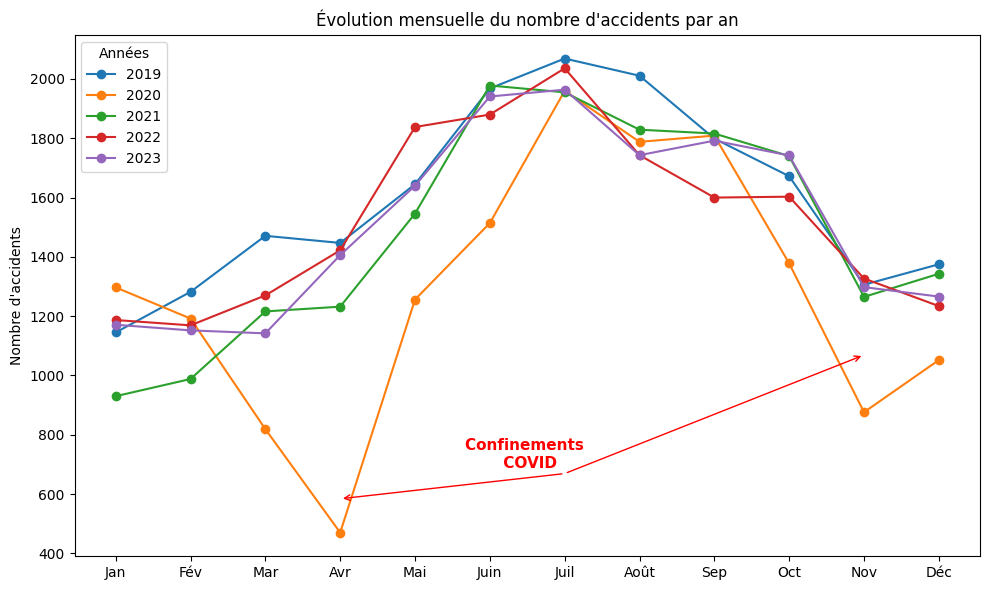

In [135]:
# Regrouper les données
accidents_par_an_mois = df.groupby(['year', 'month']).size().unstack(level=0).fillna(0)

plt.figure(figsize=(10, 6))

# Courbes
for annee in accidents_par_an_mois.columns:
    plt.plot(accidents_par_an_mois.index, accidents_par_an_mois[annee], marker='o', label=str(annee))

# Titre, axes, légendes
plt.title("Évolution mensuelle du nombre d'accidents par an")
plt.xlabel("")
plt.ylabel("Nombre d'accidents")
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin','Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc'])
plt.legend(title="Années", loc='upper left')
plt.grid(False)

# Coordonnées pour positionner le commentaire "COVID"
y_max = accidents_par_an_mois.max().max()
y_text = y_max - 1400  # Position verticale du texte
x_text = 7            # Mois de juillet

# Texte "COVID" SOUS les flèches
plt.text(x_text - 0.5, y_text + 20, "Confinements \n COVID", color="red", ha='center', fontsize=11, fontweight='bold')

# Deux flèches partant de juillet vers avril et novembre
plt.annotate('', xy=(4, y_max - 1485), xytext=(x_text, y_text), arrowprops=dict(arrowstyle="->", color="red"))
plt.annotate('', xy=(11, y_max - 1000), xytext=(x_text, y_text), arrowprops=dict(arrowstyle="->", color="red"))

plt.tight_layout()
plt.show()


### **COMPARAISON DE LA GRAVITÉ MENSUELLE DES ACCIDENTS**

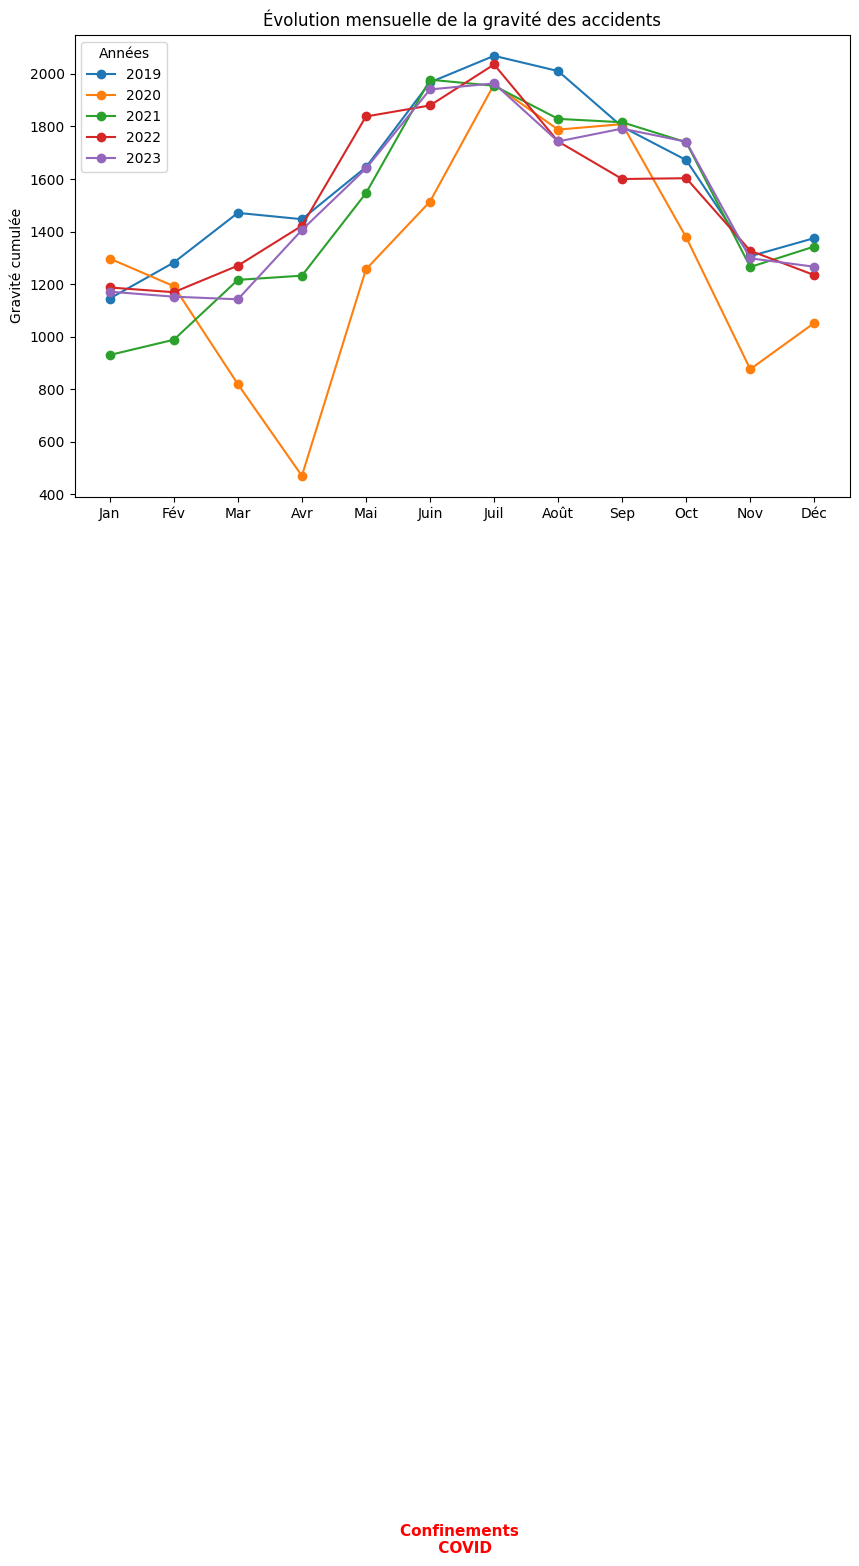

In [136]:
# Regrouper les données : somme de la gravité par an et par mois
gravite_par_an_mois = df_final.groupby(['year', 'month'])['gravite'].sum().unstack(level=0).fillna(0)

# Création de la figure
plt.figure(figsize=(10, 6))

# Tracer une courbe par année
for annee in gravite_par_an_mois.columns:
    plt.plot(gravite_par_an_mois.index, gravite_par_an_mois[annee], marker='o', label=str(annee))

# Titre et axes
plt.title("Évolution mensuelle de la gravité des accidents")
plt.xlabel("")
plt.ylabel("Gravité cumulée")
plt.xticks(ticks=range(1, 13), labels=[
    'Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin',
    'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc'
])
plt.legend(title="Années", loc='upper left')
plt.grid(False)

# Annotation COVID
y_max = gravite_par_an_mois.max().max()
y_text = y_max - 5800
x_text = 7  # Juillet

# Texte "Confinements COVID" sous les flèches
plt.text(x_text - 0.5, y_text + 100, "Confinements \n COVID", color="red", ha='center', fontsize=11, fontweight='bold')

# Flèches vers avril (4) et novembre (11)
plt.annotate('', xy=(4, y_max - 5715), xytext=(x_text, y_text), arrowprops=dict(arrowstyle="->", color="red"))
plt.annotate('', xy=(11, y_max - 3765), xytext=(x_text, y_text), arrowprops=dict(arrowstyle="->", color="red"))

# Affichage final
plt.tight_layout()
plt.show()


# **DATASET FINAL**

In [137]:
# On affiche les 10 premières lignes du dataframe
df_final.head(5)

,Num_Acc,catu,sexe,ind,tue,bhosp,bleger,catv,obs,obsm,day,month,year,lum,dep,com,agg,int,atm,col,lat,long,catr,circ,prof,plan,surf,situ,vma,heure,gravite,date,jour_semaine
0,201900000001,2,2,0,0,0,1,1,1,2,30,11,2019,2,93,93053,1,1,1,2,48.896210,2.470120,1,1,1,2,1,1,70.0,1,0,2019-11-30,samedi
1,201900000001,1,2,0,0,0,1,1,1,2,30,11,2019,2,93,93053,1,1,1,2,48.896210,2.470120,1,1,1,2,1,1,70.0,1,0,2019-11-30,samedi
2,201900000001,1,1,1,0,0,0,4,3,3,30,11,2019,2,93,93053,1,1,1,2,48.896210,2.470120,1,1,1,2,1,1,70.0,1,0,2019-11-30,samedi
3,201900000002,1,2,0,0,0,1,1,3,3,30,11,2019,2,93,93066,1,1,1,4,48.930700,2.368800,1,1,3,2,1,1,70.0,2,0,2019-11-30,samedi
4,201900000003,1,1,1,0,0,0,1,1,2,28,11,2019,1,92,92036,1,1,1,4,48.935872,2.319174,1,1,1,3,1,1,90.0,15,0,2019-11-28,jeudi


In [138]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 494920 entries, 0 to 494926
Data columns (total 33 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Num_Acc       494920 non-null  int64         
 1   catu          494920 non-null  int64         
 2   sexe          494920 non-null  int64         
 3   ind           494920 non-null  int64         
 4   tue           494920 non-null  int64         
 5   bhosp         494920 non-null  int64         
 6   bleger        494920 non-null  int64         
 7   catv          494920 non-null  int64         
 8   obs           494920 non-null  int64         
 9   obsm          494920 non-null  int64         
 10  day           494920 non-null  int64         
 11  month         494920 non-null  int64         
 12  year          494920 non-null  int64         
 13  lum           494920 non-null  int64         
 14  dep           494920 non-null  int64         
 15  com           494920 n

In [139]:
# Je retire les colonnes non nécessaires
df_complément = df_final[['Num_Acc', 'day', 'month', 'year', 'dep', 'com', 'lat', 'long', 'ind', 'tue', 'bhosp', 'bleger', 'date']].copy()
df_complément.to_csv('/content/drive/My Drive/Projet DS/Brouillon Eric/df_complément.csv', index=False)
df_complément.head()

,Num_Acc,day,month,year,dep,com,lat,long,ind,tue,bhosp,bleger,date
0,201900000001,30,11,2019,93,93053,48.896210,2.470120,0,0,0,1,2019-11-30
1,201900000001,30,11,2019,93,93053,48.896210,2.470120,0,0,0,1,2019-11-30
2,201900000001,30,11,2019,93,93053,48.896210,2.470120,1,0,0,0,2019-11-30
3,201900000002,30,11,2019,93,93066,48.930700,2.368800,0,0,0,1,2019-11-30
4,201900000003,28,11,2019,92,92036,48.935872,2.319174,1,0,0,0,2019-11-28


In [140]:
# Je garde les colonnes nécessaires et je nomme df_database mon data de travail
df_database = df_final.drop(columns=['day', 'month', 'year', 'dep', 'com', 'lat', 'long', 'ind', 'tue', 'bhosp', 'bleger', 'date'])
df_database.to_csv('/content/drive/My Drive/Projet DS/Brouillon Eric/df_database.csv', index=False)
df_database.head()

,Num_Acc,catu,sexe,catv,obs,obsm,lum,agg,int,atm,col,catr,circ,prof,plan,surf,situ,vma,heure,gravite,jour_semaine
0,201900000001,2,2,1,1,2,2,1,1,1,2,1,1,1,2,1,1,70.0,1,0,samedi
1,201900000001,1,2,1,1,2,2,1,1,1,2,1,1,1,2,1,1,70.0,1,0,samedi
2,201900000001,1,1,4,3,3,2,1,1,1,2,1,1,1,2,1,1,70.0,1,0,samedi
3,201900000002,1,2,1,3,3,2,1,1,1,4,1,1,3,2,1,1,70.0,2,0,samedi
4,201900000003,1,1,1,1,2,1,1,1,1,4,1,1,1,3,1,1,90.0,15,0,jeudi


In [141]:
df_database.head(5)

,Num_Acc,catu,sexe,catv,obs,obsm,lum,agg,int,atm,col,catr,circ,prof,plan,surf,situ,vma,heure,gravite,jour_semaine
0,201900000001,2,2,1,1,2,2,1,1,1,2,1,1,1,2,1,1,70.0,1,0,samedi
1,201900000001,1,2,1,1,2,2,1,1,1,2,1,1,1,2,1,1,70.0,1,0,samedi
2,201900000001,1,1,4,3,3,2,1,1,1,2,1,1,1,2,1,1,70.0,1,0,samedi
3,201900000002,1,2,1,3,3,2,1,1,1,4,1,1,3,2,1,1,70.0,2,0,samedi
4,201900000003,1,1,1,1,2,1,1,1,1,4,1,1,1,3,1,1,90.0,15,0,jeudi


In [142]:
df_database.info()

<class 'pandas.core.frame.DataFrame'>
Index: 494920 entries, 0 to 494926
Data columns (total 21 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Num_Acc       494920 non-null  int64  
 1   catu          494920 non-null  int64  
 2   sexe          494920 non-null  int64  
 3   catv          494920 non-null  int64  
 4   obs           494920 non-null  int64  
 5   obsm          494920 non-null  int64  
 6   lum           494920 non-null  int64  
 7   agg           494920 non-null  int64  
 8   int           494920 non-null  int64  
 9   atm           494920 non-null  int64  
 10  col           494920 non-null  int64  
 11  catr          494920 non-null  int64  
 12  circ          494920 non-null  int64  
 13  prof          494920 non-null  int64  
 14  plan          494920 non-null  int64  
 15  surf          494920 non-null  int64  
 16  situ          494920 non-null  int64  
 17  vma           484875 non-null  float64
 18  heure    

In [143]:
df_database.tail(5)

,Num_Acc,catu,sexe,catv,obs,obsm,lum,agg,int,atm,col,catr,circ,prof,plan,surf,situ,vma,heure,gravite,jour_semaine
494922,202300054816,1,2,1,1,2,1,1,1,1,1,3,2,2,1,1,1,80.0,12,1,mercredi
494923,202300054816,2,2,1,1,2,1,1,1,1,1,3,2,2,1,1,1,80.0,12,0,mercredi
494924,202300054822,2,2,1,1,2,1,2,1,3,3,4,2,1,1,1,3,30.0,16,0,vendredi
494925,202300054822,1,2,1,1,2,1,2,1,3,3,4,2,1,1,1,3,30.0,16,0,vendredi
494926,202300054822,1,2,3,3,2,1,2,1,3,3,4,2,1,1,1,3,30.0,16,1,vendredi


## **TEST DU CHI²**

In [144]:
from scipy.stats import chi2_contingency

In [145]:
# Liste des variables explicatives
variables = ['catu', 'sexe', 'catv', 'obs', 'obsm', 'lum', 'agg', 'int', 'atm', 'col', 'catr', 'circ', 'prof', 'plan', 'surf', 'situ', 'vma', 'heure', 'jour_semaine']

# Liste pour stocker les résultats
resultats_chi2 = []

for var in variables:
    try:
        table = pd.crosstab(df_final[var], df_database['gravite'])
        chi2, p, dof, expected = chi2_contingency(table)
        resultats_chi2.append([
            var,
            round(chi2, 2),
            round(p, 4),
            'Oui' if p < 0.05 else 'Non'
        ])
    except Exception as e:
        resultats_chi2.append([
            var,
            None,
            None,
            f'Erreur: {str(e)}'
        ])

# Création de l'en-tête et affichage
entetes = ["Variable", "Chi²", "p-value", "Dépendance à grave"]
print(tabulate(resultats_chi2, headers=entetes, tablefmt="fancy_grid"))


╒══════════════╤══════════╤═══════════╤══════════════════════╕
│ Variable     │     Chi² │   p-value │ Dépendance à grave   │
╞══════════════╪══════════╪═══════════╪══════════════════════╡
│ catu         │   107.65 │         0 │ Oui                  │
├──────────────┼──────────┼───────────┼──────────────────────┤
│ sexe         │  2690.04 │         0 │ Oui                  │
├──────────────┼──────────┼───────────┼──────────────────────┤
│ catv         │ 26866.7  │         0 │ Oui                  │
├──────────────┼──────────┼───────────┼──────────────────────┤
│ obs          │ 28771.4  │         0 │ Oui                  │
├──────────────┼──────────┼───────────┼──────────────────────┤
│ obsm         │ 25025.1  │         0 │ Oui                  │
├──────────────┼──────────┼───────────┼──────────────────────┤
│ lum          │   392.34 │         0 │ Oui                  │
├──────────────┼──────────┼───────────┼──────────────────────┤
│ agg          │ 15563.1  │         0 │ Oui            

## **MATRICE DE CORRÉLATION DE PEARSON**

In [146]:
# Dictionnaire de conversion
jour_mapping = {
    'lundi': 1,
    'mardi': 2,
    'mercredi': 3,
    'jeudi': 4,
    'vendredi': 5,
    'samedi': 6,
    'dimanche': 7
}

# Conversion
df_database['num_jour'] = df_database['jour_semaine'].map(jour_mapping)
df_database = df_database.drop(columns=['jour_semaine'])
df_database = df_database.rename(columns={'num_jour': 'jour_semaine'})


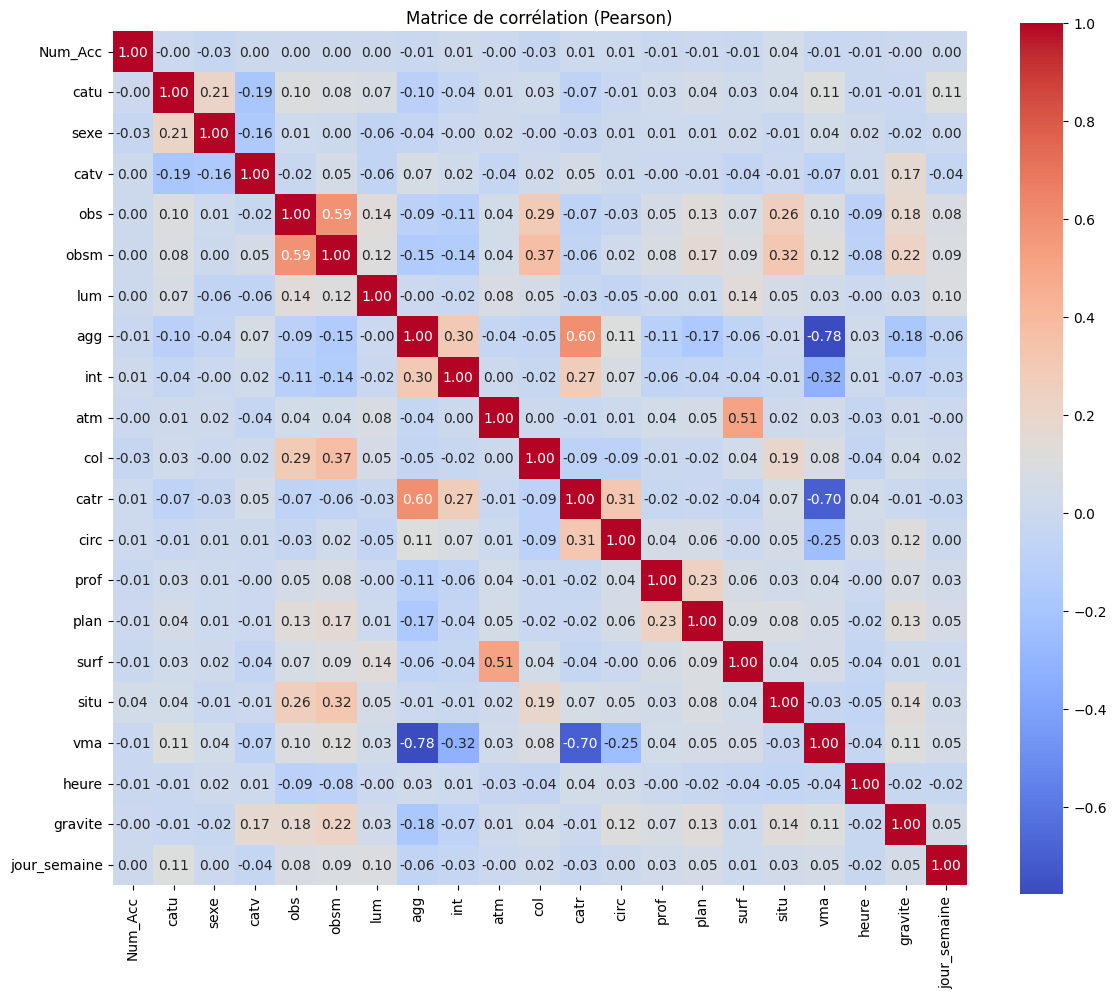

In [147]:
# Calcul de la matrice de corrélation de Pearson
corr_matrix = df_database.corr(method='pearson')

# Affichage de la matrice sous forme de heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar=True)
plt.title("Matrice de corrélation (Pearson)")
plt.tight_layout()
plt.show()


## **CALCUL DU V CRAMER**

In [148]:
# Fonction pour calculer le V de Cramér
def cramers_v(x, y):
    try:
        confusion_matrix = pd.crosstab(x, y)
        chi2, _, _, _ = chi2_contingency(confusion_matrix)
        n = confusion_matrix.sum().sum()
        k, r = confusion_matrix.shape
        return round(np.sqrt(chi2 / (n * (min(k - 1, r - 1)))), 4)
    except:
        return np.nan

# Liste des variables explicatives
variables = ['catu', 'sexe', 'catv', 'obs', 'obsm', 'lum', 'agg', 'int', 'atm', 'col', 'catr', 'circ', 'prof', 'plan', 'surf', 'situ', 'vma', 'heure', 'jour_semaine']

# Calcule le V de Cramér et ajoute interprétation
def interpretation(v):
    if pd.isna(v):
        return "Erreur"
    elif v >= 0.4:
        return "Très forte"
    elif v >= 0.2:
        return "Modérée"
    elif v >= 0.1:
        return "Faible"
    elif v > 0:
        return "Très faible"
    else:
        return "Aucune"

# Calcul du V de Cramér pour chaque variable
resultats = []
for var in variables:
    v = cramers_v(df_final[var], df_database['gravite'])
    resultats.append([var, v, interpretation(v)])

# DataFrame trié
df_resultats = pd.DataFrame(resultats, columns=["Variable", "V de Cramér", "Interprétation"])
df_resultats = df_resultats.sort_values(by="V de Cramér", ascending=False)

# Affichage propre
print(tabulate(df_resultats, headers='keys', tablefmt='fancy_grid', showindex=True))


╒════╤══════════════╤═══════════════╤══════════════════╕
│    │ Variable     │   V de Cramér │ Interprétation   │
╞════╪══════════════╪═══════════════╪══════════════════╡
│ 16 │ vma          │        0.2583 │ Modérée          │
├────┼──────────────┼───────────────┼──────────────────┤
│  3 │ obs          │        0.2411 │ Modérée          │
├────┼──────────────┼───────────────┼──────────────────┤
│  2 │ catv         │        0.233  │ Modérée          │
├────┼──────────────┼───────────────┼──────────────────┤
│  4 │ obsm         │        0.2249 │ Modérée          │
├────┼──────────────┼───────────────┼──────────────────┤
│ 15 │ situ         │        0.2135 │ Modérée          │
├────┼──────────────┼───────────────┼──────────────────┤
│ 10 │ catr         │        0.2056 │ Modérée          │
├────┼──────────────┼───────────────┼──────────────────┤
│  9 │ col          │        0.1816 │ Faible           │
├────┼──────────────┼───────────────┼──────────────────┤
│  6 │ agg          │        0.

## **SÉPARATION DU JEUX DE DONNÉES : TRAIN / TEST**

In [149]:
from sklearn.model_selection import train_test_split


In [150]:
df_database.head(5)

,Num_Acc,catu,sexe,catv,obs,obsm,lum,agg,int,atm,col,catr,circ,prof,plan,surf,situ,vma,heure,gravite,jour_semaine
0,201900000001,2,2,1,1,2,2,1,1,1,2,1,1,1,2,1,1,70.0,1,0,6
1,201900000001,1,2,1,1,2,2,1,1,1,2,1,1,1,2,1,1,70.0,1,0,6
2,201900000001,1,1,4,3,3,2,1,1,1,2,1,1,1,2,1,1,70.0,1,0,6
3,201900000002,1,2,1,3,3,2,1,1,1,4,1,1,3,2,1,1,70.0,2,0,6
4,201900000003,1,1,1,1,2,1,1,1,1,4,1,1,1,3,1,1,90.0,15,0,4


In [151]:
df_sample = df_database.sample(n=30000, random_state=42)
df_sample.to_csv('/content/drive/My Drive/Projet DS/Brouillon Eric/df_sample1.csv', index=False)

In [152]:
# Séparer les variables explicatives (X) et la cible (y)
X = df_database.drop(columns=['gravite'])
y = df_database['gravite']

# Création des jeux d'entraînement et de test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify pour garder les proportions
)

X_train = X_train.dropna()
y_train = y_train[X_train.index]  # Garde les mêmes lignes pour y

X_test = X_test.dropna()
y_test = y_test[X_test.index]

# Affichage des tailles
print("Taille du train :", X_train.shape)
print("Taille du test  :", X_test.shape)


Taille du train : (387890, 20)
Taille du test  : (96985, 20)


In [153]:
print("Répartition train :", y_train.value_counts(normalize=True))
print("Répartition test  :", y_test.value_counts(normalize=True))


Répartition train : gravite
0    0.822091
1    0.177909
Name: proportion, dtype: float64
Répartition test  : gravite
0    0.821725
1    0.178275
Name: proportion, dtype: float64


In [154]:
print(X_train.isnull().sum())

Num_Acc         0
catu            0
sexe            0
catv            0
obs             0
obsm            0
lum             0
agg             0
int             0
atm             0
col             0
catr            0
circ            0
prof            0
plan            0
surf            0
situ            0
vma             0
heure           0
jour_semaine    0
dtype: int64


In [155]:
colonnes_avec_nan = df_database.columns[df_database.isna().any()]
print("Colonnes avec NaN :", colonnes_avec_nan.tolist())

Colonnes avec NaN : ['vma']


In [156]:
print(y_train.value_counts())

gravite
0    318881
1     69009
Name: count, dtype: int64


## **MODÉLISATION : RÉGRESSION LOGISTIQUE**

In [157]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Entraînement du modèle avec pondération automatique des classes
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

# Prédictions
y_pred = model.predict(X_test)

# Évaluation
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[79695     0]
 [17290     0]]
              precision    recall  f1-score   support

           0       0.82      1.00      0.90     79695
           1       0.00      0.00      0.00     17290

    accuracy                           0.82     96985
   macro avg       0.41      0.50      0.45     96985
weighted avg       0.68      0.82      0.74     96985



### **Validation croisée : RÉGRESSION LOGISTIQUE**

## **MODÉLISATION : RANDOM FOREST**

In [158]:
from sklearn.ensemble import RandomForestClassifier

# Création du modèle avec pondération automatique
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Prédictions
y_pred_rf = rf_model.predict(X_test)

# Évaluation
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


[[74065  5630]
 [10591  6699]]
              precision    recall  f1-score   support

           0       0.87      0.93      0.90     79695
           1       0.54      0.39      0.45     17290

    accuracy                           0.83     96985
   macro avg       0.71      0.66      0.68     96985
weighted avg       0.82      0.83      0.82     96985



In [159]:
# Réentraîner le modèle sur toutes les données
rf_model.fit(X, y)

# Calculer l’importance des variables
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

# Affichage
print(importances.head(10))   # les plus importantes
print(importances.tail(10))   # les moins importantes

Num_Acc         0.146816
heure           0.139532
catv            0.119549
jour_semaine    0.087307
vma             0.063751
col             0.050479
catr            0.046145
obsm            0.043182
circ            0.038392
obs             0.034511
dtype: float64
agg     0.031498
situ    0.027859
plan    0.026250
int     0.026030
sexe    0.024824
prof    0.022820
catu    0.019212
atm     0.018846
lum     0.016539
surf    0.016456
dtype: float64


### **Validation croisée : RANDOM FOREST**

## **MODÉLISATION : XGBoost**

In [160]:
from xgboost import XGBClassifier

In [161]:
# Préparation des données
X = df_database.drop(columns=['gravite'])  # ou 'gravite' selon ta colonne cible
y = df_database['gravite']  # variable binaire 0 / 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Calcul du ratio pour scale_pos_weight
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

# Modèle XGBoost
xgb = XGBClassifier(scale_pos_weight=ratio, use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

# Évaluation
y_pred = xgb.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[59631 21552]
 [ 3740 14061]]
              precision    recall  f1-score   support

           0       0.94      0.73      0.83     81183
           1       0.39      0.79      0.53     17801

    accuracy                           0.74     98984
   macro avg       0.67      0.76      0.68     98984
weighted avg       0.84      0.74      0.77     98984



## **MODÉLISATION : LightGBM avec gestion du déséquilibre**

In [162]:
import lightgbm as lgb

# Séparation des variables
X = df_database.drop(columns=['gravite'])
y = df_database['gravite']

# Split avec stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Option 1 : calculer le ratio pour scale_pos_weight
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

# Initialisation du modèle LightGBM
model = lgb.LGBMClassifier(
    scale_pos_weight=ratio,         # ou is_unbalance=True
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

# Entraînement
model.fit(X_train, y_train)

# Prédictions
y_pred = model.predict(X_test)

# Évaluation
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[LightGBM] [Info] Number of positive: 71204, number of negative: 324732
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.077347 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 371
[LightGBM] [Info] Number of data points in the train set: 395936, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.179837 -> initscore=-1.517451
[LightGBM] [Info] Start training from score -1.517451
[[58584 22599]
 [ 3536 14265]]
              precision    recall  f1-score   support

           0       0.94      0.72      0.82     81183
           1       0.39      0.80      0.52     17801

    accuracy                           0.74     98984
   macro avg       0.67      0.76      0.67     98984
weighted avg       0.84      0.74      0.76     98984



## **AMÉLIORATIONS DES MODÈLES**

In [163]:
from imblearn.over_sampling import SMOTE


### **Récupérer les probabilités**

### **Ajuster le seuil**

In [164]:
df_database.head()

,Num_Acc,catu,sexe,catv,obs,obsm,lum,agg,int,atm,col,catr,circ,prof,plan,surf,situ,vma,heure,gravite,jour_semaine
0,201900000001,2,2,1,1,2,2,1,1,1,2,1,1,1,2,1,1,70.0,1,0,6
1,201900000001,1,2,1,1,2,2,1,1,1,2,1,1,1,2,1,1,70.0,1,0,6
2,201900000001,1,1,4,3,3,2,1,1,1,2,1,1,1,2,1,1,70.0,1,0,6
3,201900000002,1,2,1,3,3,2,1,1,1,4,1,1,3,2,1,1,70.0,2,0,6
4,201900000003,1,1,1,1,2,1,1,1,1,4,1,1,1,3,1,1,90.0,15,0,4


In [165]:
from sklearn.metrics import classification_report, balanced_accuracy_score

# 2. Préparer les données
X = df_database.drop(columns=["gravite"])
y = df_database["gravite"]

# 3. Split stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 4. Supprimer les NaN du jeu d'entraînement
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

# 5. Appliquer SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# 6. Entraîner un modèle Random Forest
clf = RandomForestClassifier(random_state=42)
clf.fit(X_resampled, y_resampled)

# 7. Nettoyer le test set aussi (juste X_test)
X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]

# 8. Prédictions
y_pred = clf.predict(X_test)

# 9. Évaluation
print(classification_report(y_test, y_pred))
print("Balanced Accuracy :", balanced_accuracy_score(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.88      0.90      0.89     79695
           1       0.49      0.45      0.47     17290

    accuracy                           0.82     96985
   macro avg       0.69      0.67      0.68     96985
weighted avg       0.81      0.82      0.82     96985

Balanced Accuracy : 0.673987123987124


In [166]:
from imblearn.over_sampling import SMOTE

# Vérifier la compatibilité
X_train_check = X_train.dropna()
y_train_check = y_train.loc[X_train_check.index]

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_check, y_train_check)

print("SMOTE a fonctionné.")


SMOTE a fonctionné.


In [167]:
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# 1. Nettoyage des données AVANT le split
X = df_database.drop(columns=["gravite"])
X = X.select_dtypes(include=["number"]).dropna() # Conserve uniquement les colonnes numériques
y = df_database.loc[X.index, "gravite"].astype(int)

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3. Pipeline SMOTE + RandomForest
pipeline = Pipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

# 4. Grille de recherche
param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [10, 20],
    'rf__min_samples_split': [2, 5]
}

# 5. GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, scoring='balanced_accuracy', cv=3, verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 6. Évaluation
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Best parameters:", grid_search.best_params_)
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters: {'rf__max_depth': 20, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}
Balanced Accuracy: 0.6842215340005083
              precision    recall  f1-score   support

           0       0.89      0.90      0.89     79715
           1       0.51      0.47      0.49     17260

    accuracy                           0.82     96975
   macro avg       0.70      0.68      0.69     96975
weighted avg       0.82      0.82      0.82     96975

